Style setup complete.
BigBench: 42 rows loaded
                             count   mean    max
base_model_name adapter                         
gemma-3-12b     lora            11  0.618  0.633
                uiortholora     15  0.626  0.637
                vera             8  0.622  0.635
llama-3b        uiortholora      8  0.457  0.469

MMLU: 51 rows loaded
             count    mean     max
adapter                           
lora            23  0.5656  0.7112
uiortholora     17  0.7007  0.7143
vera            11  0.6849  0.7154

HotPotQA shift data: 32 rows loaded
             accuracy  negative_shift_score
adapter                                    
lora            0.896              1493.367
uiortholora     0.000               524.622
vera            0.380               942.373

Merged dataset: 32 rows
With BigBench: 28
With MMLU: 31
  adapter    lr  accuracy  negative_shift_score  bigbench_acc  mmlu_accuracy
0    lora  1e-4  0.994094                1626.5           NaN          

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/fig1_accuracy_vs_negshift.png'

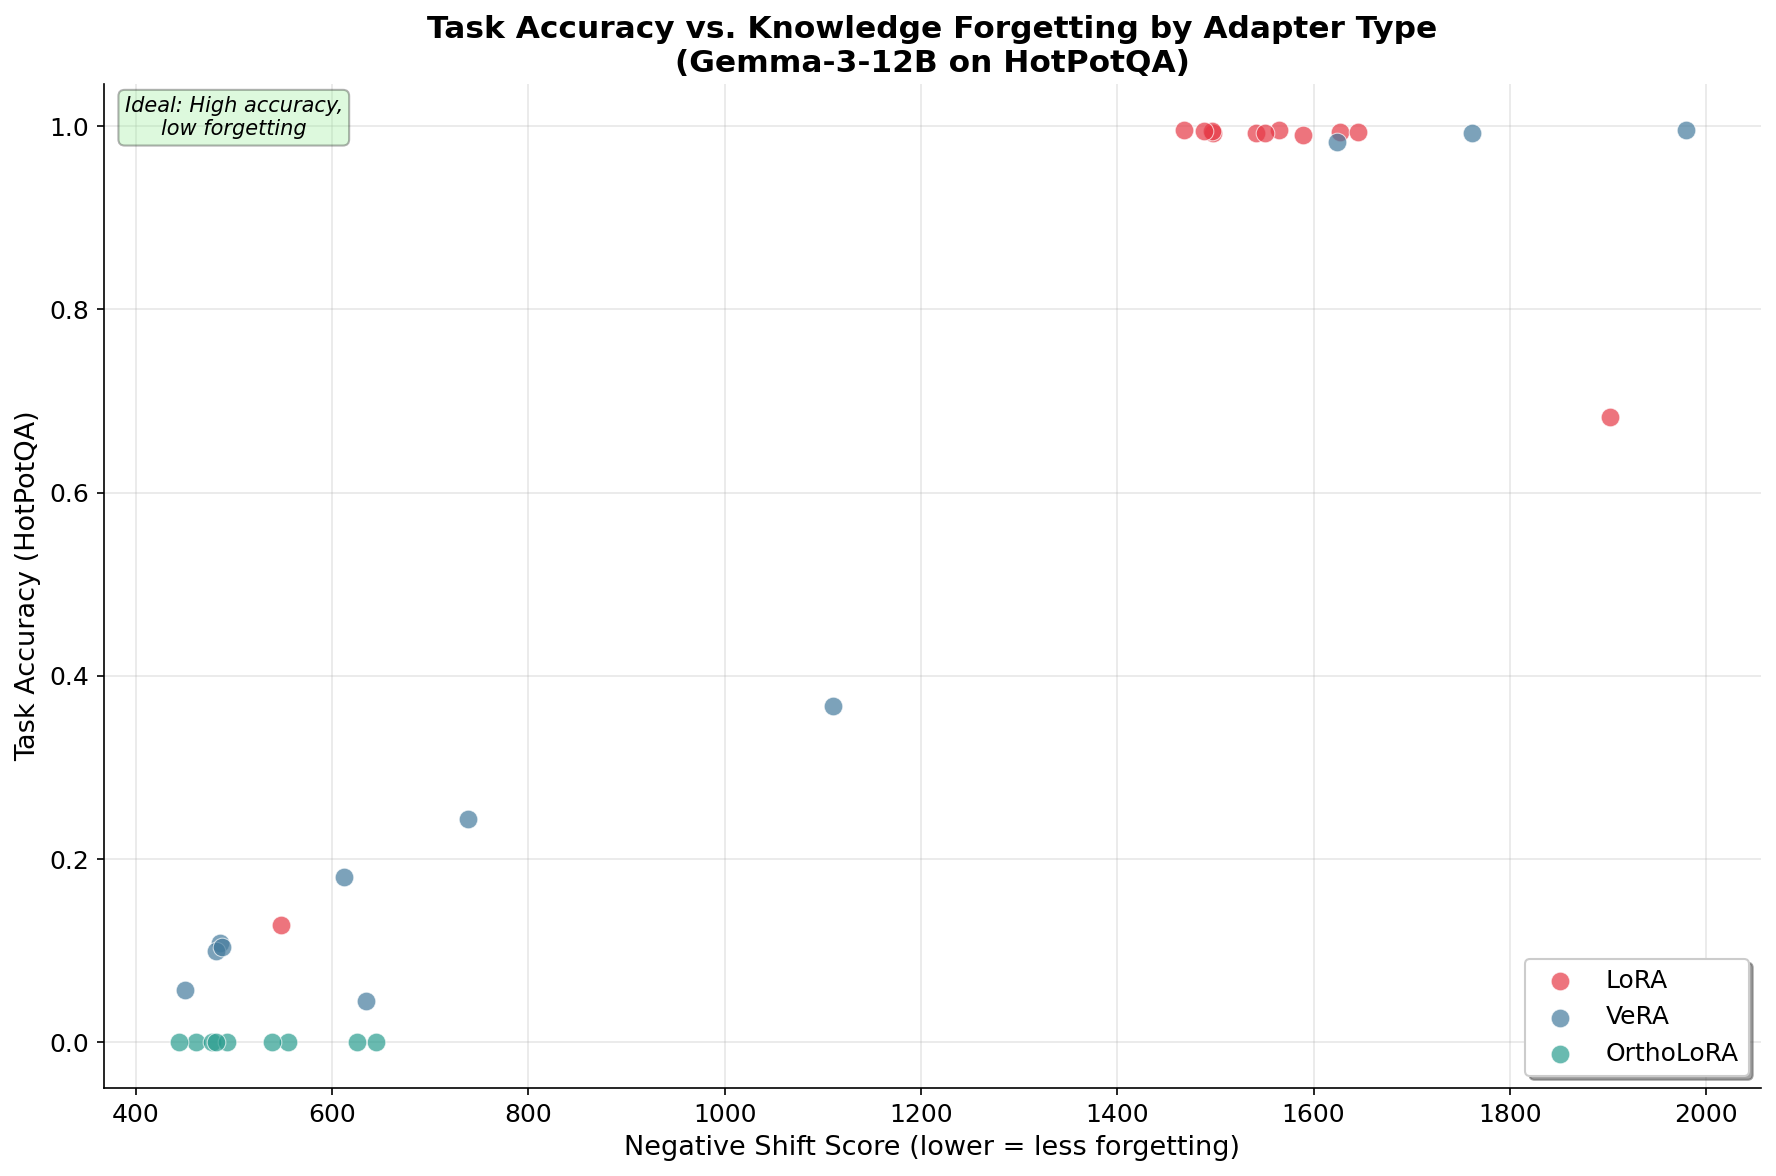

In [1]:
#!/usr/bin/env python3
"""
OrthoLoRA Adapter Analysis
Comprehensive analysis comparing LoRA, VeRA, and UIorthoLoRA adapters
across BigBench, MMLU, and HotPotQA task-specific evaluations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from io import StringIO
import warnings
import re
warnings.filterwarnings('ignore')

# ============================================================
# CELL 0: Style Setup
# ============================================================
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ADAPTER_COLORS = {
    'lora': '#E63946',
    'vera': '#457B9D',
    'uiortholora': '#2A9D8F',
}
ADAPTER_LABELS = {
    'lora': 'LoRA',
    'vera': 'VeRA',
    'uiortholora': 'OrthoLoRA',
}
SIZE_MARKERS = {
    'small': 'o',
    'large': 's',
}

print("Style setup complete.")

# ============================================================
# CELL 1: Load BigBench data
# ============================================================
bigbench_csv = """model_path,base_model,peft_method,rank,learning_rate,trainable_modules,mean_accuracy,acc_analogical_similarity,acc_analytic_entailment,acc_causal_judgment,acc_cause_and_effect,acc_common_morpheme,acc_conceptual_combinations,acc_logical_deduction,acc_logical_sequence,acc_odd_one_out
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec0_lr1e-4,,,,1e-4,trAll,0.454215364387307,0.24458204334365324,0.42857142857142855,0.45263157894736844,0.7777777777777778,0.44,0.6601941747572816,0.2693333333333333,0.38461538461538464,0.43023255813953487
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec128_lr1e-4,,,,1e-4,trAll,0.4515213417353557,0.24148606811145512,0.42857142857142855,0.49473684210526314,0.7581699346405228,0.46,0.6407766990291263,0.274,0.358974358974359,0.4069767441860465
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec256_lr1e-4,,,,1e-4,trAll,0.4570444688323902,0.23529411764705882,0.42857142857142855,0.4631578947368421,0.7777777777777778,0.46,0.6407766990291263,0.2673333333333333,0.41025641025641024,0.43023255813953487
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec512_lr1e-4,,,,1e-4,trAll,0.45439435519569243,0.23839009287925697,0.42857142857142855,0.46842105263157896,0.7908496732026143,0.46,0.6407766990291263,0.2733333333333333,0.358974358974359,0.43023255813953487
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec64_lr1e-4,,,,1e-4,trAll,0.44549028789831635,0.23529411764705882,0.42857142857142855,0.46842105263157896,0.7647058823529411,0.46,0.6407766990291263,0.2713333333333333,0.3333333333333333,0.4069767441860465
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec0_lr5e-4,,,,5e-4,trAll,0.45920599111435517,0.21981424148606812,0.42857142857142855,0.5473684210526316,0.7712418300653595,0.44,0.6116504854368932,0.2713333333333333,0.4358974358974359,0.4069767441860465
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec128_lr5e-4,,,,5e-4,trAll,0.4680212217705034,0.2043343653250774,0.42857142857142855,0.5368421052631579,0.7712418300653595,0.48,0.6407766990291263,0.27266666666666667,0.4358974358974359,0.4418604651162791
models/llama-3b/hotpotqa/uiortholora_trAll_sv1024_svec64_lr5e-4,,,,5e-4,trAll,0.46943634983509,0.20743034055727555,0.42857142857142855,0.531578947368421,0.7712418300653595,0.48,0.6213592233009708,0.2673333333333333,0.48717948717948717,0.43023255813953487
models/google_gemma-3-12b-it_lora_trAll_lora_r1_lr5e-5,google/gemma-3-12b-it_lora_trAll_lora_r1_lr5e-5,lora,1,5e-5,trAll,0.6177428227071807,0.26625386996904027,0.42857142857142855,0.6368421052631579,0.8104575163398693,0.58,0.8058252427184466,0.36,0.8461538461538461,0.8255813953488372
models/google_gemma-3-12b-it_lora_trAll_lora_r1_lr7e-5,google/gemma-3-12b-it_lora_trAll_lora_r1_lr7e-5,lora,1,7e-5,trAll,0.6222172051559183,0.3591331269349845,0.42857142857142855,0.6052631578947368,0.803921568627451,0.64,0.7184466019417476,0.338,0.8461538461538461,0.8604651162790697
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4,google/gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4,lora,3,1e-4,trAll,0.6117873257025798,0.43034055727554177,0.42857142857142855,0.6473684210526316,0.8169934640522876,0.48,0.7864077669902912,0.36333333333333334,0.8205128205128205,0.7325581395348837
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-5,google/gemma-3-12b-it_lora_trAll_lora_r3_lr1e-5,lora,3,1e-5,trAll,0.6056148327753288,0.15789473684210525,0.42857142857142855,0.631578947368421,0.8562091503267973,0.56,0.7766990291262136,0.32133333333333336,0.8461538461538461,0.872093023255814
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6,google/gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6,lora,3,1e-6,trAll,0.6156766220040255,0.23219814241486067,0.42857142857142855,0.6263157894736842,0.8496732026143791,0.54,0.8446601941747572,0.31066666666666665,0.8717948717948718,0.8372093023255814
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr5e-5,google/gemma-3-12b-it_lora_trAll_lora_r3_lr5e-5,lora,3,5e-5,trAll,0.6213277894980297,0.3281733746130031,0.42857142857142855,0.5789473684210527,0.8431372549019608,0.56,0.7961165048543689,0.348,0.8717948717948718,0.8372093023255814
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-5,google/gemma-3-12b-it_lora_trAll_lora_r3_lr7e-5,lora,3,7e-5,trAll,0.6153735066209659,0.29721362229102166,0.42857142857142855,0.6210526315789474,0.8235294117647058,0.54,0.7669902912621359,0.352,0.8717948717948718,0.8372093023255814
models/google_gemma-3-12b-it_lora_trAll_lora_r16_lr5e-5,google/gemma-3-12b-it_lora_trAll_lora_r16_lr5e-5,lora,16,5e-5,trAll,0.6147719524590403,0.3560371517027864,0.42857142857142855,0.6157894736842106,0.8235294117647058,0.52,0.7669902912621359,0.33866666666666667,0.8461538461538461,0.8372093023255814
models/google_gemma-3-12b-it_lora_trAll_lora_r16_lr7e-5,google/gemma-3-12b-it_lora_trAll_lora_r16_lr7e-5,lora,16,7e-5,trAll,0.6330985166323537,0.43034055727554177,0.42857142857142855,0.6105263157894737,0.8300653594771242,0.54,0.7766990291262136,0.3586666666666667,0.8974358974358975,0.8255813953488372
models/google_gemma-3-12b-it_lora_trAll_lora_r8_lr5e-5,google/gemma-3-12b-it_lora_trAll_lora_r8_lr5e-5,lora,8,5e-5,trAll,0.6114986772601285,0.28173374613003094,0.42857142857142855,0.5894736842105263,0.7843137254901961,0.6,0.7766990291262136,0.35933333333333334,0.8461538461538461,0.8372093023255814
models/google_gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5,google/gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5,lora,8,7e-5,trAll,0.6237256690334401,0.37770897832817335,0.42857142857142855,0.6105263157894737,0.8235294117647058,0.56,0.7864077669902912,0.3526666666666667,0.8717948717948718,0.8023255813953488
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-5,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-5,uiortholora,1024,1e-5,trAll,0.6363053012822836,0.34055727554179566,0.42857142857142855,0.6210526315789474,0.8888888888888888,0.54,0.8446601941747572,0.34,0.8974358974358975,0.8255813953488372
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-6,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-6,uiortholora,1024,1e-6,trAll,0.6359798798856547,0.33436532507739936,0.42857142857142855,0.6263157894736842,0.8888888888888888,0.54,0.8446601941747572,0.338,0.8974358974358975,0.8255813953488372
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-5,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-5,uiortholora,1024,5e-5,trAll,0.6273085770333575,0.2755417956656347,0.42857142857142855,0.631578947368421,0.8823529411764706,0.56,0.8543689320388349,0.33,0.8461538461538461,0.8372093023255814
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-6,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-6,uiortholora,1024,5e-6,trAll,0.6368345983812401,0.33746130030959753,0.42857142857142855,0.631578947368421,0.8888888888888888,0.54,0.8446601941747572,0.3373333333333333,0.8974358974358975,0.8255813953488372
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-5,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-5,uiortholora,1024,7e-5,trAll,0.6232020286041915,0.2724458204334365,0.42857142857142855,0.6210526315789474,0.8823529411764706,0.56,0.8446601941747572,0.328,0.8461538461538461,0.8255813953488372
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-4,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-4,uiortholora,1024,1e-4,trAll,0.6221395214969129,0.24148606811145512,0.42857142857142855,0.6263157894736842,0.8758169934640523,0.56,0.8543689320388349,0.3293333333333333,0.8461538461538461,0.8372093023255814
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-4,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-4,uiortholora,1024,5e-4,trAll,0.6227428377478038,0.2786377708978328,0.42857142857142855,0.6263157894736842,0.8758169934640523,0.56,0.8446601941747572,0.32133333333333336,0.8205128205128205,0.8488372093023255
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-4,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-4,uiortholora,1024,7e-4,trAll,0.6218853209156308,0.25077399380804954,0.42857142857142855,0.6105263157894737,0.8758169934640523,0.56,0.8446601941747572,0.32,0.8461538461538461,0.8604651162790697
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-3,google/gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-3,uiortholora,1024,1e-3,trAll,0.6116133589907536,0.21671826625386997,0.42857142857142855,0.6263157894736842,0.8758169934640523,0.54,0.8058252427184466,0.31866666666666665,0.8205128205128205,0.872093023255814
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-5,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-5,vera,1024,1e-5,trAll,0.6354136604154106,0.33126934984520123,0.42857142857142855,0.6263157894736842,0.8888888888888888,0.54,0.8446601941747572,0.336,0.8974358974358975,0.8255813953488372
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-6,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-6,vera,1024,1e-6,trAll,0.6331122423823103,0.33436532507739936,0.42857142857142855,0.631578947368421,0.8758169934640523,0.52,0.8446601941747572,0.34,0.8974358974358975,0.8255813953488372
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-5,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-5,vera,1024,5e-5,trAll,0.6230718924828874,0.22291021671826625,0.42857142857142855,0.631578947368421,0.869281045751634,0.56,0.8446601941747572,0.316,0.8974358974358975,0.8372093023255814
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-5,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-5,vera,1024,7e-5,trAll,0.6225205795600574,0.24148606811145512,0.42857142857142855,0.6263157894736842,0.8496732026143791,0.56,0.8446601941747572,0.31733333333333336,0.8974358974358975,0.8372093023255814
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4,vera,1024,1e-4,trAll,0.6235014570981503,0.2476780185758514,0.42857142857142855,0.6210526315789474,0.869281045751634,0.56,0.8349514563106796,0.31533333333333335,0.8974358974358975,0.8372093023255814
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-4,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-4,vera,1024,5e-4,trAll,0.6157124654799531,0.2260061919504644,0.42857142857142855,0.631578947368421,0.8562091503267973,0.54,0.8058252427184466,0.30933333333333335,0.8717948717948718,0.872093023255814
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-4,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-4,vera,1024,7e-4,trAll,0.6167960443668775,0.22910216718266255,0.42857142857142855,0.6210526315789474,0.8823529411764706,0.54,0.8058252427184466,0.312,0.8717948717948718,0.8604651162790697
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-3,google/gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-3,vera,1024,1e-3,trAll,0.6068694022425487,0.23219814241486067,0.42857142857142855,0.6052631578947368,0.8431372549019608,0.54,0.7864077669902912,0.308,0.8461538461538461,0.872093023255814
models/google_gemma-3-12b-it_uiortholora_trAll_s1024_v64_lr9e-3,google/gemma-3-12b-it_uiortholora_trAll_s1024_v64_lr9e-3,uiortholora,1024,9e-3,trAll,0.6331646037246013,0.47368421052631576,0.42857142857142855,0.6157894736842106,0.7843137254901961,0.62,0.8349514563106796,0.372,0.7435897435897436,0.8255813953488372
models/google_gemma-3-12b-it_uiortholora_trAll_s1024_v32_lr7e-3,google/gemma-3-12b-it_uiortholora_trAll_s1024_v32_lr7e-3,uiortholora,1024,7e-3,trAll,0.6293189808163624,0.39009287925696595,0.42857142857142855,0.5842105263157895,0.7908496732026143,0.64,0.7961165048543689,0.3506666666666667,0.8461538461538461,0.8372093023255814
models/google_gemma-3-12b-it_uiortholora_trAll_s256_v64_lr7e-3,google/gemma-3-12b-it_uiortholora_trAll_s256_v64_lr7e-3,uiortholora,256,7e-3,trAll,0.625032387690304,0.38699690402476783,0.42857142857142855,0.6052631578947368,0.8169934640522876,0.58,0.7961165048543689,0.342,0.8205128205128205,0.8488372093023255
models/google_gemma-3-12b-it_uiortholora_trAll_s1024_v3_lr8e-3,google/gemma-3-12b-it_uiortholora_trAll_s1024_v3_lr8e-3,uiortholora,1024,8e-3,trAll,0.6215659105000404,0.3065015479876161,0.42857142857142855,0.6157894736842106,0.7973856209150327,0.66,0.7766990291262136,0.3606666666666667,0.8461538461538461,0.8023255813953488
models/google_gemma-3-12b-it_uiortholora_trAll_s256_v64_lr6e-3,google/gemma-3-12b-it_uiortholora_trAll_s256_v64_lr6e-3,uiortholora,256,6e-3,trAll,0.6184480725533571,0.3931888544891641,0.42857142857142855,0.5947368421052631,0.8104575163398693,0.54,0.7864077669902912,0.35733333333333334,0.7948717948717948,0.8604651162790697
models/google_gemma-3-12b-it_uiortholora_trAll_s512_v64_lr1e-4,google/gemma-3-12b-it_uiortholora_trAll_s512_v64_lr1e-4,uiortholora,512,1e-4,trAll,0.6178998647143081,0.21362229102167182,0.42857142857142855,0.6052631578947368,0.8823529411764706,0.56,0.8349514563106796,0.3273333333333333,0.8717948717948718,0.8372093023255814"""

# Parse a subset of bigbench for the key models  
bb_lines = bigbench_csv.strip().split('\n')
bb_header = bb_lines[0].split(',')
bb_data = []
for line in bb_lines[1:]:
    parts = line.split(',')
    bb_data.append(parts)
df_bb = pd.DataFrame(bb_data, columns=bb_header)
df_bb['mean_accuracy'] = df_bb['mean_accuracy'].astype(float)
df_bb['learning_rate'] = df_bb['learning_rate'].astype(str)

# Extract adapter type from model_path
def get_adapter_type(path):
    if 'uiortholora' in path:
        return 'uiortholora'
    elif 'vera' in path:
        return 'vera'
    elif 'lora' in path:
        return 'lora'
    return 'unknown'

def get_model_base(path):
    if 'gemma' in path:
        return 'gemma-3-12b'
    elif 'llama' in path:
        return 'llama-3b'
    return 'unknown'

df_bb['adapter'] = df_bb['model_path'].apply(get_adapter_type)
df_bb['base_model_name'] = df_bb['model_path'].apply(get_model_base)
print(f"BigBench: {len(df_bb)} rows loaded")
print(df_bb.groupby(['base_model_name','adapter'])['mean_accuracy'].agg(['count','mean','max']).round(3))


# ============================================================
# CELL 2: Load MMLU data
# ============================================================
mmlu_csv = """model_name,mmlu_acc,mmlu_humanities_acc,mmlu_other_acc,mmlu_social_sciences_acc,mmlu_stem_acc
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-6,0.7153539381854437,0.6393198724760892,0.767621499839073,0.8202794930126747,0.6749127814779575
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-5,0.7144281441390116,0.6378320935175346,0.7666559382040553,0.8196295092622684,0.6745956232159848
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-6,0.7142857142857143,0.6376195536663124,0.7679433537174123,0.818329541761456,0.674278464954012
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-6,0.7142144993590657,0.6371944739638682,0.7692307692307693,0.8167045823854404,0.6749127814779575
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-5,0.7132887053126336,0.6371944739638682,0.767621499839073,0.8160545986350342,0.6730098319061212
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6,0.7112234724398234,0.6320935175345377,0.7653685226906984,0.8173545661358466,0.6723755153821757
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-5,0.7099416037601481,0.6348565356004251,0.7624718377856453,0.8147546311342216,0.6679352997145576
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-5,0.7092294544936619,0.6350690754516471,0.7624718377856453,0.8150796230094247,0.6641294005708849
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4,0.7090870246403647,0.6346439957492029,0.76472481493402,0.8160545986350342,0.6609578179511576
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-5,0.7090870246403647,0.6354941551540914,0.762149983907306,0.8154046148846279,0.6628607675229939
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-5,0.7083748753738783,0.6352816153028693,0.7615062761506276,0.8124796880077998,0.6634950840469395
models/google_gemma-3-12b-it_lora_trAll_lora_r16_lr5e-5,0.7076627261073921,0.6278427205100956,0.763437399420663,0.8199545011374716,0.6622264509990485
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-4,0.7075202962540948,0.6363443145589798,0.7602188606372707,0.8118297042573935,0.6600063431652394
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-4,0.7071642216208517,0.632731137088204,0.7611844222722883,0.8170295742606435,0.6577862353314304
models/google_gemma-3-12b-it_uiortholora_trAll_s512_v64_lr1e-4,0.7069505768409059,0.6354941551540914,0.7602188606372707,0.8124796880077998,0.6581033935934031
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-4,0.7066657171343114,0.632731137088204,0.7618281300289669,0.8144296392590186,0.6574690770694577
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-4,0.7050989887480416,0.6269925611052072,0.762149983907306,0.8163795905102372,0.6568347605455123
models/google_gemma-3-12b-it_lora_trAll_lora_r16_lr7e-5,0.7047429141147985,0.628692879914984,0.759253299002253,0.815729606759831,0.6562004440215667
models/google_gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5,0.7043868394815553,0.6274176408076514,0.7624718377856453,0.8154046148846279,0.653663177925785
models/google_gemma-3-12b-it_lora_trAll_lora_r8_lr5e-5,0.7029625409485828,0.6293304994686504,0.7563566140971999,0.8108547286317842,0.6549318109736758
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-3,0.7029625409485828,0.6274176408076514,0.7595751528805922,0.8147546311342216,0.6508087535680305
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr5e-5,0.7025352513886911,0.6229543039319873,0.7618281300289669,0.8121546961325967,0.6558832857595941
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-4,0.6992593647628543,0.6187035069075452,0.762149983907306,0.8079298017549561,0.6514430700919759
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-5,0.6990457199829084,0.620403825717322,0.7570003218538783,0.8105297367565811,0.6504915953060577
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-5,0.6965531975502065,0.6131774707757705,0.7615062761506276,0.8043548911277218,0.6517602283539486
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4,0.691140863124911,0.6044633368756642,0.7486321210170582,0.8056548586285343,0.6520773866159213
models/google_gemma-3-12b-it_lora_trAll_lora_r1_lr5e-5,0.6902862840051275,0.6076514346439957,0.7483102671387191,0.8037049073773156,0.6457342213764669
models/google_gemma-3-12b-it_lora_trAll_lora_r1_lr7e-5,0.6864406779661016,0.6031880977683316,0.7495976826520759,0.7952551186220345,0.6422454804947669
models/google_gemma-3-12b-it_uiortholora_trAll_s1024_v64_lr9e-3,0.677823671841618,0.6085015940488842,0.7357579658834889,0.7822554436139096,0.6222645099904852
models/google_gemma-3-12b-it_uiortholora_trAll_s1024_v32_lr7e-3,0.6775388121350235,0.6059511158342189,0.7360798197618281,0.7838804029899252,0.6228988265144307
models/google_gemma-3-12b-it_uiortholora_trAll_s256_v64_lr7e-3,0.6926363765845321,0.6233793836344315,0.7470228516253621,0.7975300617484563,0.6400253726609578
models/google_gemma-3-12b-it_uiortholora_trAll_s256_v64_lr6e-3,0.692850021364478,0.6231668437832093,0.7502413904087544,0.7894052648683783,0.6460513796384396
models/google_gemma-3-12b-it_uiortholora_trAll_s512_v64_lr1e-4,0.7069505768409059,0.6354941551540914,0.7602188606372707,0.8124796880077998,0.6581033935934031
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-3,0.6814556331006979,0.6089266737513284,0.7421950434502735,0.7910302242443938,0.6228988265144307
models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-3,0.6912832929782082,0.6216790648246546,0.7495976826520759,0.7972050698732531,0.6343165239454488
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-3,0.6912832929782082,0.6082890541976621,0.757965883488896,0.8001299967500812,0.6431969552806851
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-3,0.6605896595926506,0.5821466524973432,0.7203089797232056,0.7725056873578161,0.6095781795115762
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-3,0.6513317191283293,0.5740701381509032,0.7196652719665272,0.7575560610984725,0.5956232159847764
models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-2,0.5687224042159237,0.5145589798087141,0.6343739942066302,0.6642833929151771,0.4915953060577228
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-3,0.2514599059962968,0.25823591923485656,0.25329900225297713,0.24406889827754305,0.24674912781477956
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr5e-4,0.24255804016521862,0.25356004250797026,0.2442870936594786,0.2349691257718557,0.23184268950206152
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr5e-3,0.26556046147272466,0.23868225292242295,0.2500804634695848,0.3064673383165421,0.2810022201078338
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-4,0.24597635664435266,0.26567481402763016,0.2339877695526231,0.2284692882677933,0.24548049476688868
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-2,0.22959692351516878,0.24335812964930925,0.23913743160605086,0.2170945726356841,0.2118617189977799
models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-3,0.32243651571742415,0.2969859513134342,0.31573865465078854,0.32564185895352615,0.272756105296543
models/llama-3b/hotpotqa/lora_trAll_lora_r1_lr5e-6,0.6254094858282296,0.6136025504782147,0.6816865143224976,0.6948326291842704,0.5198223913732952
models/llama-3b/hotpotqa/lora_trAll_lora_r3_lr5e-6,0.6251246261216351,0.6125398512221042,0.6820083682008368,0.6925576860578485,0.5220424992071043
models/llama-3b/hotpotqa/lora_trAll_lora_r8_lr5e-6,0.6262640649480131,0.6146652497343252,0.682330222079176,0.693857653558661,0.5223596574690771
models/llama-3b/hotpotqa/lora_trAll_lora_r16_lr5e-6,0.6264064948013104,0.6136025504782147,0.6832957837141937,0.6954826129346766,0.5220424992071043
models/llama-3b/hotpotqa/lora_trAll_lora_r32_lr5e-6,0.6247685514883919,0.6144527098831031,0.6803990988091406,0.6919077023074424,0.5198223913732952
models/llama-3b/hotpotqa/lora_trAll_lora_r64_lr5e-6,0.6259792052414186,0.6150903294367694,0.6832957837141937,0.6932076698082548,0.520139549635268"""

mmlu_lines = mmlu_csv.strip().split('\n')
mmlu_header = mmlu_lines[0].split(',')
mmlu_data = []
for line in mmlu_lines[1:]:
    parts = line.split(',')
    mmlu_data.append(parts)
df_mmlu = pd.DataFrame(mmlu_data, columns=mmlu_header)
for col in ['mmlu_acc','mmlu_humanities_acc','mmlu_other_acc','mmlu_social_sciences_acc','mmlu_stem_acc']:
    df_mmlu[col] = df_mmlu[col].astype(float)
df_mmlu['adapter'] = df_mmlu['model_name'].apply(get_adapter_type)
df_mmlu['base_model_name'] = df_mmlu['model_name'].apply(get_model_base)

# Extract learning rate from model name
def extract_lr(name):
    m = re.search(r'lr([\de\-\.]+)', name)
    if m:
        return m.group(1)
    return None

df_mmlu['learning_rate'] = df_mmlu['model_name'].apply(extract_lr)
print(f"\nMMLU: {len(df_mmlu)} rows loaded")
print(df_mmlu.groupby('adapter')['mmlu_acc'].agg(['count','mean','max']).round(4))


# ============================================================
# CELL 3: Load HotPotQA task-specific scores (negative shift data)
# ============================================================
hotpotqa_csv = """source_file,adapter_type,lr,rank,tr_from_name,tr_actual,accuracy,negative_shift_count,negative_shift_score,positive_shift_count,positive_shift_score,raw_adapter_name
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,1e-4,1.0,,10938,0.9940939842750047,1635,1626.5,24,21.6,google_gemma-3-12b-it_lora_trAll_lora_r1_lr1e-4
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,1e-4,3.0,,10938,0.9960687511428049,1573,1564.5,20,17.999999999999996,google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,1e-5,3.0,,10938,0.6825836533187055,1911,1902.3999999999999,21,18.899999999999995,google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,1e-6,3.0,,10938,0.1282684220149936,566,548.1,10,9.0,google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,5e-5,16.0,,10938,0.9925854818065462,1507,1498.0,25,22.5,google_gemma-3-12b-it_lora_trAll_lora_r16_lr5e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,5e-5,1.0,,10938,0.9902541598098372,1596,1589.3,24,21.6,google_gemma-3-12b-it_lora_trAll_lora_r1_lr5e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,5e-5,3.0,,10938,0.9920003656975681,1549,1541.3000000000002,26,23.4,google_gemma-3-12b-it_lora_trAll_lora_r3_lr5e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,5e-5,8.0,,10938,0.9921557871640154,1559,1550.9,24,21.6,google_gemma-3-12b-it_lora_trAll_lora_r8_lr5e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,7e-5,16.0,,10938,0.9948345218504296,1505,1496.9,25,22.5,google_gemma-3-12b-it_lora_trAll_lora_r16_lr7e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,7e-5,1.0,,10938,0.993252879868349,1654,1645.3,29,26.099999999999994,google_gemma-3-12b-it_lora_trAll_lora_r1_lr7e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,7e-5,3.0,,10938,0.9943956847686962,1495,1488.6999999999998,21,18.899999999999995,google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-5
google_gemma-3-12b-it-hotpotqa_scores-lora.jsonl,lora,7e-5,8.0,,10938,0.9956390565002742,1476,1468.5,23,20.699999999999992,google_gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,1e-3,,,0,0.0,662,644.4000000000001,10,9.0,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-3
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,1e-4,,,0,0.0,474,461.5,14,12.600000000000001,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-4
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,1e-5,,,0,0.0,482,477.3,18,16.2,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-5
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,1e-6,,,0,0.0,630,625.7,18,16.2,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-6
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,5e-4,,,0,0.0,507,492.9,7,6.300000000000001,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-4
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,5e-5,,,0,0.0,453,444.30000000000007,16,14.4,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-5
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,5e-6,,,0,0.0,560,555.4,16,14.4,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-6
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,7e-4,,,0,0.0,555,538.6,8,7.2,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-4
google_gemma-3-12b-it-hotpotqa_scores-uiortholora.jsonl,uiortholora,7e-5,,,0,0.0,495,481.5,14,12.600000000000001,google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-5
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,1e-4,1024.0,,10938,0.10904187237154873,502,486.1,10,9.0,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,1e-5,1024.0,,10938,0.05725909672700676,454,449.90000000000003,19,17.099999999999998,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-5
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,1e-6,1024.0,,10938,0.04471567014079356,639,634.2,17,15.3,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-6
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,5e-4,1024.0,,10938,0.18039861034924115,632,612.7,9,8.1,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-4
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,5e-5,1024.0,,10938,0.09931431705979157,497,482.1,14,12.600000000000001,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-5
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,7e-4,1024.0,,10938,0.24420369354543794,755,739.1000000000001,11,9.9,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-4
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,7e-5,1024.0,,10938,0.10400438837081735,503,487.9,12,10.8,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-5
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,1e-3,1024.0,,10938,0.36706893399158896,1127,1110.2,16,14.4,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-3
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,5e-3,1024.0,,10938,0.982931066008411,1632,1623.7,24,21.6,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-3
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,7e-3,1024.0,,10938,0.9926677637593709,1771,1761.1,19,17.099999999999998,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-3
google_gemma-3-12b-it-hotpotqa_scores-vera.jsonl,vera,1e-2,1024.0,,10938,0.9958127628451271,1989,1979.1,22,19.799999999999994,google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-2"""

hq_lines = hotpotqa_csv.strip().split('\n')
hq_header = hq_lines[0].split(',')
hq_data = []
for line in hq_lines[1:]:
    parts = line.split(',')
    hq_data.append(parts)
df_hq = pd.DataFrame(hq_data, columns=hq_header)
for col in ['accuracy','negative_shift_count','negative_shift_score','positive_shift_count','positive_shift_score']:
    df_hq[col] = pd.to_numeric(df_hq[col], errors='coerce')

df_hq['adapter'] = df_hq['adapter_type']
print(f"\nHotPotQA shift data: {len(df_hq)} rows loaded")
print(df_hq.groupby('adapter')[['accuracy','negative_shift_score']].mean().round(3))


# ============================================================
# CELL 4: Merge BigBench accuracy with shift data for Gemma models
# ============================================================
# Build a lookup from raw_adapter_name -> BigBench mean_accuracy, MMLU
bb_gemma = df_bb[df_bb['base_model_name'] == 'gemma-3-12b'].copy()

# Create a key for joining
def make_join_key(path):
    # Extract adapter name from path
    parts = path.split('/')
    return parts[-1] if parts else path

bb_gemma['join_key'] = bb_gemma['model_path'].apply(lambda x: x.split('/')[-1])
df_hq['join_key'] = df_hq['raw_adapter_name']

# Also build MMLU lookup
df_mmlu_gemma = df_mmlu[df_mmlu['base_model_name'] == 'gemma-3-12b'].copy()
df_mmlu_gemma['join_key'] = df_mmlu_gemma['model_name'].apply(lambda x: x.split('/')[-1])

# Merge
df_merged = df_hq.merge(
    bb_gemma[['join_key','mean_accuracy']].rename(columns={'mean_accuracy':'bigbench_acc'}),
    on='join_key', how='left'
)
df_merged = df_merged.merge(
    df_mmlu_gemma[['join_key','mmlu_acc']].rename(columns={'mmlu_acc':'mmlu_accuracy'}),
    on='join_key', how='left'
)

print(f"\nMerged dataset: {len(df_merged)} rows")
print(f"With BigBench: {df_merged['bigbench_acc'].notna().sum()}")
print(f"With MMLU: {df_merged['mmlu_accuracy'].notna().sum()}")
print(df_merged[['adapter','lr','accuracy','negative_shift_score','bigbench_acc','mmlu_accuracy']].head(10))


# ============================================================
# FIGURE 1: Task Accuracy vs Negative Shift — Adapter Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

for adapter in ['lora', 'vera', 'uiortholora']:
    subset = df_merged[df_merged['adapter'] == adapter]
    subset = subset[subset['negative_shift_score'] > 0]  # Only valid
    ax.scatter(
        subset['negative_shift_score'],
        subset['accuracy'],
        c=ADAPTER_COLORS[adapter],
        label=ADAPTER_LABELS[adapter],
        alpha=0.7,
        s=80,
        edgecolors='white',
        linewidths=0.5,
        zorder=3
    )

ax.set_xlabel('Negative Shift Score (lower = less forgetting)', fontsize=13)
ax.set_ylabel('Task Accuracy (HotPotQA)', fontsize=13)
ax.set_title('Task Accuracy vs. Knowledge Forgetting by Adapter Type\n(Gemma-3-12B on HotPotQA)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)

# Add annotation for ideal region
ax.annotate('Ideal: High accuracy,\nlow forgetting',
            xy=(500, 0.99), fontsize=10, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.3),
            ha='center')

plt.tight_layout()
plt.savefig('/home/claude/fig1_accuracy_vs_negshift.png')
plt.close()
print("Figure 1 saved.")


# ============================================================
# FIGURE 2: Accuracy vs Negative Shift by Adapter SIZE
# ============================================================
# Size classification
def classify_size_hq(row):
    adapter = row['adapter']
    name = str(row.get('raw_adapter_name', ''))
    rank = row.get('rank', '')
    
    if adapter == 'vera':
        return 'small'  # VeRA always small
    elif adapter == 'lora':
        # rank >= 3 is large
        try:
            r = float(rank)
            return 'large' if r >= 3 else 'small'
        except:
            return 'small'
    elif adapter == 'uiortholora':
        # s*v product: s1024*v32 = 32768 is small (up to 1024*32=32768)
        # Parse sv dimensions from name
        s_match = re.search(r'_s(\d+)', name)
        v_match = re.search(r'_v(\d+)', name)
        if s_match and v_match:
            s = int(s_match.group(1))
            v = int(v_match.group(1))
            return 'small' if s * v <= 1024 * 32 else 'large'
        # Base case: v0 means no v-component → small
        if '_v0_' in name or name.endswith('_v0'):
            return 'small'
        return 'small'
    return 'unknown'

df_merged['size'] = df_merged.apply(classify_size_hq, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for idx, size in enumerate(['small', 'large']):
    ax = axes[idx]
    subset = df_merged[(df_merged['size'] == size) & (df_merged['negative_shift_score'] > 0)]
    
    for adapter in ['lora', 'vera', 'uiortholora']:
        ad_sub = subset[subset['adapter'] == adapter]
        if len(ad_sub) > 0:
            ax.scatter(
                ad_sub['negative_shift_score'],
                ad_sub['accuracy'],
                c=ADAPTER_COLORS[adapter],
                label=ADAPTER_LABELS[adapter],
                alpha=0.7,
                s=90,
                edgecolors='white',
                linewidths=0.5,
                marker=SIZE_MARKERS[size]
            )
    
    ax.set_xlabel('Negative Shift Score', fontsize=12)
    ax.set_title(f'{size.capitalize()} Adapters', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, frameon=True)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Task Accuracy (HotPotQA)', fontsize=12)
fig.suptitle('Task Accuracy vs. Forgetting — Small vs. Large Adapters\n(Gemma-3-12B)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/claude/fig2_accuracy_vs_negshift_by_size.png')
plt.close()
print("Figure 2 saved.")


# ============================================================
# FIGURE 3: Learning Rate Robustness — Accuracy vs Negative Shift per LR
# ============================================================
fig, ax = plt.subplots(figsize=(14, 9))

# Color by LR, shape by adapter
lr_vals = sorted(df_merged[df_merged['negative_shift_score'] > 0]['lr'].unique())
lr_cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(lr_vals)))
lr_color_map = {lr: lr_cmap[i] for i, lr in enumerate(lr_vals)}

marker_map = {'lora': 'o', 'vera': 's', 'uiortholora': '^'}

for adapter in ['lora', 'vera', 'uiortholora']:
    for lr_val in lr_vals:
        subset = df_merged[(df_merged['adapter'] == adapter) & 
                           (df_merged['lr'] == lr_val) & 
                           (df_merged['negative_shift_score'] > 0)]
        if len(subset) > 0:
            ax.scatter(
                subset['negative_shift_score'],
                subset['accuracy'],
                c=[lr_color_map[lr_val]],
                marker=marker_map[adapter],
                s=100,
                alpha=0.7,
                edgecolors='gray',
                linewidths=0.3,
            )

# Custom legends
from matplotlib.lines import Line2D
adapter_handles = [Line2D([0],[0], marker=marker_map[a], color='gray', 
                          markersize=10, linestyle='None', label=ADAPTER_LABELS[a]) 
                   for a in ['lora','vera','uiortholora']]

# LR colorbar
sm = plt.cm.ScalarMappable(cmap='viridis', 
                            norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e-2))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='Learning Rate', shrink=0.8)

ax.legend(handles=adapter_handles, fontsize=12, frameon=True, loc='lower right')
ax.set_xlabel('Negative Shift Score', fontsize=13)
ax.set_ylabel('Task Accuracy (HotPotQA)', fontsize=13)
ax.set_title('Learning Rate Sensitivity: Task Accuracy vs. Forgetting\n(Gemma-3-12B, color=LR, shape=adapter)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig3_lr_robustness.png')
plt.close()
print("Figure 3 saved.")


# ============================================================
# FIGURE 4: Per-adapter LR sweep — separate panels
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for idx, adapter in enumerate(['lora', 'vera', 'uiortholora']):
    ax = axes[idx]
    subset = df_merged[(df_merged['adapter'] == adapter) & (df_merged['negative_shift_score'] > 0)]
    
    if len(subset) == 0:
        ax.set_title(f'{ADAPTER_LABELS[adapter]} (no shift data with training)')
        continue
    
    scatter = ax.scatter(
        subset['negative_shift_score'],
        subset['accuracy'],
        c=subset['lr'].apply(lambda x: float(x)),
        norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e-2),
        cmap='viridis',
        s=100,
        alpha=0.8,
        edgecolors='white',
        linewidths=0.5,
    )
    
    ax.set_xlabel('Negative Shift Score', fontsize=12)
    ax.set_title(f'{ADAPTER_LABELS[adapter]}', fontsize=14, fontweight='bold',
                 color=ADAPTER_COLORS[adapter])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Task Accuracy', fontsize=12)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap='viridis', 
                            norm=matplotlib.colors.LogNorm(vmin=1e-6, vmax=1e-2))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Learning Rate', shrink=0.8)

fig.suptitle('Learning Rate Effect on Accuracy–Forgetting Tradeoff\n(per adapter, Gemma-3-12B)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/fig4_lr_per_adapter.png')
plt.close()
print("Figure 4 saved.")


# ============================================================
# FIGURE 5: MMLU vs BigBench for well-performing models
# ============================================================
df_both = df_merged.dropna(subset=['bigbench_acc','mmlu_accuracy']).copy()
df_both['bigbench_acc'] = df_both['bigbench_acc'].astype(float)
df_both['mmlu_accuracy'] = df_both['mmlu_accuracy'].astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

for adapter in ['lora', 'vera', 'uiortholora']:
    subset = df_both[df_both['adapter'] == adapter]
    if len(subset) > 0:
        ax.scatter(
            subset['mmlu_accuracy'],
            subset['bigbench_acc'],
            c=ADAPTER_COLORS[adapter],
            label=ADAPTER_LABELS[adapter],
            alpha=0.7,
            s=90,
            edgecolors='white',
            linewidths=0.5,
        )

ax.set_xlabel('MMLU Accuracy', fontsize=13)
ax.set_ylabel('BigBench Mean Accuracy', fontsize=13)
ax.set_title('General Knowledge Retention: MMLU vs BigBench\nafter HotPotQA Fine-tuning (Gemma-3-12B)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, frameon=True)
ax.grid(True, alpha=0.3)

# Add diagonal reference
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot([0.5, 0.75], [0.5, 0.75], 'k--', alpha=0.3, label='y=x')

plt.tight_layout()
plt.savefig('/home/claude/fig5_mmlu_vs_bigbench.png')
plt.close()
print("Figure 5 saved.")


# ============================================================
# FIGURE 6: MMLU across learning rates — per adapter (Gemma only)
# ============================================================
df_mmlu_g = df_mmlu[df_mmlu['base_model_name'] == 'gemma-3-12b'].copy()
df_mmlu_g['lr_float'] = df_mmlu_g['learning_rate'].apply(lambda x: float(x) if x else np.nan)
df_mmlu_g = df_mmlu_g.dropna(subset=['lr_float'])

fig, ax = plt.subplots(figsize=(13, 7))

for adapter in ['lora', 'vera', 'uiortholora']:
    subset = df_mmlu_g[df_mmlu_g['adapter'] == adapter].copy()
    if len(subset) == 0:
        continue
    
    # Group by LR, take mean across ranks
    grouped = subset.groupby('lr_float')['mmlu_acc'].agg(['mean','std','count']).reset_index()
    grouped = grouped.sort_values('lr_float')
    
    ax.plot(grouped['lr_float'], grouped['mean'], 
            marker='o', color=ADAPTER_COLORS[adapter],
            label=ADAPTER_LABELS[adapter], linewidth=2, markersize=8)
    
    if grouped['count'].max() > 1:
        ax.fill_between(grouped['lr_float'],
                        grouped['mean'] - grouped['std'],
                        grouped['mean'] + grouped['std'],
                        color=ADAPTER_COLORS[adapter], alpha=0.15)

ax.set_xscale('log')
ax.set_xlabel('Learning Rate', fontsize=13)
ax.set_ylabel('MMLU Accuracy', fontsize=13)
ax.set_title('MMLU Accuracy vs Learning Rate\n(Gemma-3-12B, HotPotQA fine-tuned)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, frameon=True)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.715, color='gray', linestyle=':', alpha=0.5, label='~Baseline')
ax.annotate('Approximate base model MMLU', xy=(3e-6, 0.716), fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('/home/claude/fig6_mmlu_vs_lr.png')
plt.close()
print("Figure 6 saved.")


# ============================================================
# FIGURE 7: BigBench across learning rates — per adapter (Gemma only)
# ============================================================
bb_gemma2 = df_bb[df_bb['base_model_name'] == 'gemma-3-12b'].copy()
bb_gemma2['lr_float'] = bb_gemma2['learning_rate'].apply(lambda x: float(x) if x else np.nan)
bb_gemma2 = bb_gemma2.dropna(subset=['lr_float'])

fig, ax = plt.subplots(figsize=(13, 7))

for adapter in ['lora', 'vera', 'uiortholora']:
    subset = bb_gemma2[bb_gemma2['adapter'] == adapter].copy()
    if len(subset) == 0:
        continue
    
    grouped = subset.groupby('lr_float')['mean_accuracy'].agg(['mean','std','count']).reset_index()
    grouped = grouped.sort_values('lr_float')
    
    ax.plot(grouped['lr_float'], grouped['mean'], 
            marker='s', color=ADAPTER_COLORS[adapter],
            label=ADAPTER_LABELS[adapter], linewidth=2, markersize=8)
    
    if grouped['count'].max() > 1:
        ax.fill_between(grouped['lr_float'],
                        grouped['mean'] - grouped['std'],
                        grouped['mean'] + grouped['std'],
                        color=ADAPTER_COLORS[adapter], alpha=0.15)

ax.set_xscale('log')
ax.set_xlabel('Learning Rate', fontsize=13)
ax.set_ylabel('BigBench Mean Accuracy', fontsize=13)
ax.set_title('BigBench Accuracy vs Learning Rate\n(Gemma-3-12B, HotPotQA fine-tuned)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/claude/fig7_bigbench_vs_lr.png')
plt.close()
print("Figure 7 saved.")


# ============================================================
# FIGURE 8: Combined summary — Pareto front highlight
# ============================================================
fig, ax = plt.subplots(figsize=(13, 9))

# For well-performing models: plot bigbench vs negative shift
df_pareto = df_merged.dropna(subset=['bigbench_acc']).copy()
df_pareto['bigbench_acc'] = df_pareto['bigbench_acc'].astype(float)
df_pareto = df_pareto[df_pareto['negative_shift_score'] > 0]

for adapter in ['lora', 'vera', 'uiortholora']:
    subset = df_pareto[df_pareto['adapter'] == adapter]
    if len(subset) > 0:
        ax.scatter(
            subset['negative_shift_score'],
            subset['bigbench_acc'],
            c=ADAPTER_COLORS[adapter],
            label=ADAPTER_LABELS[adapter],
            alpha=0.7,
            s=100,
            edgecolors='white',
            linewidths=0.5,
        )

ax.set_xlabel('Negative Shift Score (Forgetting)', fontsize=13)
ax.set_ylabel('BigBench Mean Accuracy (General Knowledge)', fontsize=13)
ax.set_title('General Knowledge vs. Task-Specific Forgetting\nafter Fine-tuning (Gemma-3-12B)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, frameon=True)
ax.grid(True, alpha=0.3)

# Highlight ideal quadrant
ax.annotate('✓ Best: High BigBench,\n   Low forgetting',
            xy=(500, 0.64), fontsize=11, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.3),
            ha='center')

plt.tight_layout()
plt.savefig('/home/claude/fig8_bigbench_vs_forgetting.png')
plt.close()
print("Figure 8 saved.")


# ============================================================
# FIGURE 9: Summary table — best configs per adapter
# ============================================================
# For the paper: table of best models
df_summary = df_merged.dropna(subset=['bigbench_acc','mmlu_accuracy']).copy()
df_summary['bigbench_acc'] = df_summary['bigbench_acc'].astype(float)
df_summary['mmlu_accuracy'] = df_summary['mmlu_accuracy'].astype(float)

# Only meaningful configs
df_summary = df_summary[df_summary['bigbench_acc'] > 0.5]

best_rows = []
for adapter in ['lora','vera','uiortholora']:
    sub = df_summary[df_summary['adapter'] == adapter]
    if len(sub) == 0:
        continue
    # Best by BigBench
    best_bb = sub.loc[sub['bigbench_acc'].idxmax()]
    best_rows.append({
        'Adapter': ADAPTER_LABELS[adapter],
        'LR': best_bb['lr'],
        'Task Acc': f"{best_bb['accuracy']:.3f}",
        'BigBench': f"{best_bb['bigbench_acc']:.3f}",
        'MMLU': f"{best_bb['mmlu_accuracy']:.3f}",
        'Neg Shift': f"{best_bb['negative_shift_score']:.0f}",
        'Metric': 'Best BigBench'
    })
    # Best by task acc with low forgetting
    low_forget = sub[sub['negative_shift_score'] < sub['negative_shift_score'].median()]
    if len(low_forget) > 0:
        best_task = low_forget.loc[low_forget['accuracy'].idxmax()]
        best_rows.append({
            'Adapter': ADAPTER_LABELS[adapter],
            'LR': best_task['lr'],
            'Task Acc': f"{best_task['accuracy']:.3f}",
            'BigBench': f"{best_task['bigbench_acc']:.3f}",
            'MMLU': f"{best_task['mmlu_accuracy']:.3f}",
            'Neg Shift': f"{best_task['negative_shift_score']:.0f}",
            'Metric': 'Best Task+Low Forget'
        })

df_best = pd.DataFrame(best_rows)
print("\n" + "="*80)
print("SUMMARY: Best Configurations per Adapter")
print("="*80)
print(df_best.to_string(index=False))


# ============================================================
# FIGURE 10: OrthoLoRA LR Robustness — variance plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel A: MMLU std across LRs
ax = axes[0]
for adapter in ['lora', 'vera', 'uiortholora']:
    subset = df_mmlu_g[df_mmlu_g['adapter'] == adapter]
    if len(subset) < 3:
        continue
    # Compute range
    vals = subset.groupby('lr_float')['mmlu_acc'].mean().values
    lr_range = subset.groupby('lr_float')['mmlu_acc'].mean().index
    ax.plot(lr_range, vals, marker='o', color=ADAPTER_COLORS[adapter],
            label=ADAPTER_LABELS[adapter], linewidth=2)

ax.set_xscale('log')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('MMLU Accuracy')
ax.set_title('MMLU Stability Across LRs')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel B: Variance summary
ax = axes[1]
stats = []
for adapter in ['lora','vera','uiortholora']:
    sub = df_mmlu_g[df_mmlu_g['adapter'] == adapter]
    if len(sub) >= 3:
        # Filter to "reasonable" LRs (not catastrophic)
        good = sub[sub['mmlu_acc'] > 0.5]
        if len(good) > 1:
            stats.append({
                'adapter': ADAPTER_LABELS[adapter],
                'mean': good['mmlu_acc'].mean(),
                'std': good['mmlu_acc'].std(),
                'range': good['mmlu_acc'].max() - good['mmlu_acc'].min(),
                'color': ADAPTER_COLORS[adapter]
            })

if stats:
    x = range(len(stats))
    bars = ax.bar(x, [s['range'] for s in stats], 
                  color=[s['color'] for s in stats], alpha=0.7, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([s['adapter'] for s in stats])
    ax.set_ylabel('MMLU Range (max-min across LRs)')
    ax.set_title('LR Robustness: Smaller Range = More Robust')
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, s in enumerate(stats):
        ax.text(i, s['range'] + 0.002, f"μ={s['mean']:.3f}\nσ={s['std']:.3f}", 
                ha='center', fontsize=10)

fig.suptitle('Learning Rate Robustness Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/fig10_lr_robustness_summary.png')
plt.close()
print("Figure 10 saved.")

print("\n\nAll figures generated successfully!")
print("Files saved in /home/claude/")

# Adapter Results Analysis
**Accuracy vs Negative Shift** scatter plots per training configuration,
with MMLU/BigBench extrinsic evaluation and learning rate robustness analysis.

In [ ]:
# ── Cell 1: Imports & Config ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "grid.alpha": 0.6,
    "font.family": "monospace",
    "font.size": 11,
})

# ── Edit these ──
MODELS = ["gemma-12b", "llama-3b"]
DATASETS = ["hotpotqa", "triviaqa"]
THRESHOLDS = [0.6, 0.8]
BASE_DIR = Path("./adapters_results")

ADAPTER_COLORS = {
    "lora": "#58a6ff",
    "uiortholora": "#f78166",
    "vera": "#7ee787",
    "randlora": "#d2a8ff",
}
ADAPTER_MARKERS = {
    "lora": "o",
    "uiortholora": "s",
    "vera": "^",
    "randlora": "D",
}

In [ ]:
# ── Cell 2: Utility Functions ─────────────────────────────────────────────

def load_intrinsic(model, dataset, threshold):
    """Load per-adapter accuracy/shift CSV. Drops incomplete rows."""
    path = BASE_DIR / dataset / f"threshold_{threshold}" / f"{model}.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = df.dropna(subset=["accuracy"])
    df = df[df["accuracy"] > 0]
    df = df[df["tr_actual"] > 0]
    return df


def load_mmlu(dataset):
    path = BASE_DIR / dataset / "mmlu_summary.csv"
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def load_bigbench(dataset):
    path = BASE_DIR / dataset / "bigbench_summary.csv"
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def match_extrinsic(raw_adapter_name, ext_df, name_col="model_name"):
    """Fuzzy-match adapter name to a row in MMLU/BigBench summary."""
    if ext_df.empty or raw_adapter_name is None:
        return None
    col = "model_path" if "model_path" in ext_df.columns else name_col
    for _, row in ext_df.iterrows():
        val = str(row.get(col, ""))
        if raw_adapter_name in val or val.endswith(raw_adapter_name):
            return row
    return None


def parse_lr_float(lr_str):
    """Convert lr string like '5e-5' to float. Returns NaN on failure."""
    try:
        return float(lr_str)
    except (TypeError, ValueError):
        return np.nan


def enrich_with_extrinsic(df, dataset):
    """Add mmlu_acc and bigbench_acc columns to an intrinsic DataFrame."""
    mmlu = load_mmlu(dataset)
    bb = load_bigbench(dataset)

    mmlu_vals, bb_vals = [], []
    for _, r in df.iterrows():
        name = r.get("raw_adapter_name", "")

        mmlu_row = match_extrinsic(name, mmlu)
        mmlu_vals.append(mmlu_row["mmlu_acc"] if mmlu_row is not None else np.nan)

        bb_row = match_extrinsic(name, bb, name_col="model_path")
        bb_vals.append(bb_row["mean_accuracy"] if bb_row is not None else np.nan)

    df = df.copy()
    df["mmlu_acc"] = mmlu_vals
    df["bigbench_acc"] = bb_vals
    return df


def plot_scatter(model, dataset, threshold, ax):
    """Core scatter: accuracy (Y) vs negative_shift_count (X)."""
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=16, color="#8b949e")
        ax.set_title(f"{model} / {dataset}  (t={threshold})", fontsize=14, fontweight="bold")
        return df

    for atype in sorted(df["adapter_type"].dropna().unique()):
        sub = df[df["adapter_type"] == atype]
        color = ADAPTER_COLORS.get(atype, "#999")
        marker = ADAPTER_MARKERS.get(atype, "o")

        ax.scatter(
            sub["negative_shift_count"], sub["accuracy"],
            c=color, marker=marker, s=80, alpha=0.85,
            edgecolors="white", linewidths=0.5, label=atype, zorder=5,
        )

        if len(sub) <= 40:
            for _, row in sub.iterrows():
                parts = []
                if pd.notna(row.get("lr")):
                    parts.append(f"lr={row['lr']}")
                if pd.notna(row.get("rank")) and str(row.get("rank", "")) not in ("", "nan"):
                    parts.append(f"r={int(float(row['rank']))}")
                label = "\n".join(parts)
                if label:
                    ax.annotate(label, (row["negative_shift_count"], row["accuracy"]),
                                textcoords="offset points", xytext=(6, 6),
                                fontsize=7, color="#8b949e", alpha=0.85)

    ax.set_xlabel("Negative Shift Count  → (forgetting)", fontsize=12)
    ax.set_ylabel("Accuracy  ↑ (learning)", fontsize=12)
    ax.set_title(f"{model} / {dataset}  (threshold={threshold})", fontsize=14, fontweight="bold")
    ax.legend(loc="best", framealpha=0.3, fontsize=10)
    ax.grid(True, alpha=0.3)
    return df


def print_summary(model, dataset, threshold):
    """Print a compact summary table with optional MMLU/BigBench columns."""
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        print(f"  No data for {model}/{dataset} t={threshold}")
        return

    df = enrich_with_extrinsic(df, dataset)
    df = df.sort_values(["adapter_type", "negative_shift_count"])

    display_cols = {
        "raw_adapter_name": "adapter",
        "adapter_type": "type",
        "lr": "lr",
        "rank": "rank",
        "accuracy": "acc",
        "negative_shift_count": "neg_shift",
        "mmlu_acc": "mmlu",
        "bigbench_acc": "bigbench",
    }
    out = df[list(display_cols.keys())].rename(columns=display_cols)
    out["acc"] = out["acc"].round(4)
    out["mmlu"] = out["mmlu"].round(4)
    out["bigbench"] = out["bigbench"].round(4)
    print(out.to_string(index=False))
    return out

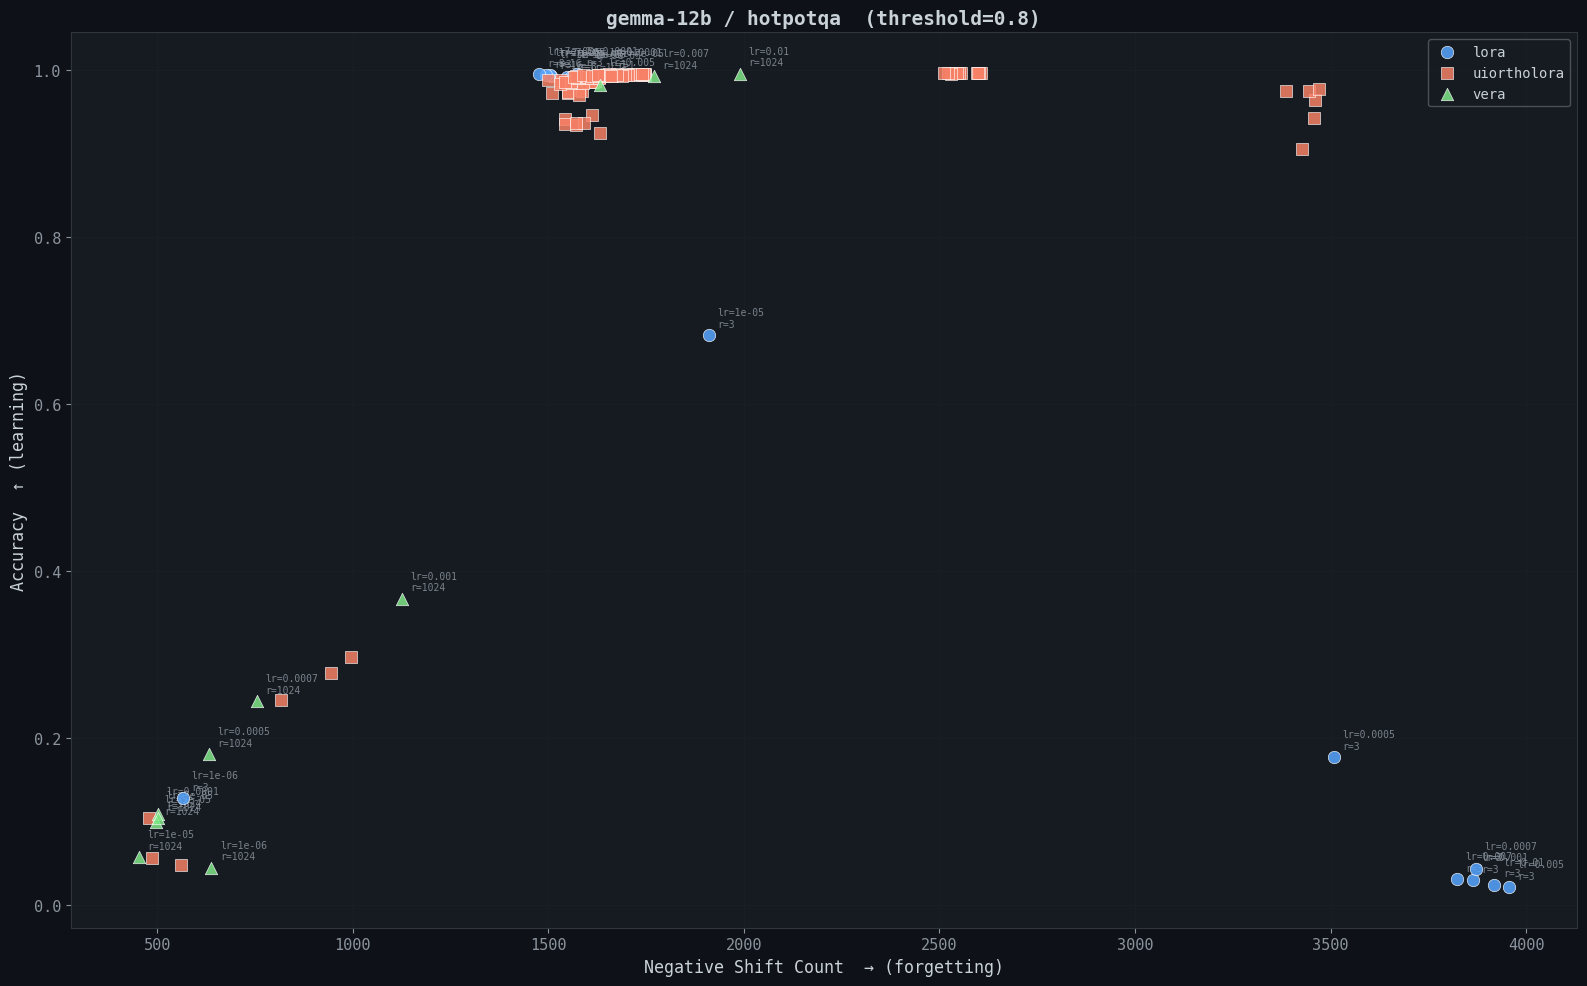


──────────────────────────────────────────────────────────────────────
  gemma-12b / hotpotqa  |  threshold=0.8  |  126 adapters
──────────────────────────────────────────────────────────────────────
  lora             n= 18  acc=[0.021–0.996]  neg=[566–3955]
  uiortholora      n= 97  acc=[0.048–0.997]  neg=[478–3471]
  vera             n= 11  acc=[0.045–0.996]  neg=[454–1989]



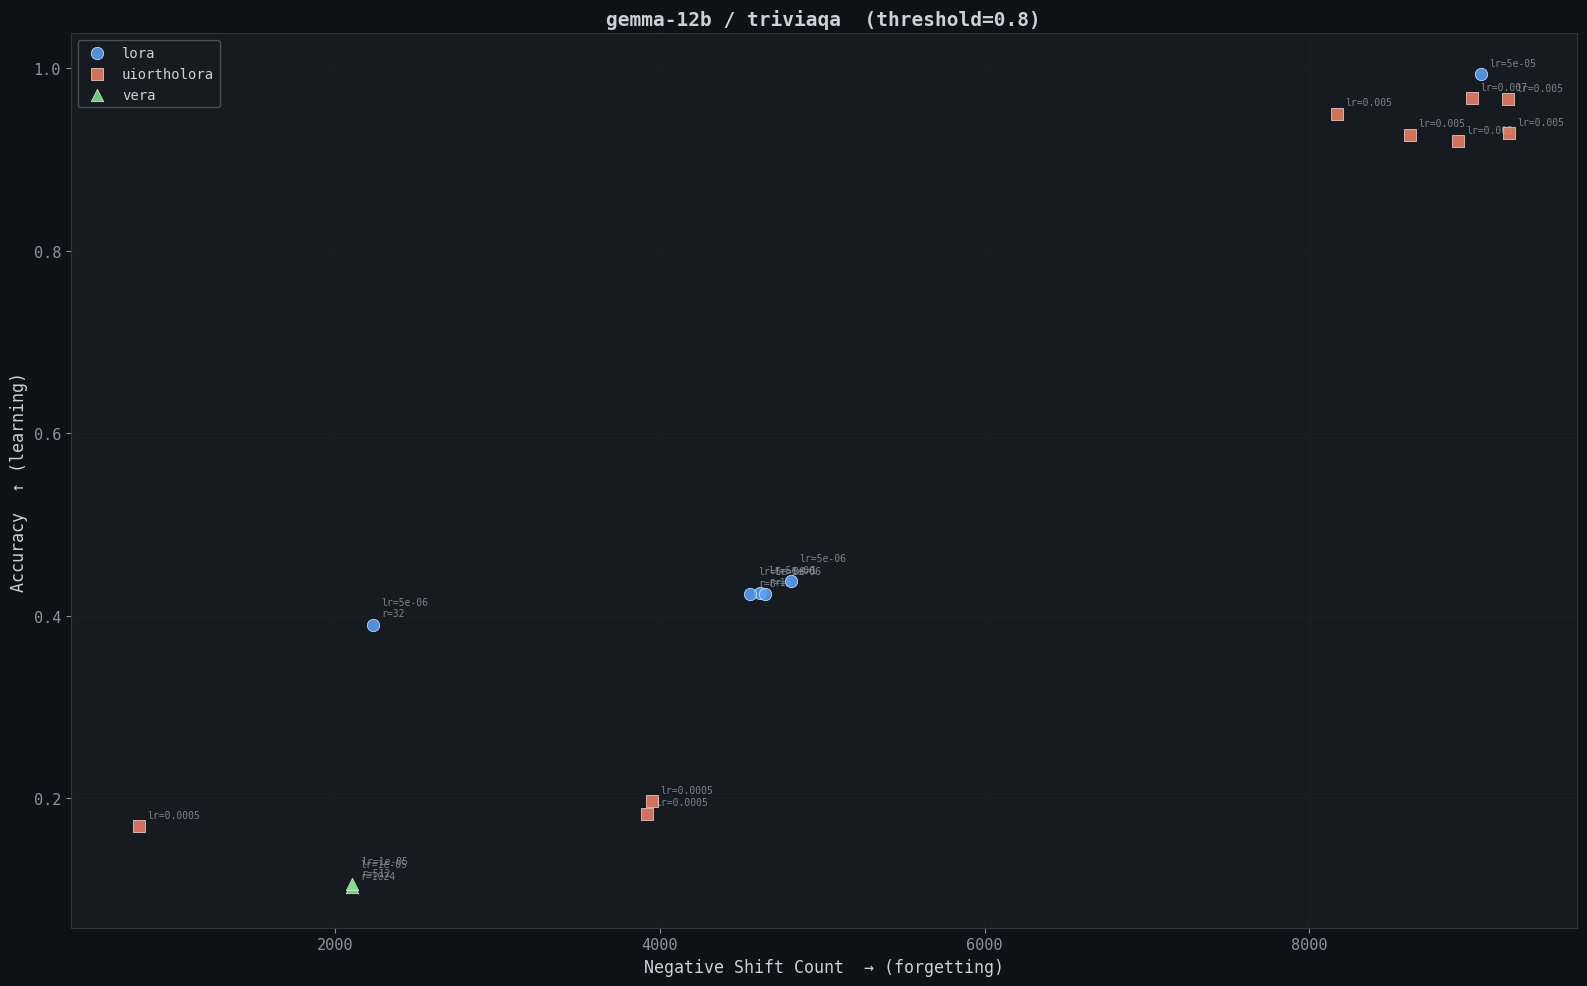


──────────────────────────────────────────────────────────────────────
  gemma-12b / triviaqa  |  threshold=0.8  |  17 adapters
──────────────────────────────────────────────────────────────────────
  lora             n=  6  acc=[0.390–0.993]  neg=[2233–9058]
  uiortholora      n=  9  acc=[0.169–0.967]  neg=[794–9227]
  vera             n=  2  acc=[0.103–0.106]  neg=[2107–2108]



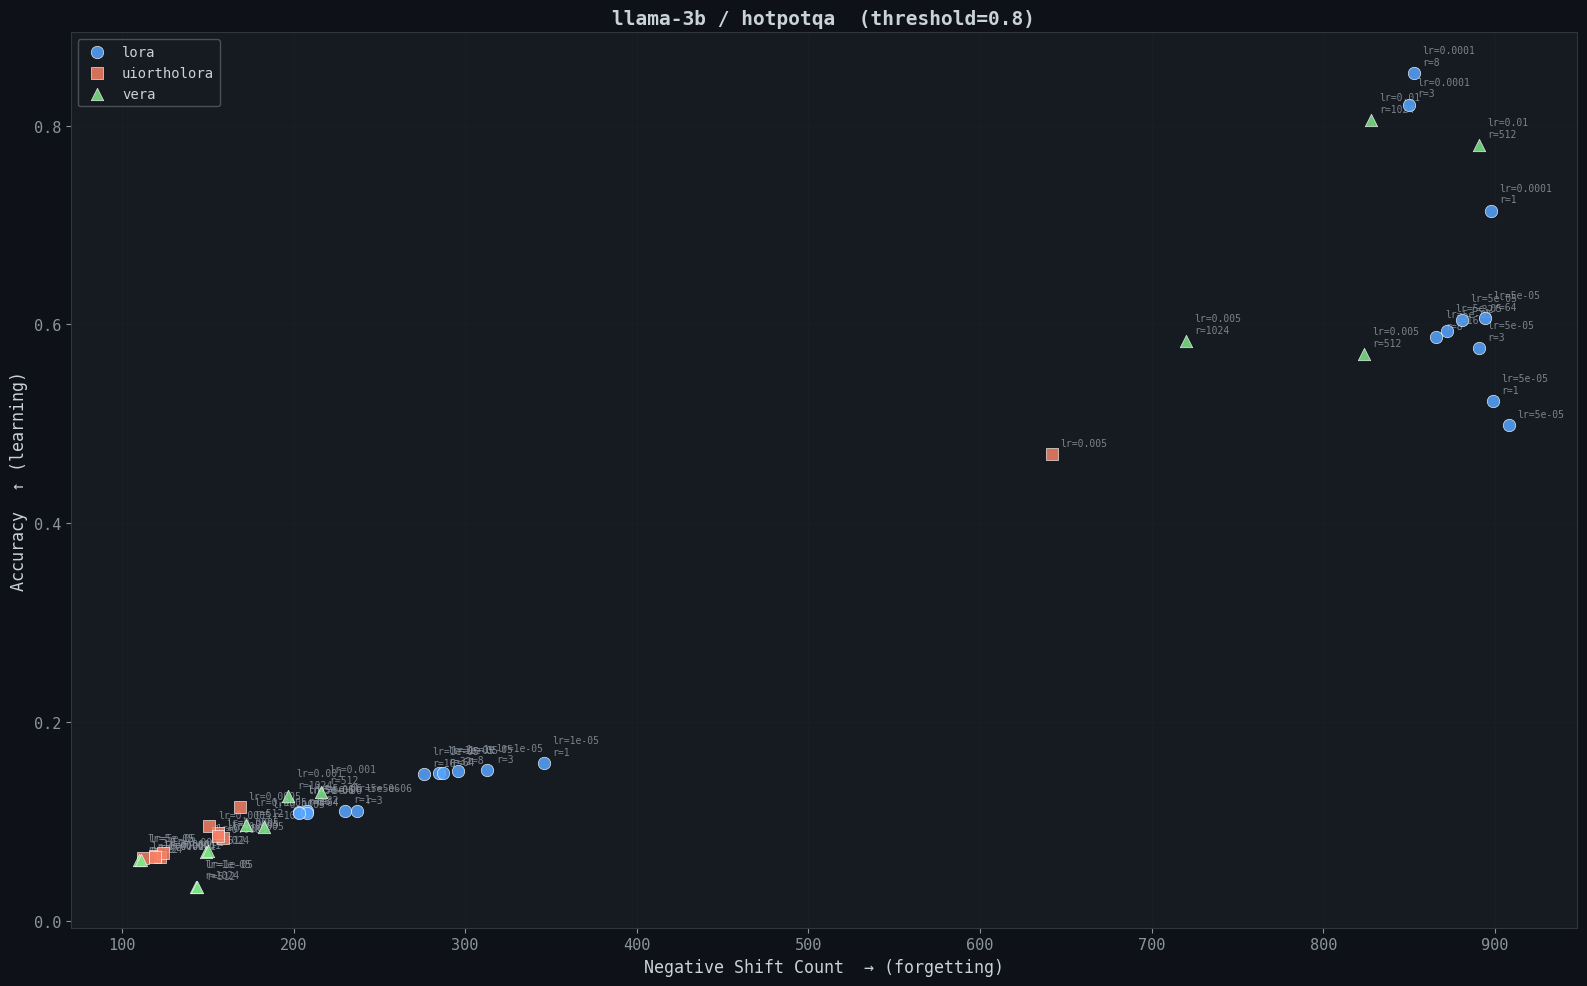


──────────────────────────────────────────────────────────────────────
  llama-3b / hotpotqa  |  threshold=0.8  |  47 adapters
──────────────────────────────────────────────────────────────────────
  lora             n= 22  acc=[0.108–0.853]  neg=[203–908]
  uiortholora      n= 11  acc=[0.063–0.470]  neg=[112–642]
  vera             n= 14  acc=[0.034–0.805]  neg=[110–891]



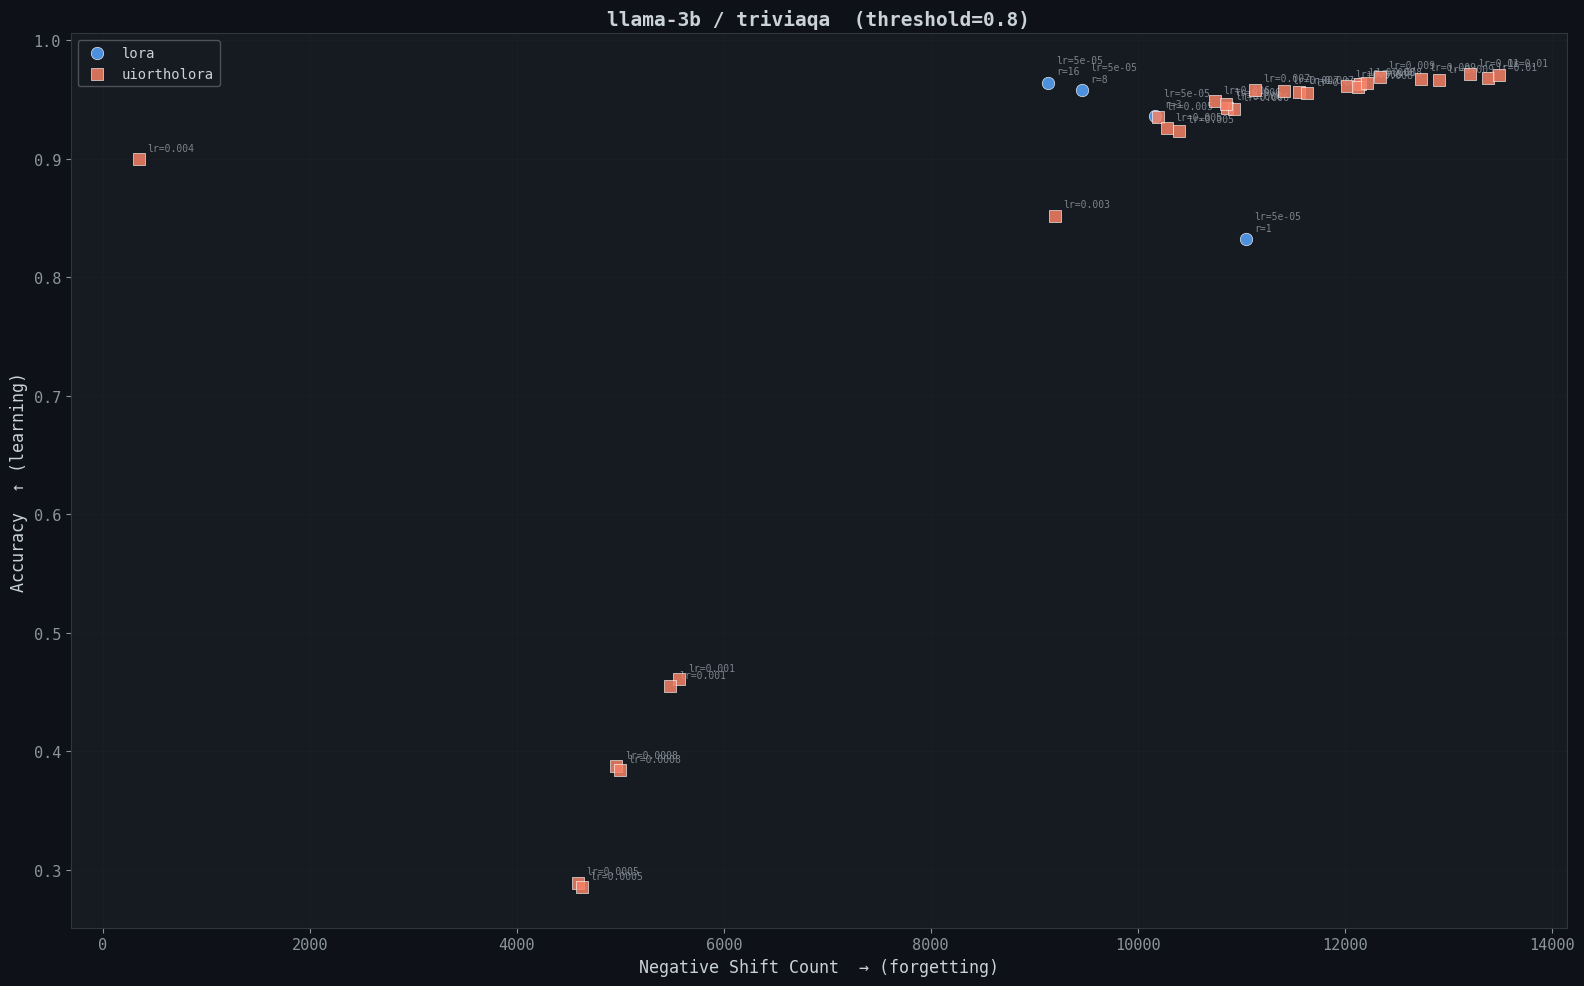


──────────────────────────────────────────────────────────────────────
  llama-3b / triviaqa  |  threshold=0.8  |  33 adapters
──────────────────────────────────────────────────────────────────────
  lora             n=  4  acc=[0.832–0.964]  neg=[9132–11043]
  uiortholora      n= 29  acc=[0.285–0.971]  neg=[345–13493]



In [ ]:
# ── Cell 3: Scatter — One Large Plot Per Training Config ──────────────────
THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    fig, ax = plt.subplots(figsize=(16, 10))
    df = plot_scatter(model, dataset, THRESHOLD, ax)
    plt.tight_layout()
    plt.show()

    if not df.empty:
        print(f"\n{'─'*70}")
        print(f"  {model} / {dataset}  |  threshold={THRESHOLD}  |  {len(df)} adapters")
        print(f"{'─'*70}")
        for atype in sorted(df["adapter_type"].dropna().unique()):
            sub = df[df["adapter_type"] == atype]
            print(f"  {atype:15s}  n={len(sub):3d}  "
                  f"acc=[{sub['accuracy'].min():.3f}–{sub['accuracy'].max():.3f}]  "
                  f"neg=[{sub['negative_shift_count'].min()}–{sub['negative_shift_count'].max()}]")
        print()

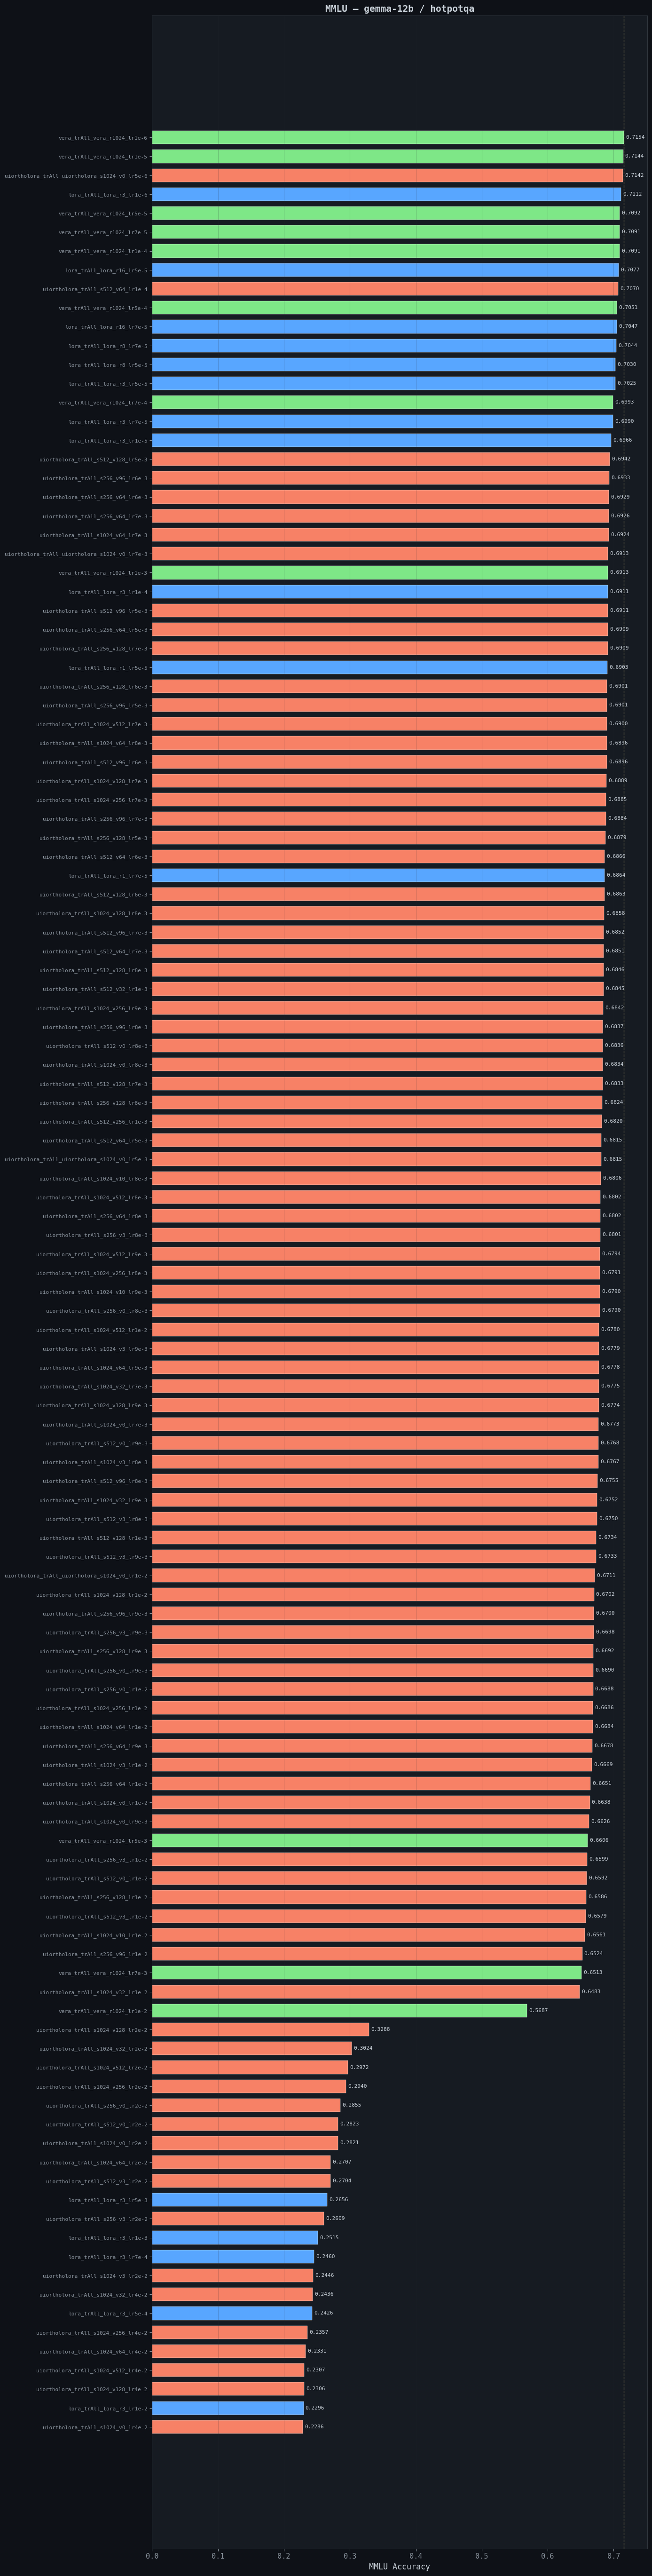

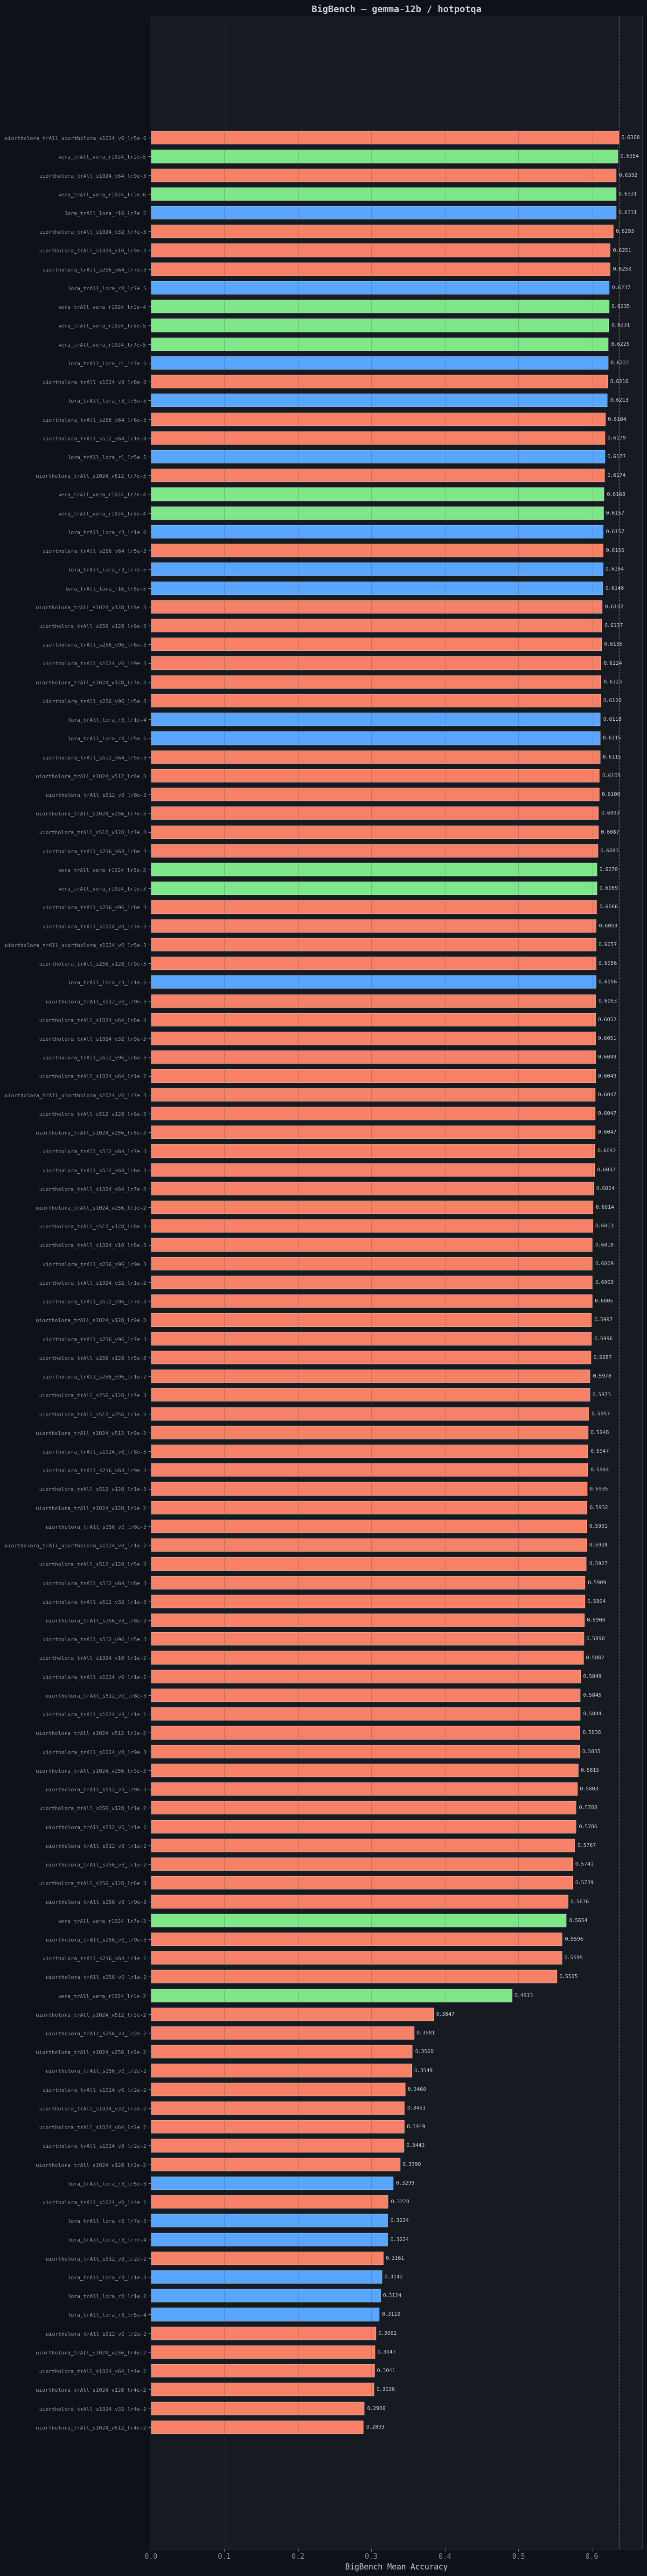

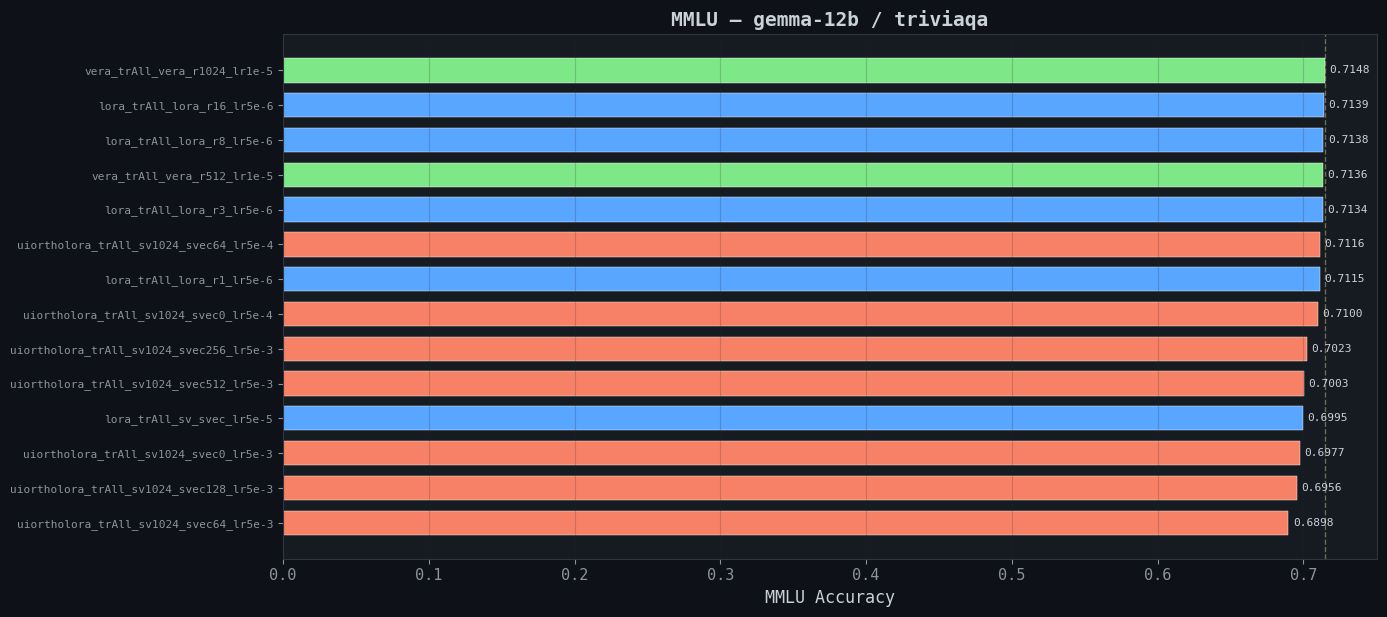

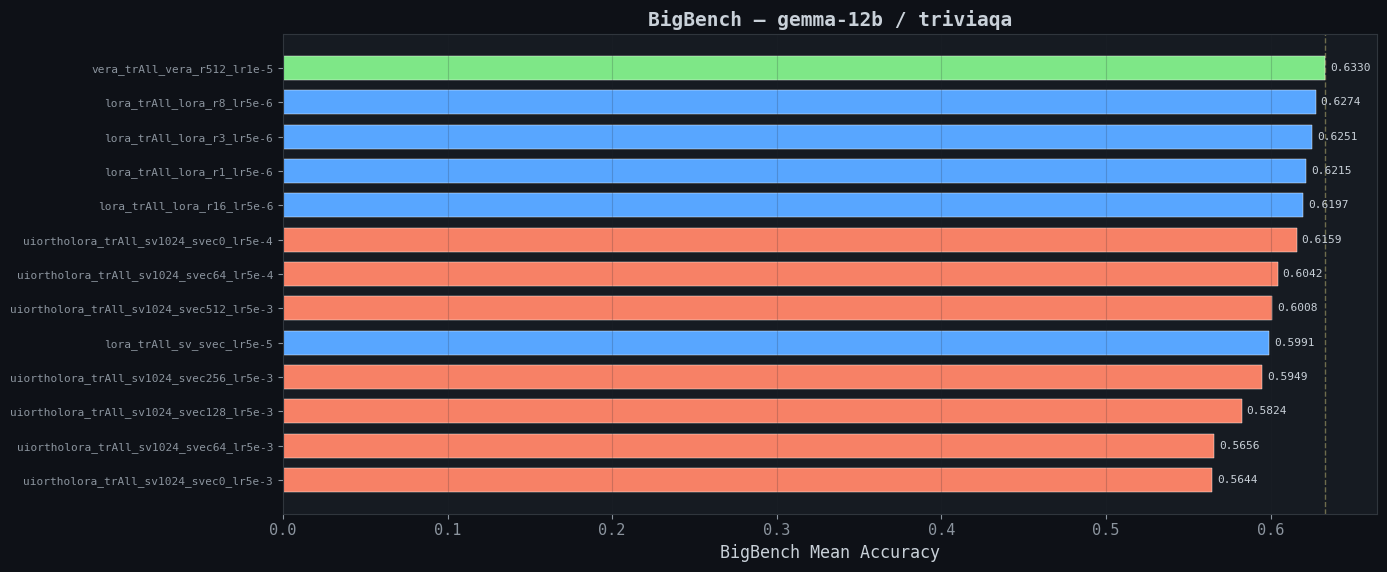

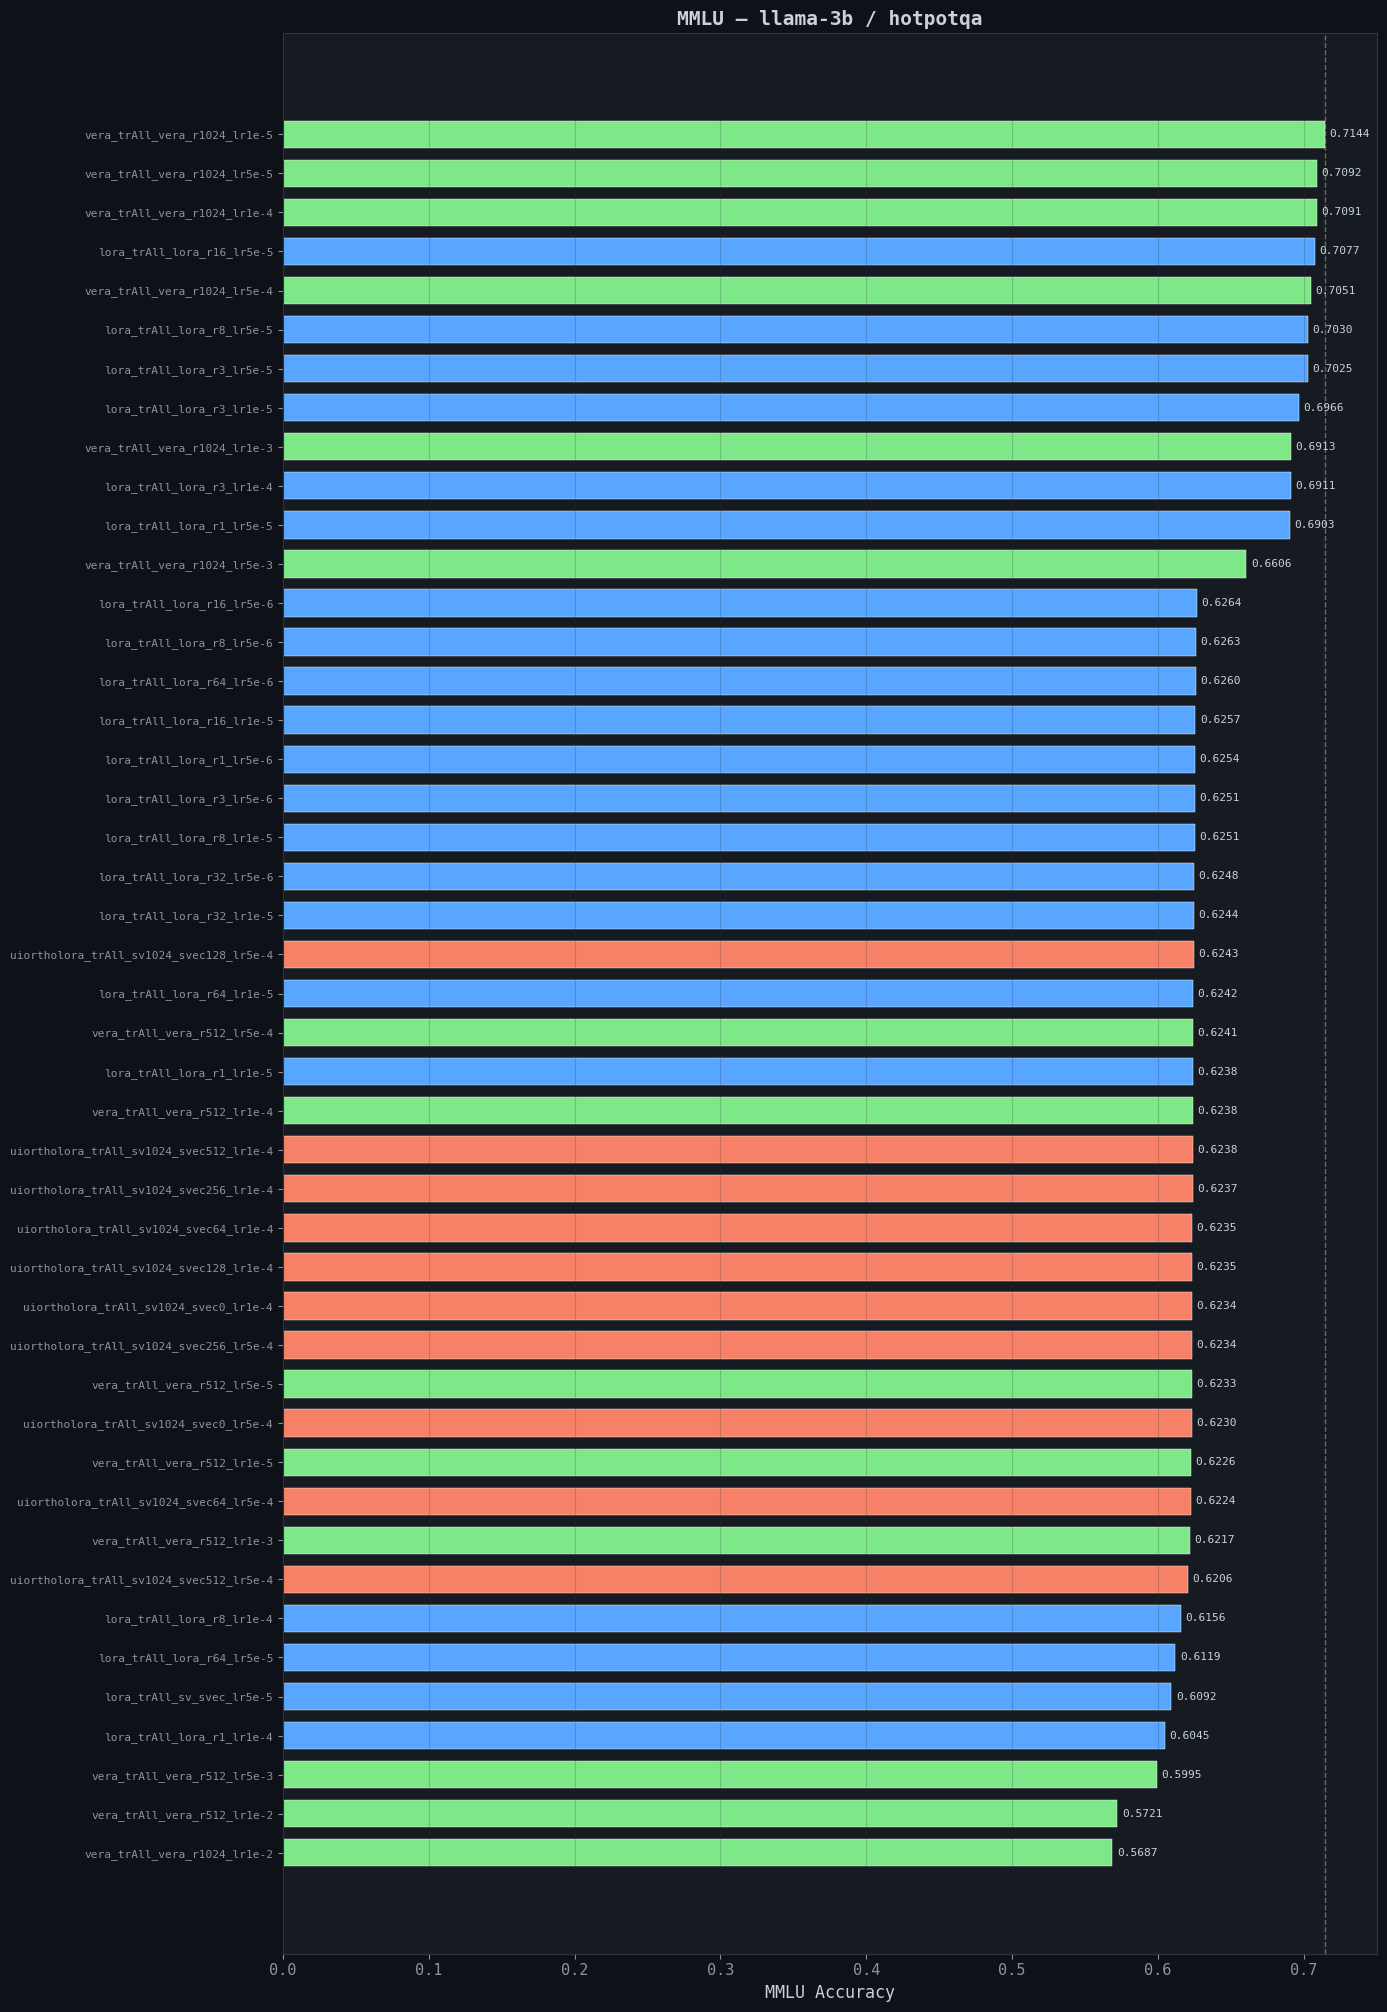

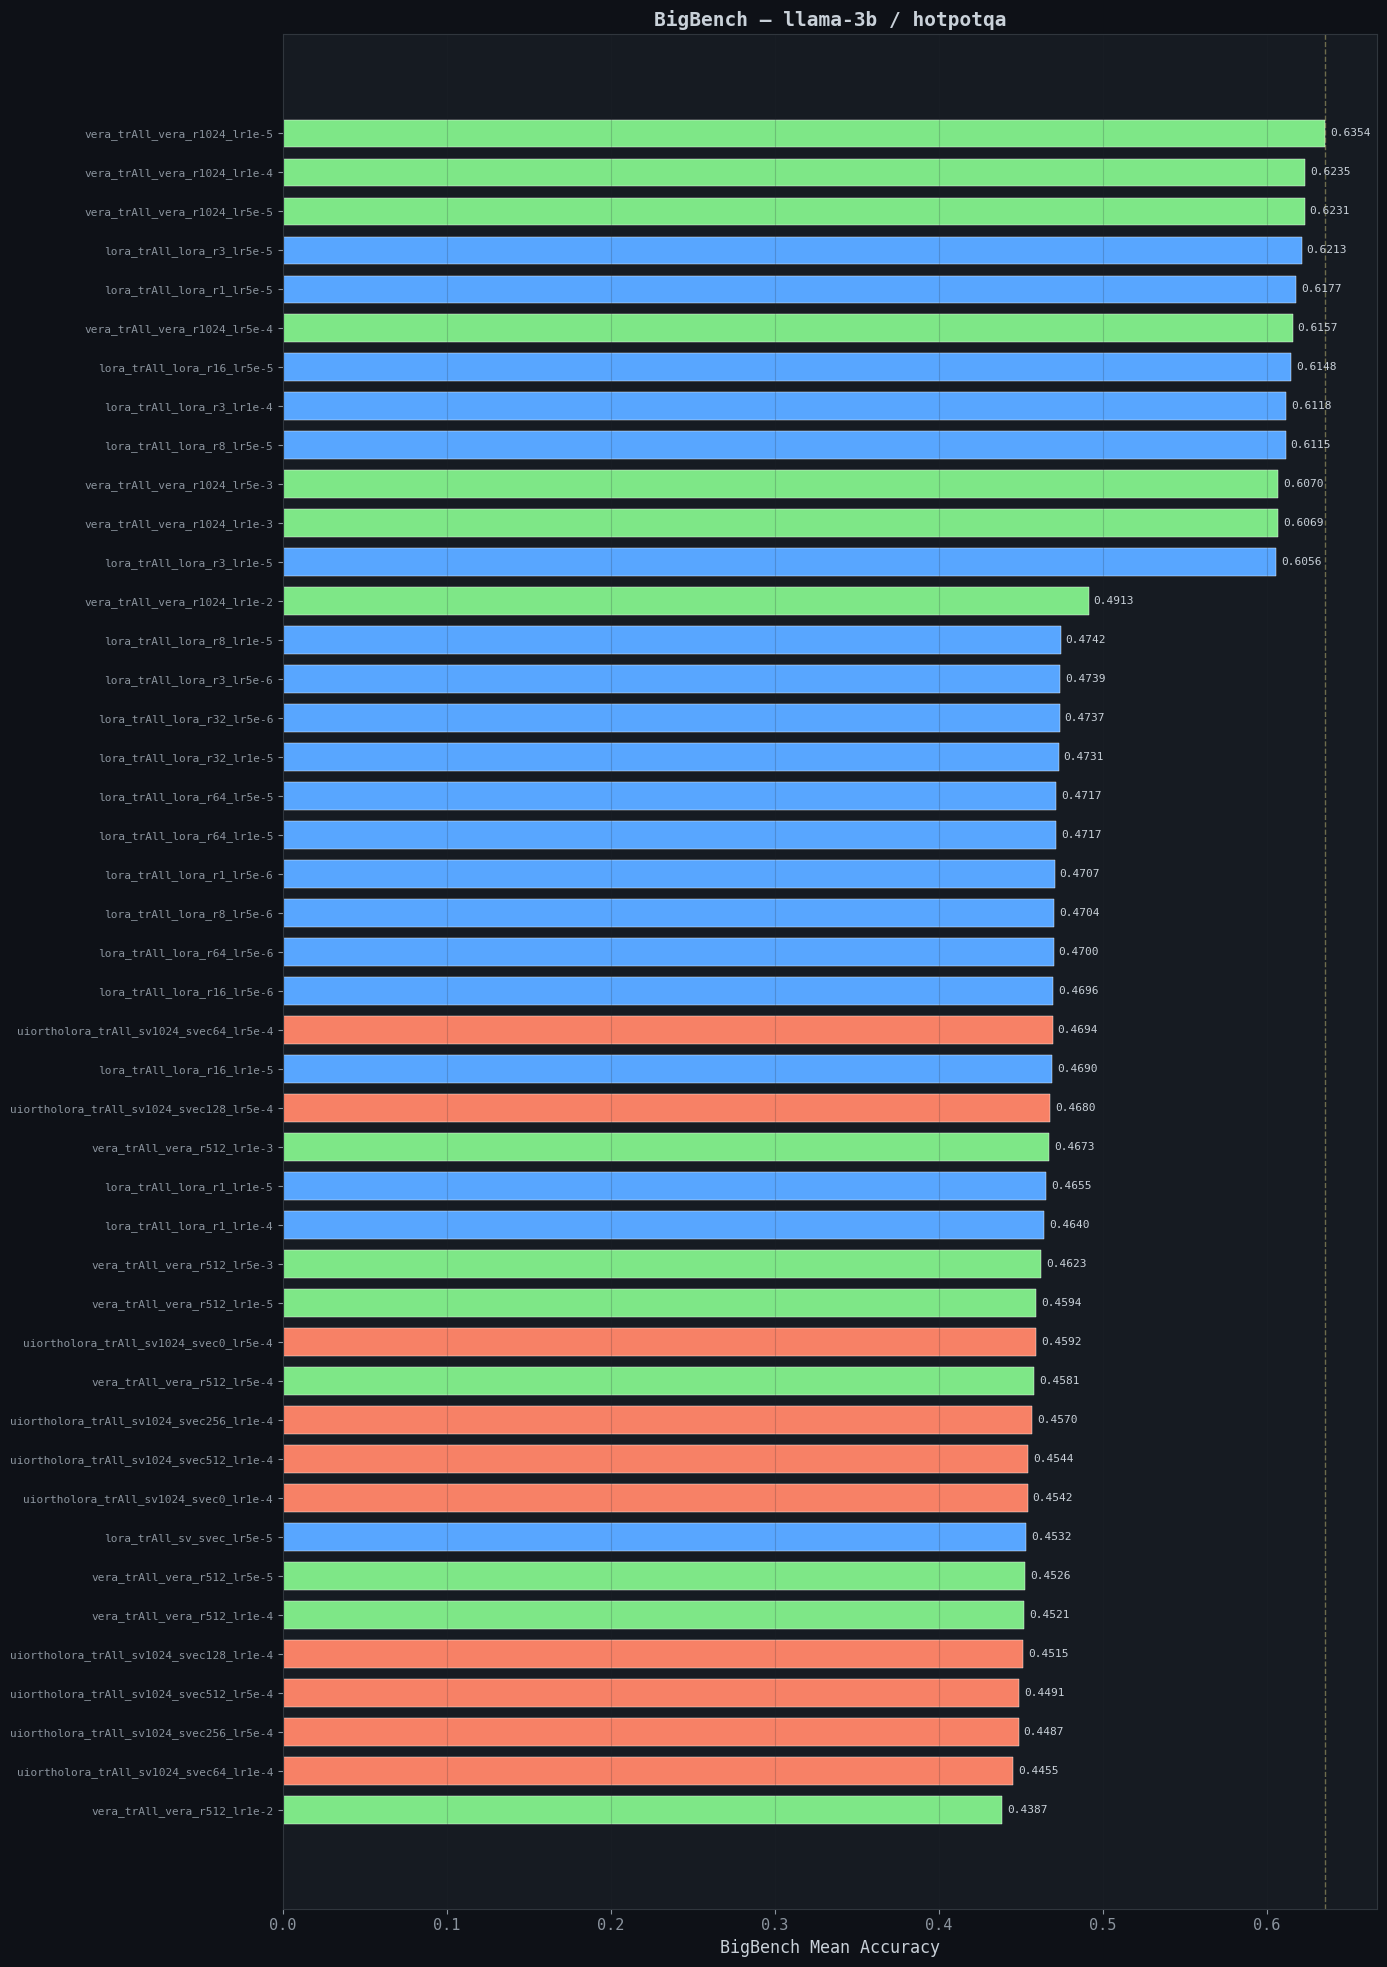

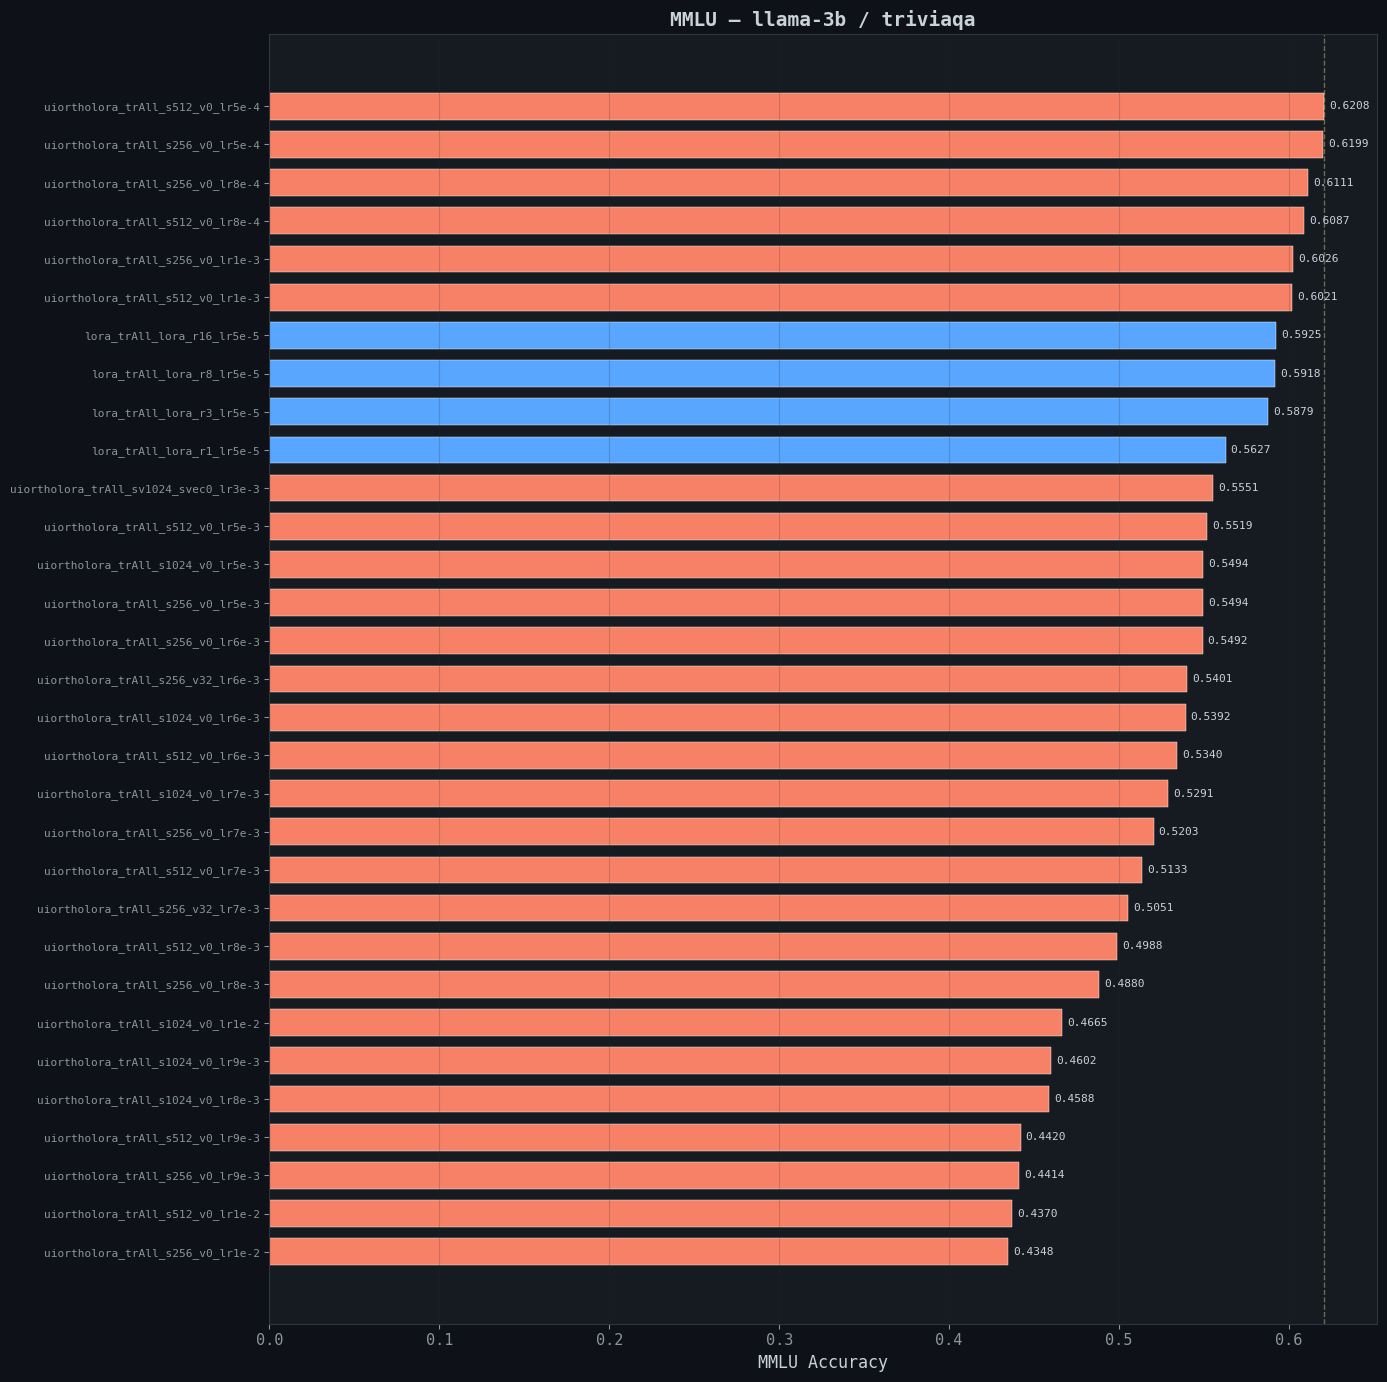

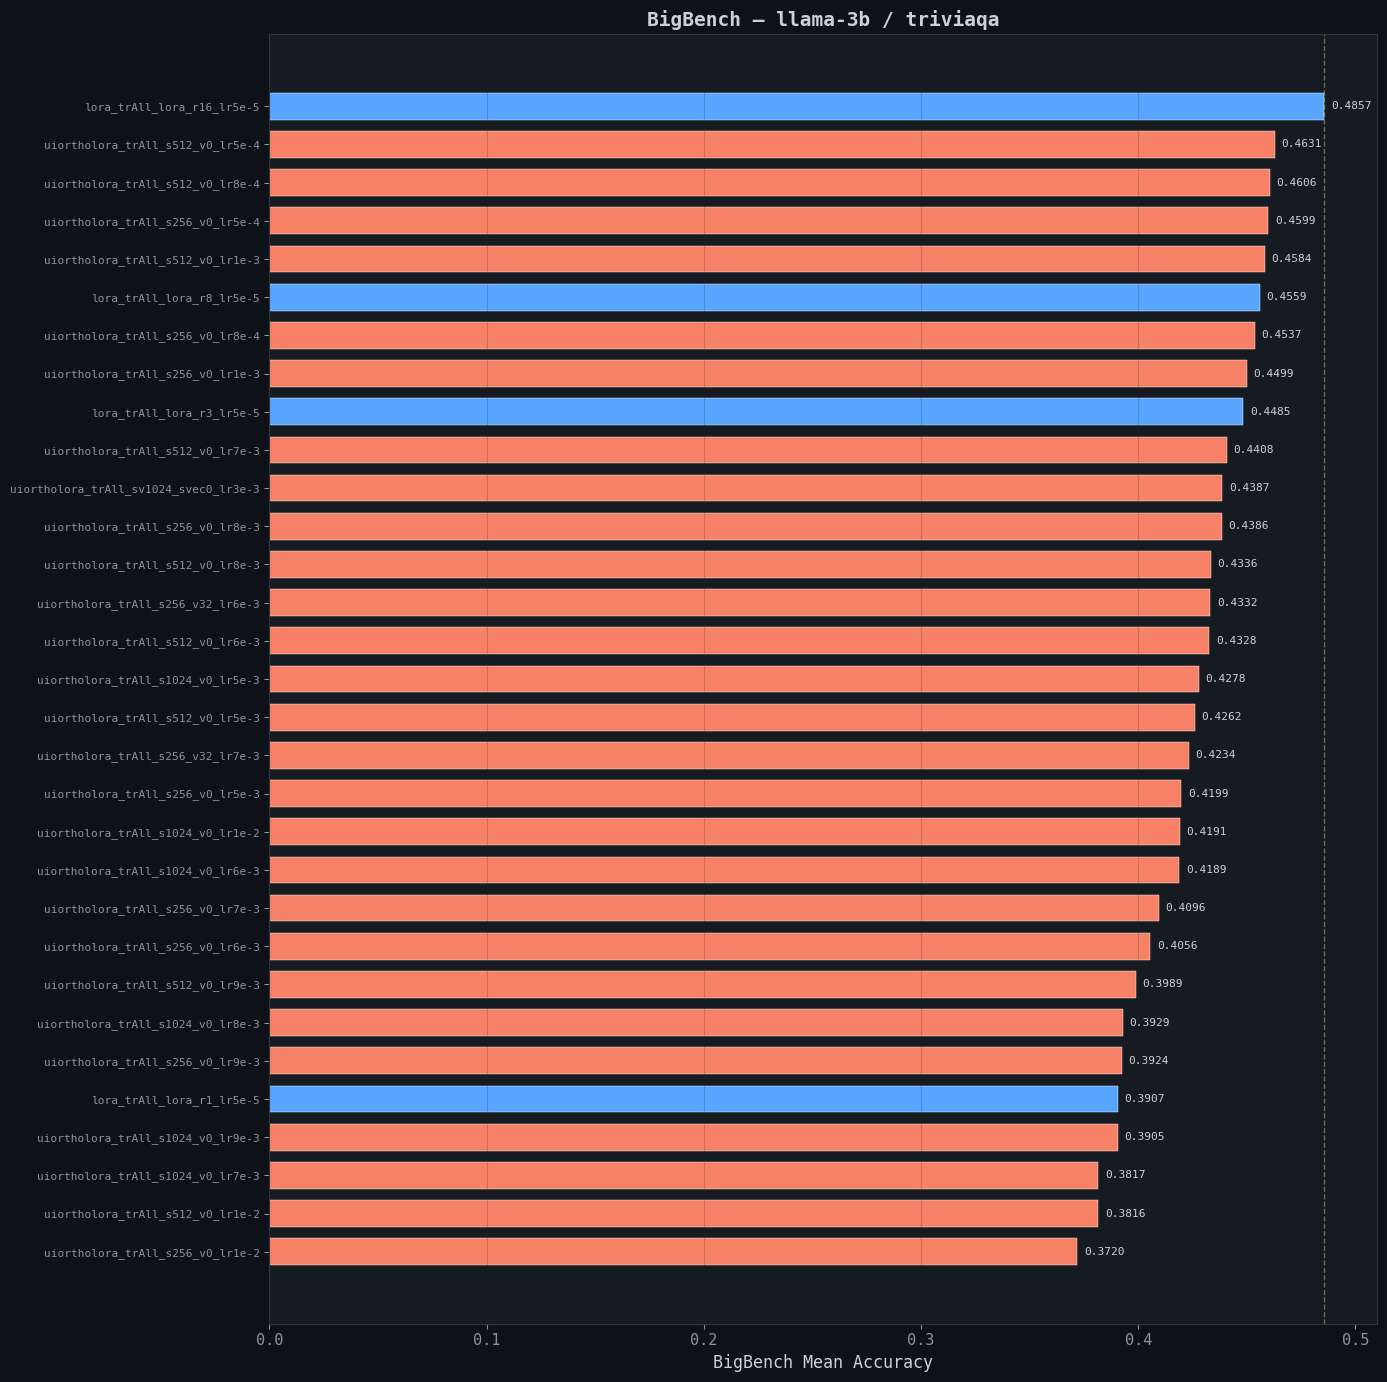

In [ ]:
# ── Cell 4: MMLU & BigBench — Bar Charts Per Config ───────────────────────

def plot_extrinsic_bars(model, dataset, threshold, metric, ylabel, title_suffix):
    """
    Bar chart of an extrinsic metric (mmlu_acc or bigbench_acc) per adapter,
    grouped by adapter_type, sorted by the metric value.
    """
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        return
    df = enrich_with_extrinsic(df, dataset)
    df = df.dropna(subset=[metric])
    if df.empty:
        print(f"  No {title_suffix} matches for {model}/{dataset}")
        return

    # Deduplicate: same raw_adapter_name can appear; keep first
    df = df.drop_duplicates(subset=["raw_adapter_name"])
    df = df.sort_values(metric, ascending=True)

    fig, ax = plt.subplots(figsize=(14, max(4, len(df) * 0.45)))

    y_pos = np.arange(len(df))
    colors = [ADAPTER_COLORS.get(t, "#999") for t in df["adapter_type"]]

    bars = ax.barh(y_pos, df[metric], color=colors, edgecolor="white", linewidth=0.3, height=0.7)

    # Short labels for y-axis
    labels = []
    for _, row in df.iterrows():
        name = row["raw_adapter_name"]
        # Trim common prefixes for readability
        for prefix in ["meta-llama_Llama-3.2-3B-Instruct_", "google_gemma-3-12b-it_"]:
            name = name.replace(prefix, "")
        labels.append(name)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(ylabel, fontsize=12)
    ax.set_title(f"{title_suffix} — {model} / {dataset}", fontsize=14, fontweight="bold")

    # Value labels on bars
    for bar, val in zip(bars, df[metric]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8, color="#c9d1d9")

    # Add a vertical reference line for the max
    ax.axvline(df[metric].max(), color="#f0e68c", linestyle="--", alpha=0.4, linewidth=1)

    ax.grid(True, alpha=0.2, axis="x")
    plt.tight_layout()
    plt.show()


THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    plot_extrinsic_bars(model, dataset, THRESHOLD, "mmlu_acc", "MMLU Accuracy", "MMLU")
    plot_extrinsic_bars(model, dataset, THRESHOLD, "bigbench_acc", "BigBench Mean Accuracy", "BigBench")

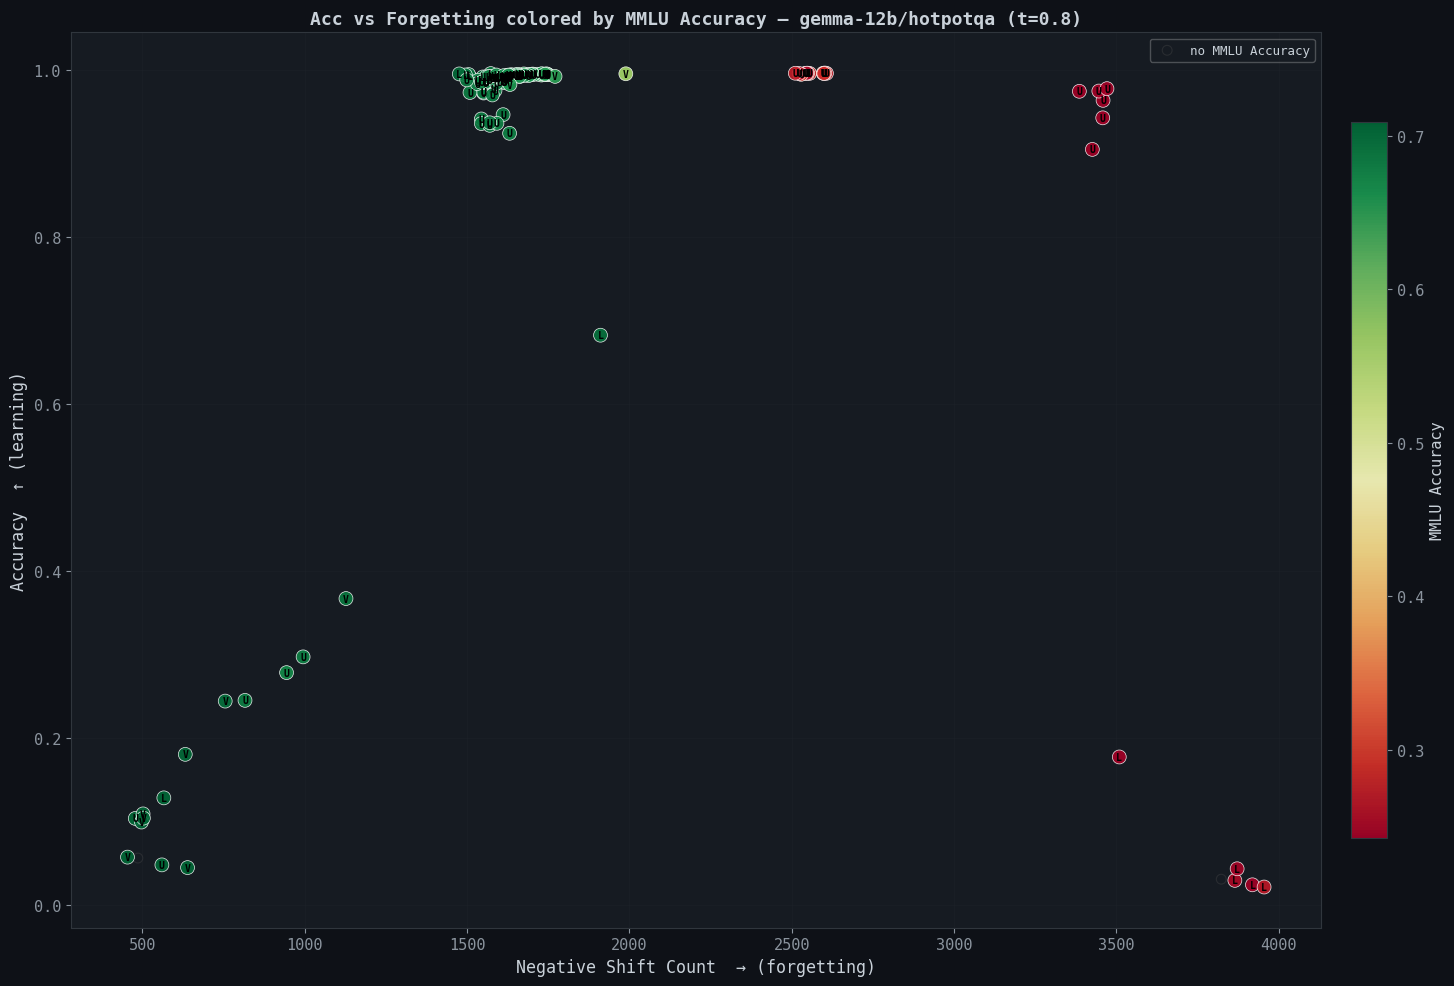

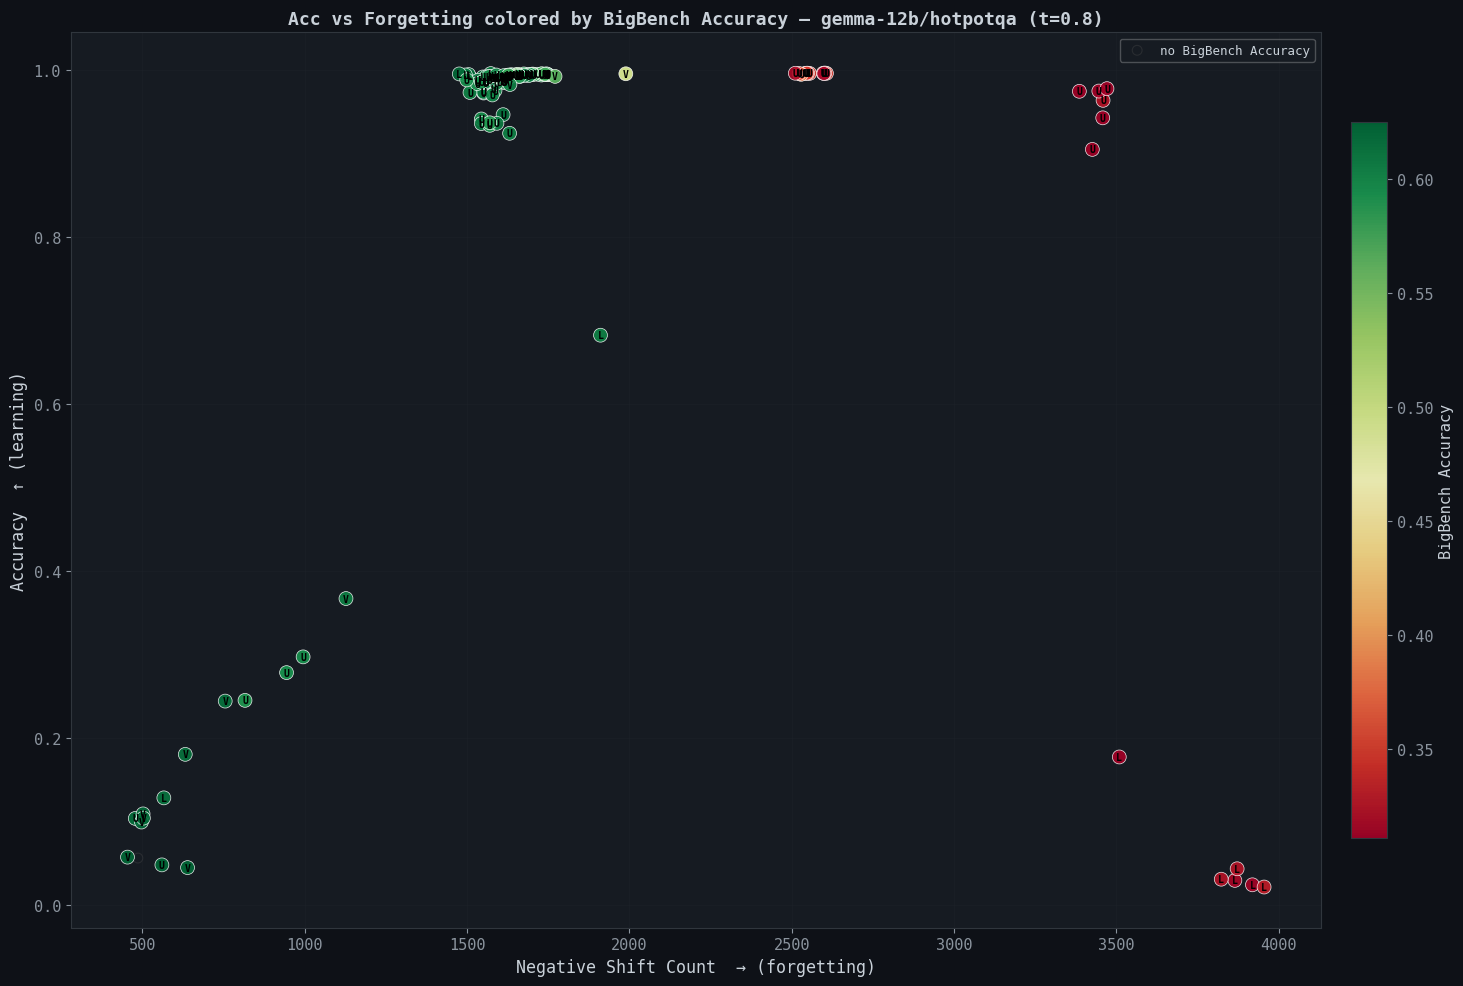

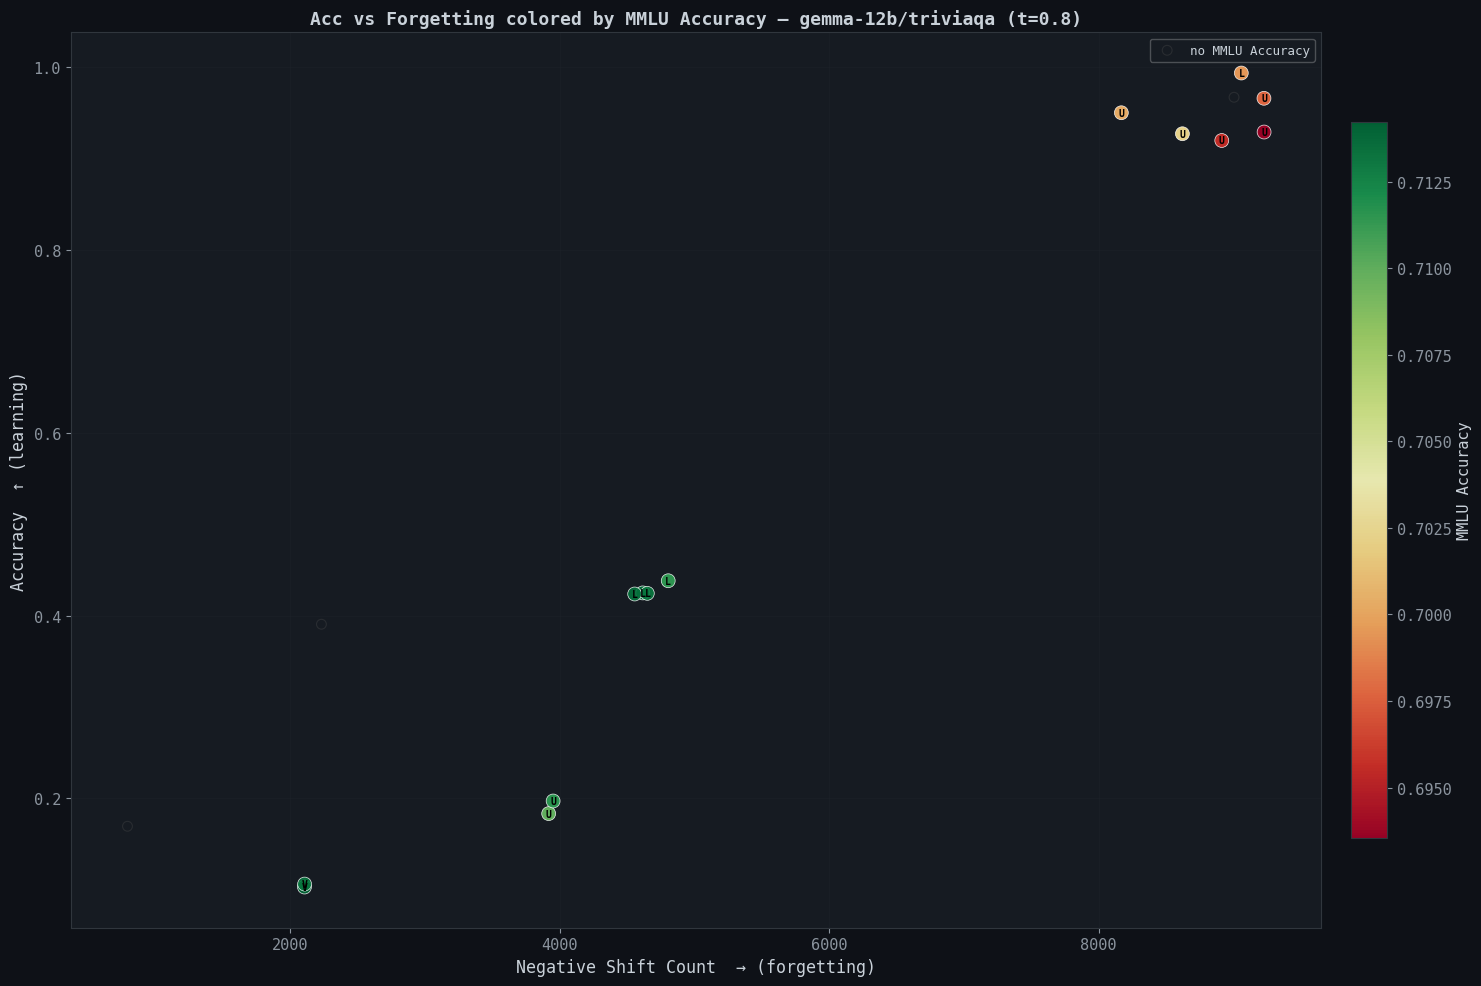

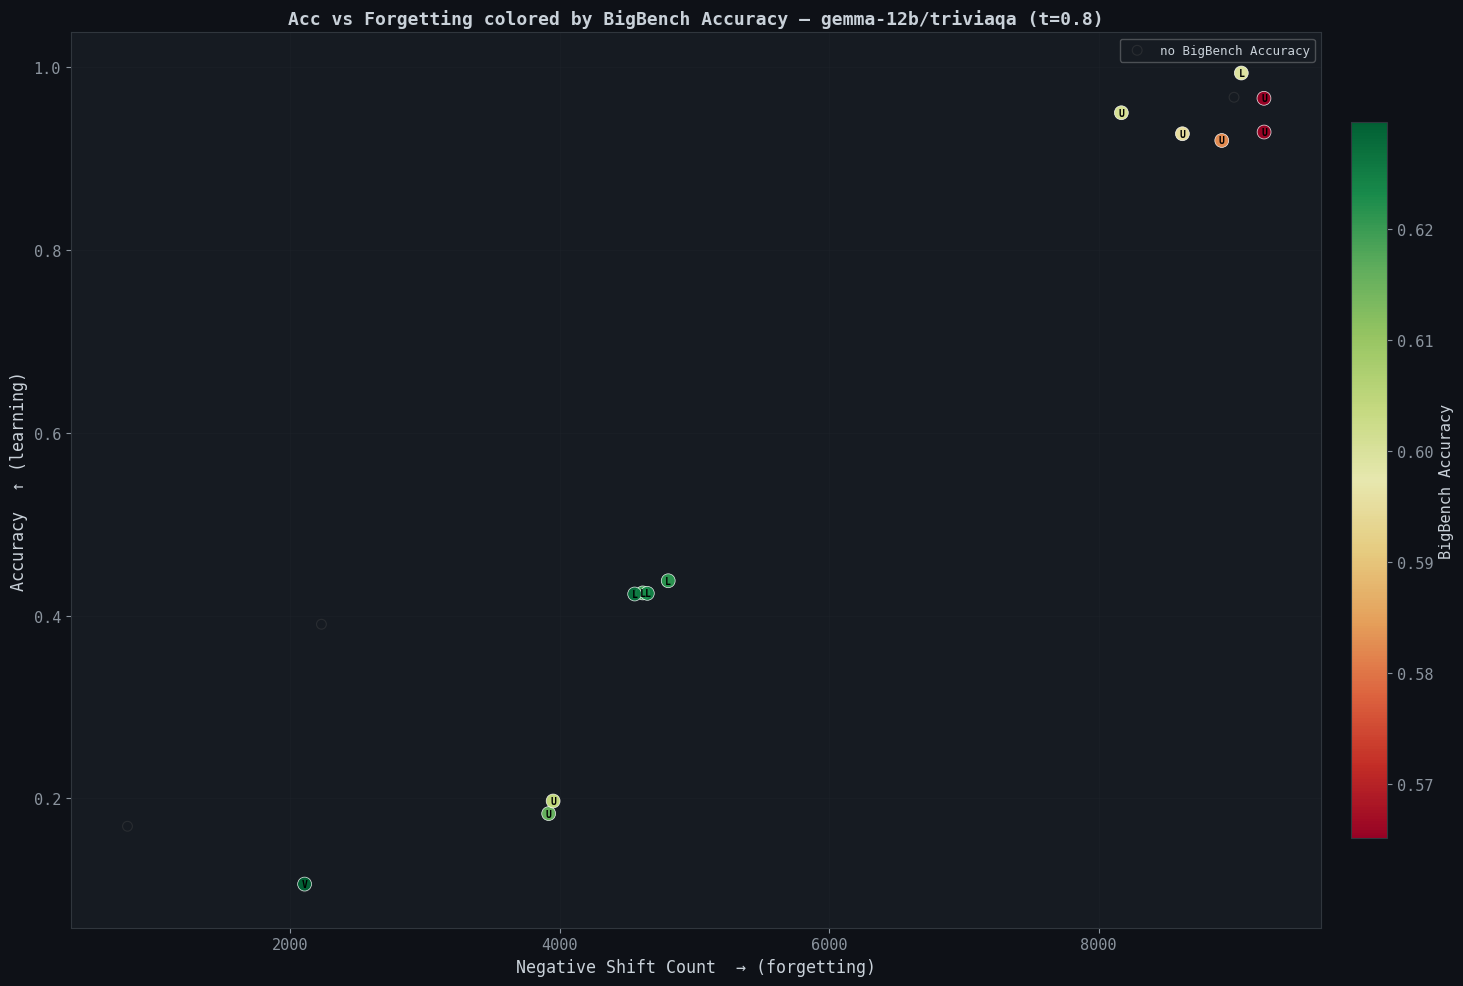

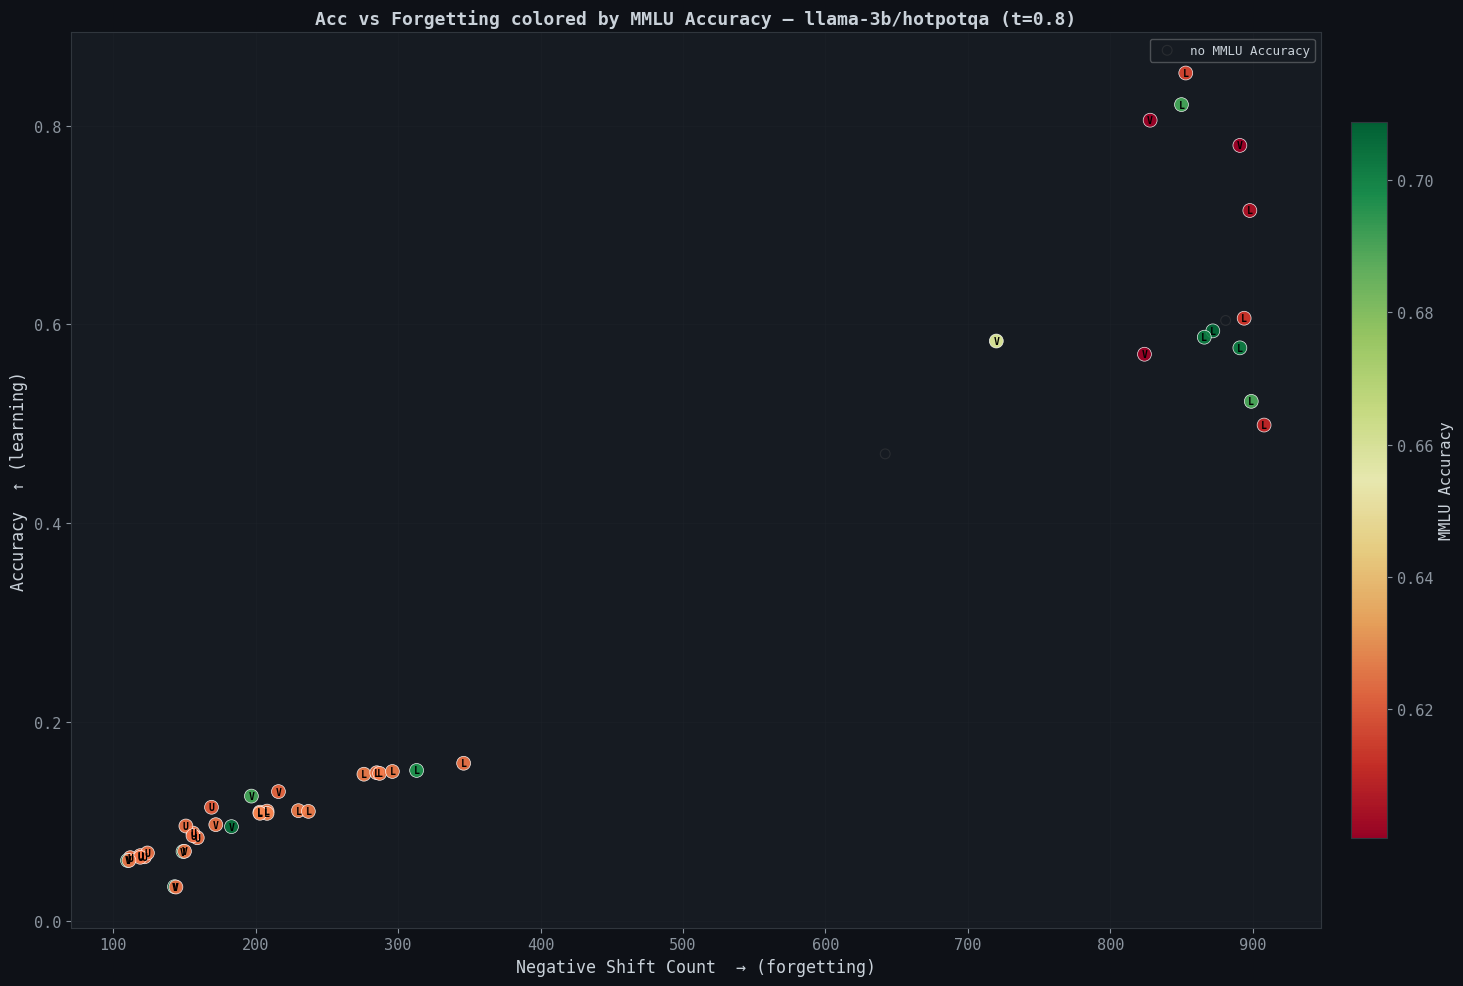

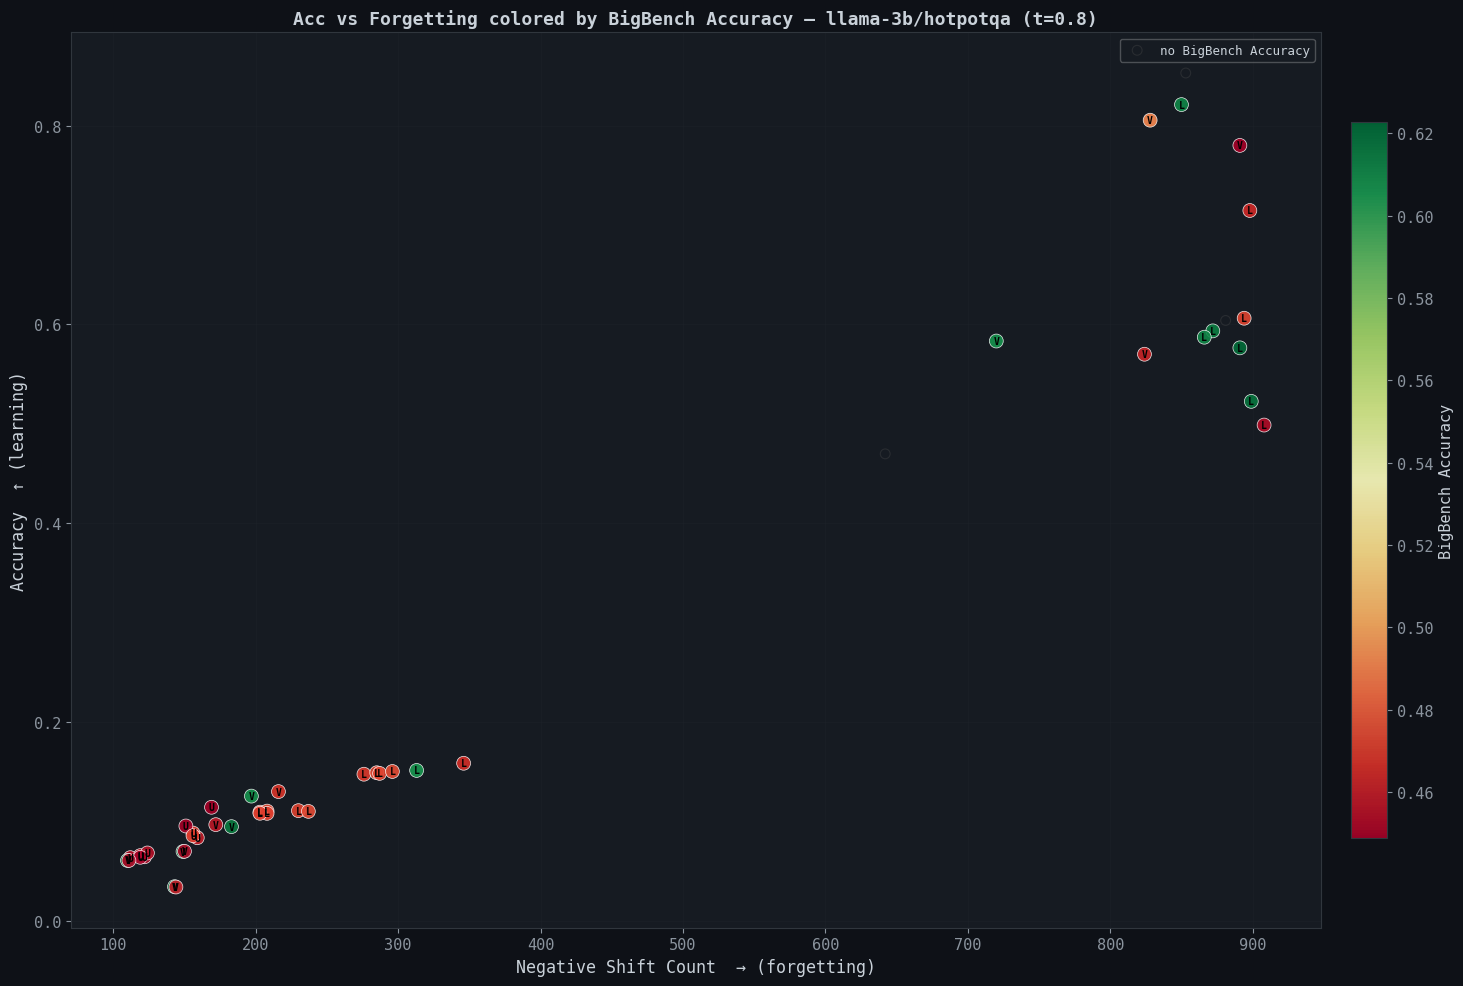

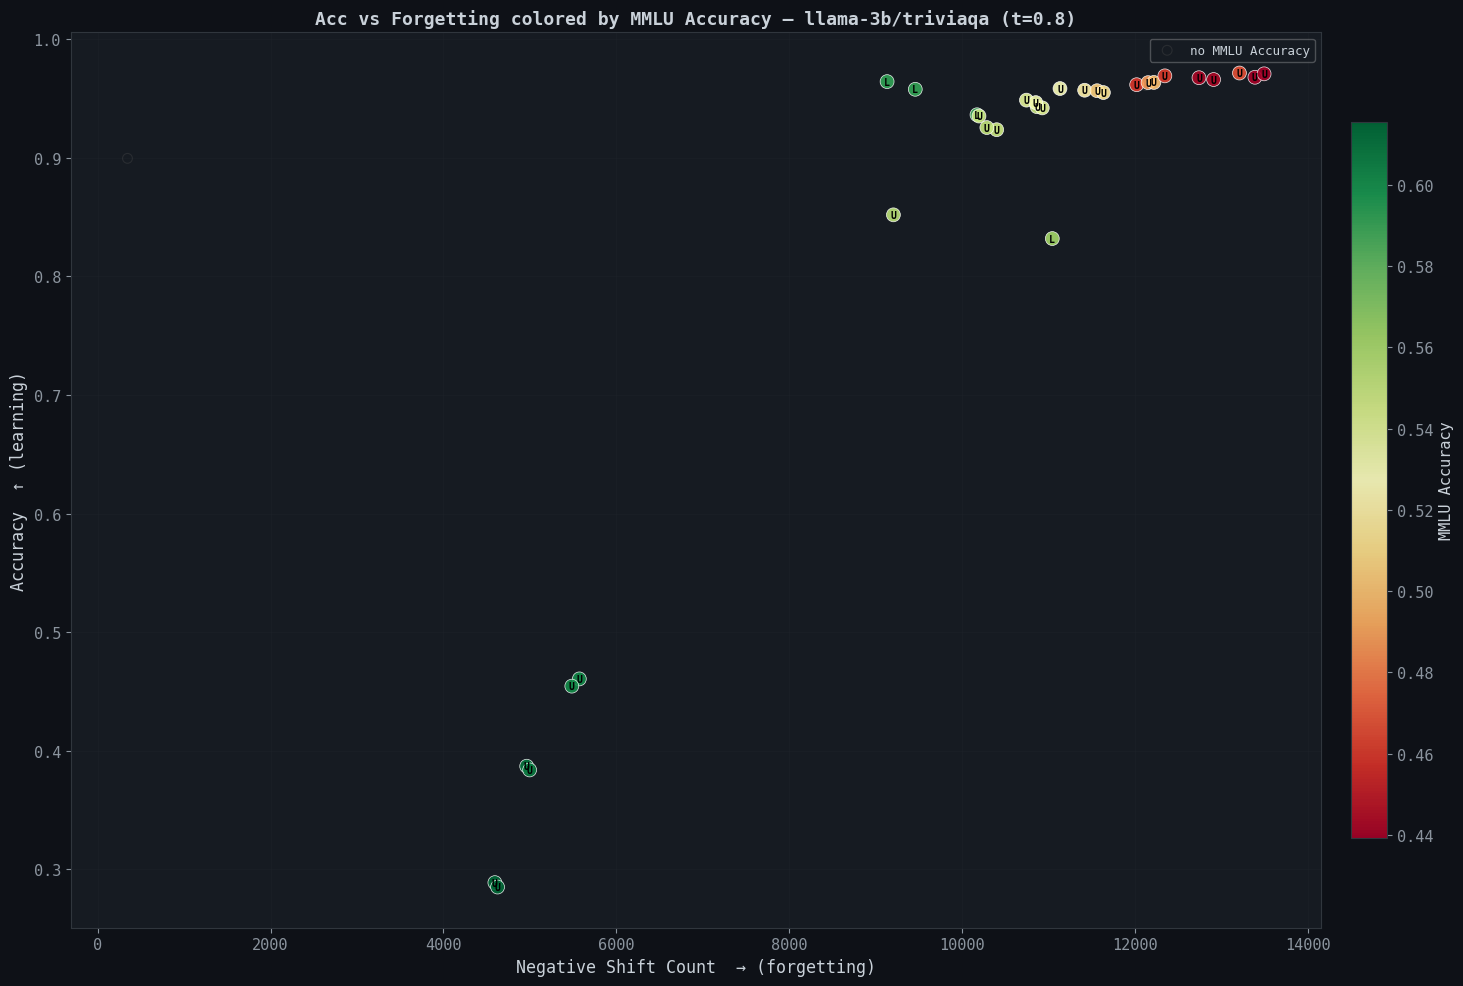

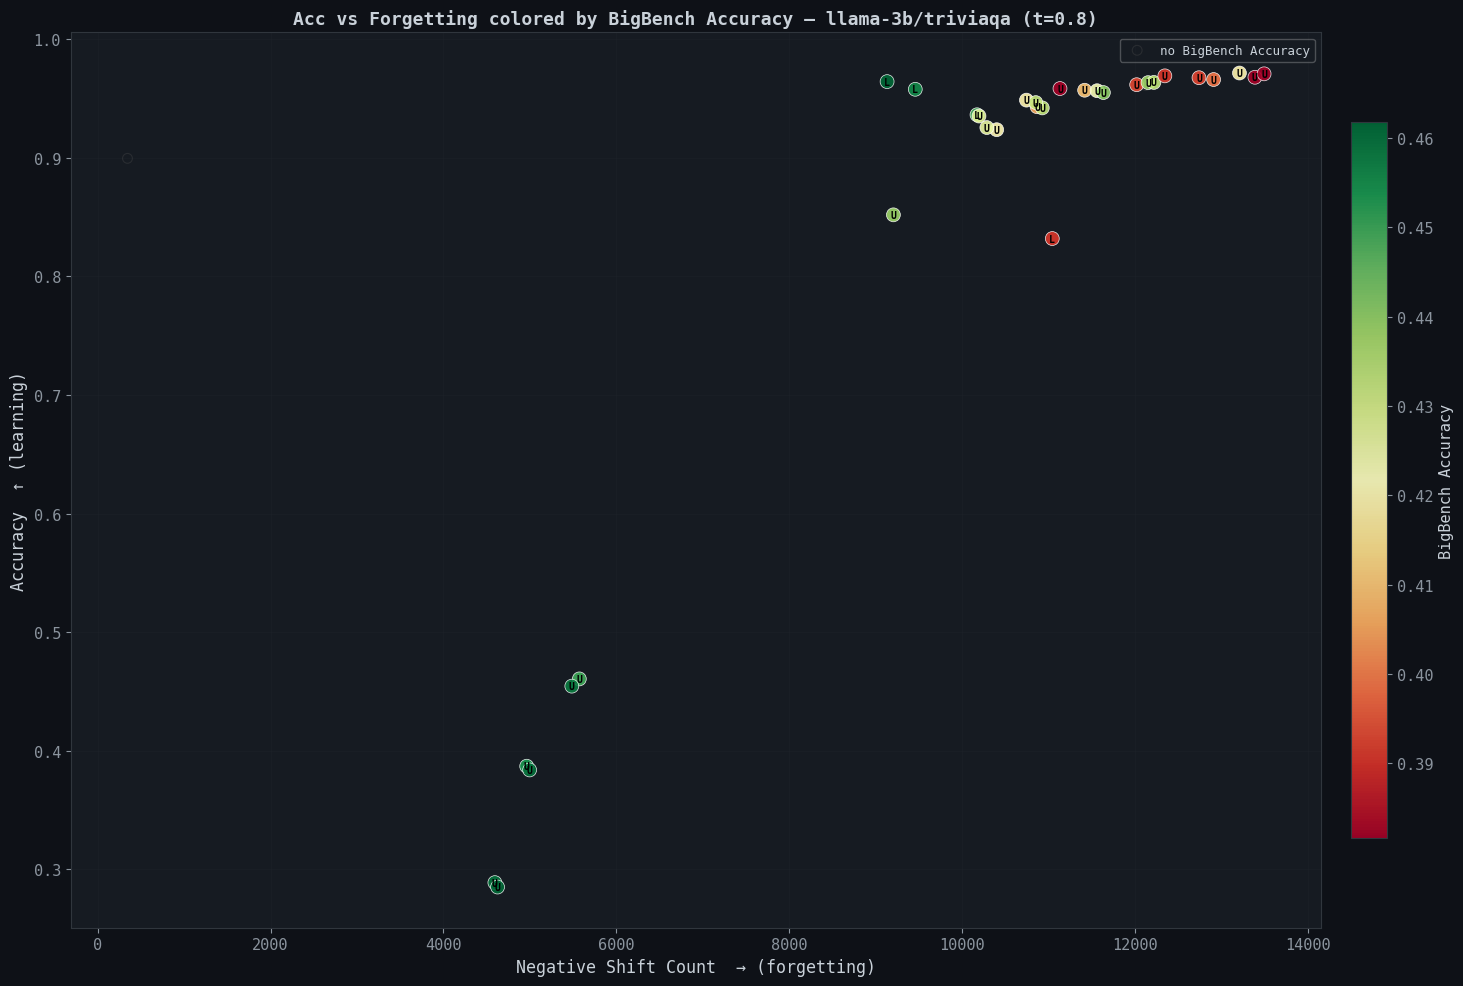

In [ ]:
# ── Cell 5: Scatter with MMLU/BigBench as Color ──────────────────────────
def plot_scatter_colored_by_extrinsic(model, dataset, threshold, metric, metric_label):
    """
    Same accuracy-vs-forgetting scatter, but points are colored by
    an extrinsic metric (MMLU or BigBench) instead of adapter type.
    Missing extrinsic values are shown as grey hollow circles.
    """
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        return
    df = enrich_with_extrinsic(df, dataset)

    has_metric = df[df[metric].notna()]
    no_metric = df[df[metric].isna()]

    if has_metric.empty:
        print(f"  No {metric_label} data for {model}/{dataset}")
        return

    fig, ax = plt.subplots(figsize=(16, 10))

    # Grey background points (no extrinsic match)
    if not no_metric.empty:
        ax.scatter(no_metric["negative_shift_count"], no_metric["accuracy"],
                   c="none", edgecolors="#555", s=50, alpha=0.3, linewidths=0.8,
                   label=f"no {metric_label}", zorder=3)

    # Colored points
    vmin = has_metric[metric].quantile(0.05)
    vmax = has_metric[metric].quantile(0.95)
    sc = ax.scatter(
        has_metric["negative_shift_count"], has_metric["accuracy"],
        c=has_metric[metric], cmap="RdYlGn", vmin=vmin, vmax=vmax,
        s=100, alpha=0.9, edgecolors="white", linewidths=0.5, zorder=5,
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label(metric_label, fontsize=11)

    # Annotate with adapter type marker
    for _, row in has_metric.iterrows():
        atype = row.get("adapter_type", "")
        marker_char = {"lora": "L", "uiortholora": "U", "vera": "V", "randlora": "R"}.get(atype, "?")
        ax.annotate(marker_char, (row["negative_shift_count"], row["accuracy"]),
                    ha="center", va="center", fontsize=7, fontweight="bold", color="#000", zorder=6)

    ax.set_xlabel("Negative Shift Count  → (forgetting)", fontsize=12)
    ax.set_ylabel("Accuracy  ↑ (learning)", fontsize=12)
    ax.set_title(f"Acc vs Forgetting colored by {metric_label} — {model}/{dataset} (t={threshold})",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="best", framealpha=0.3, fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    plot_scatter_colored_by_extrinsic(model, dataset, THRESHOLD, "mmlu_acc", "MMLU Accuracy")
    plot_scatter_colored_by_extrinsic(model, dataset, THRESHOLD, "bigbench_acc", "BigBench Accuracy")

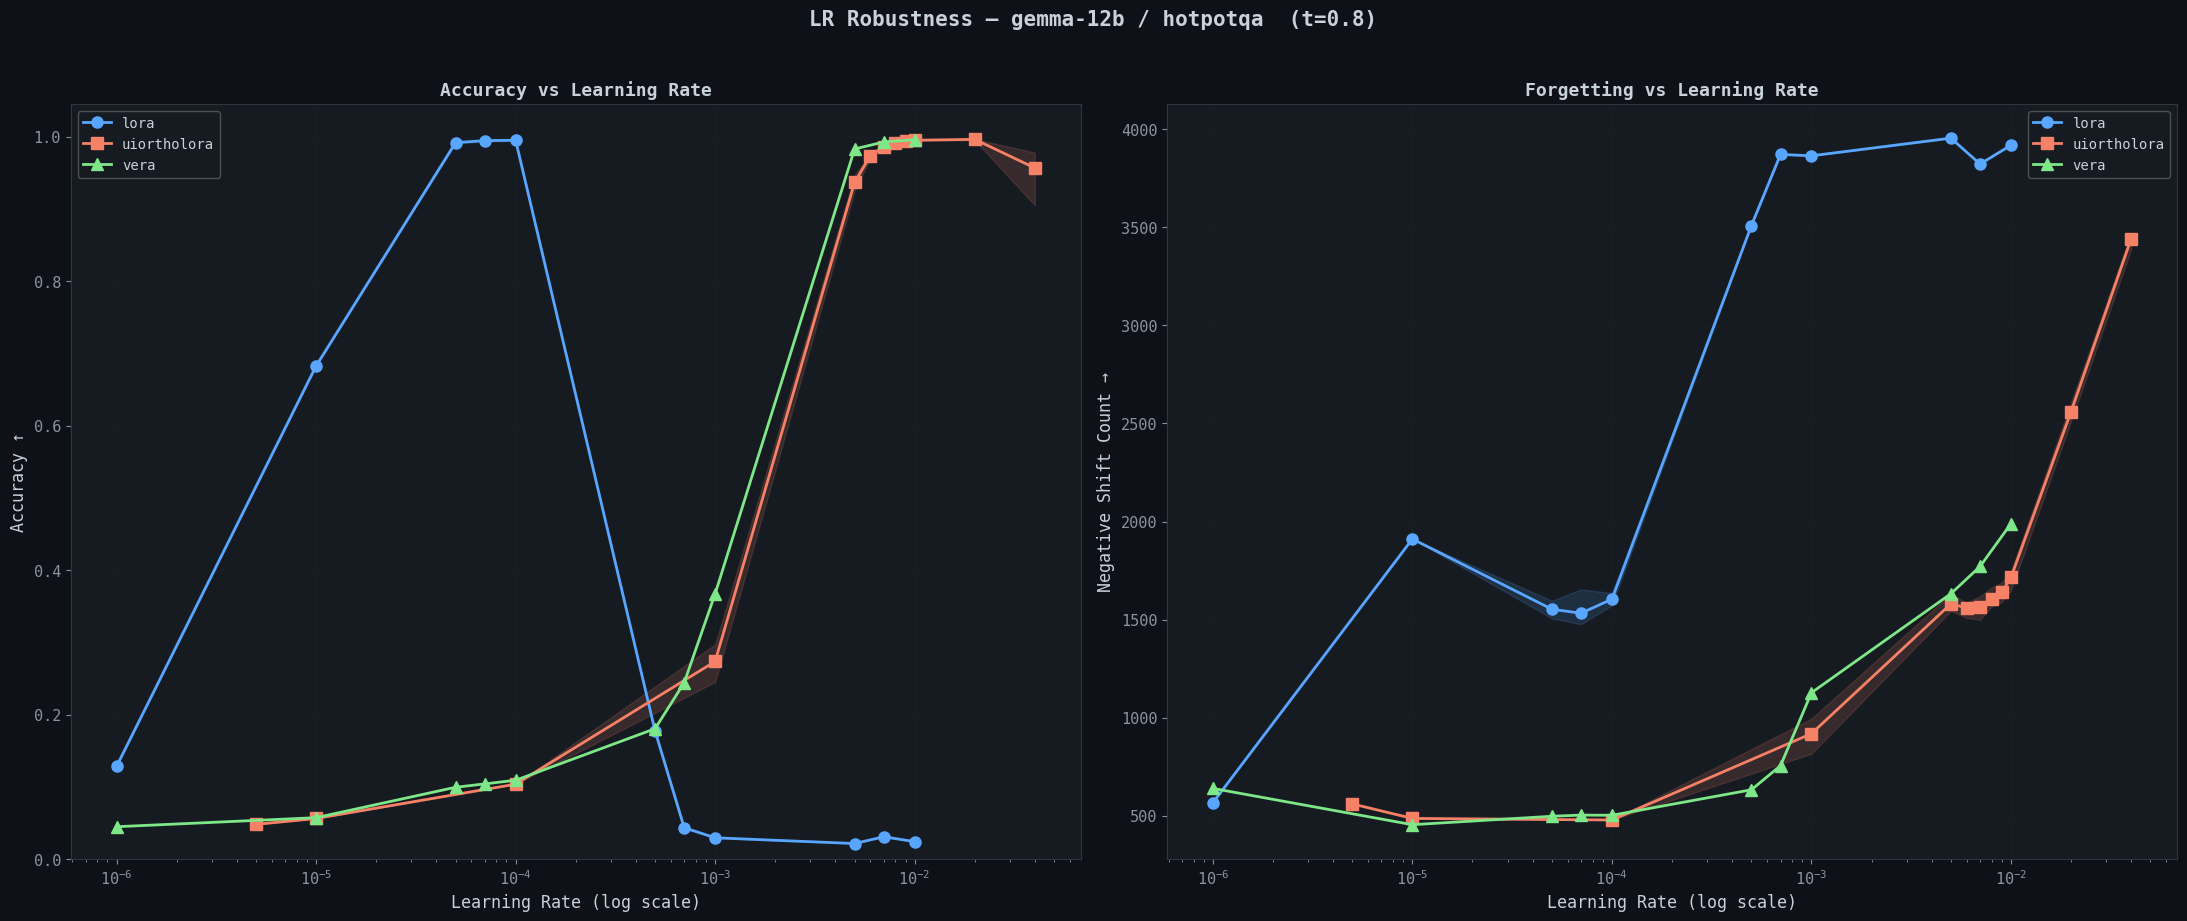

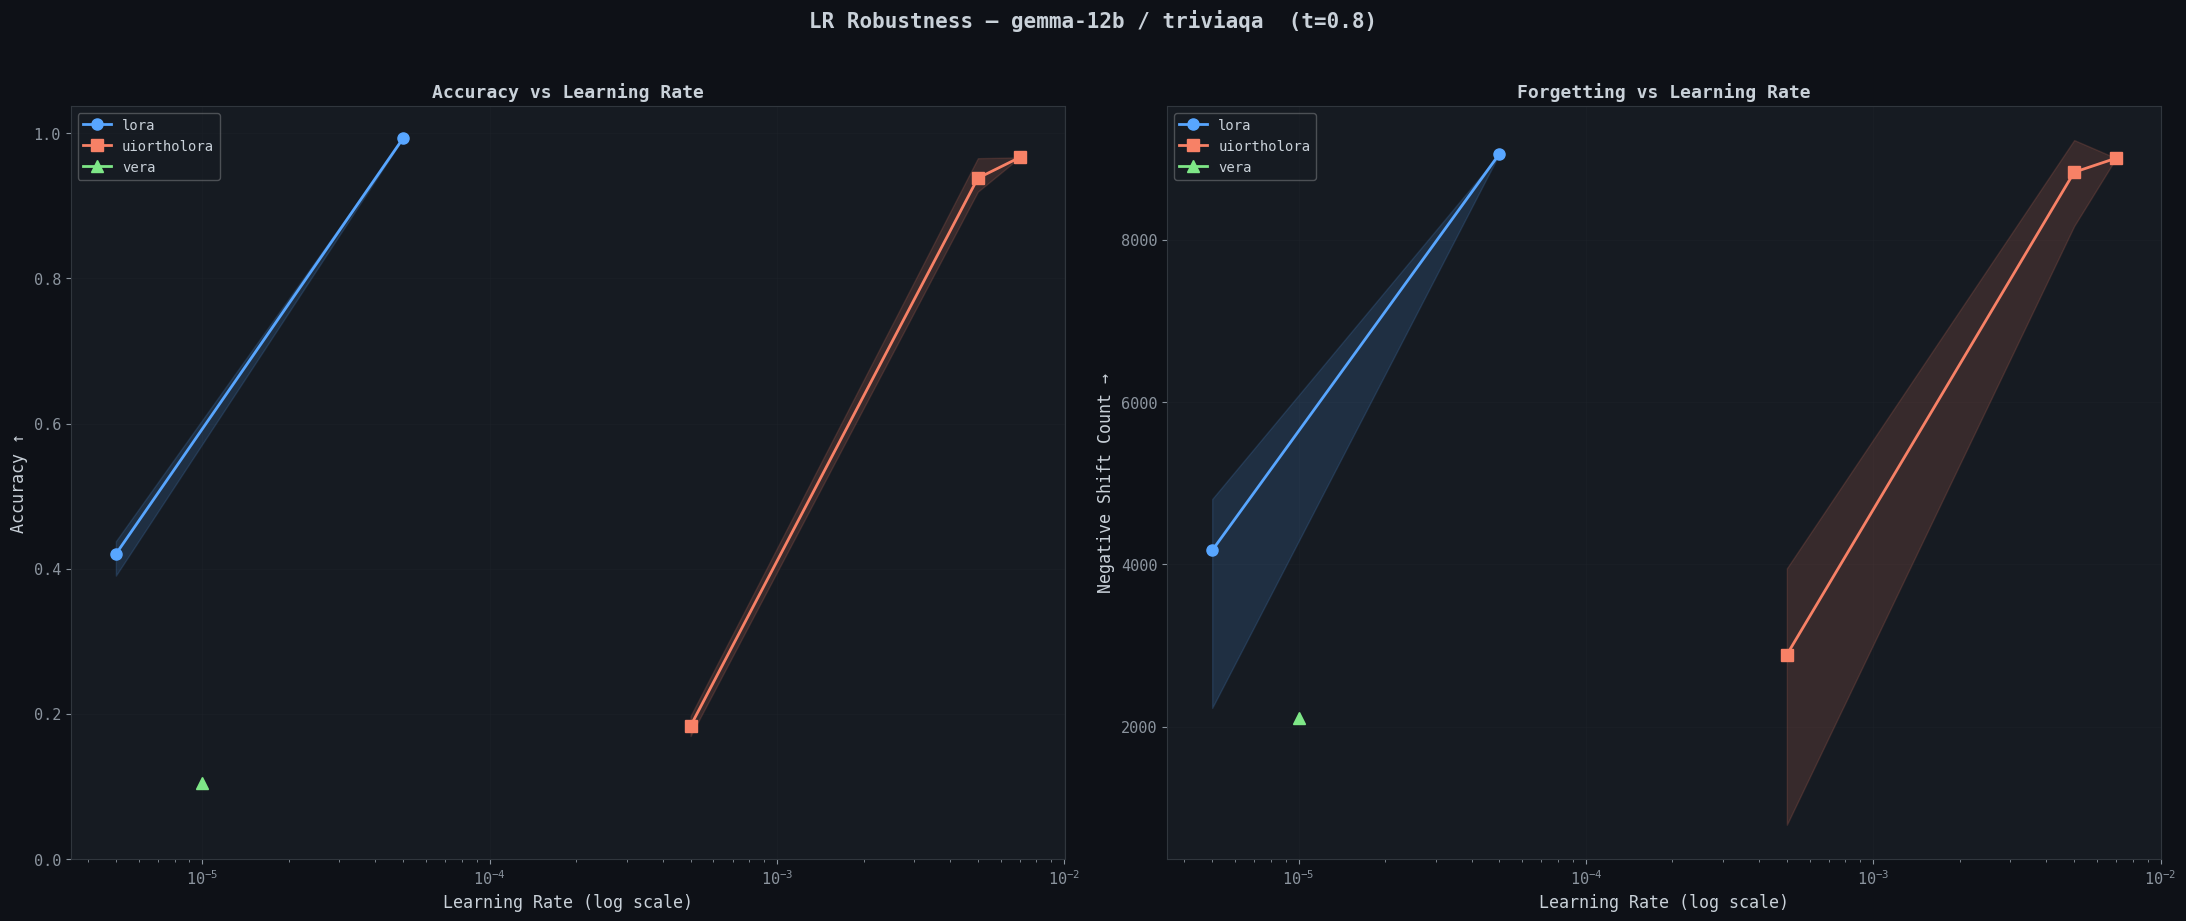

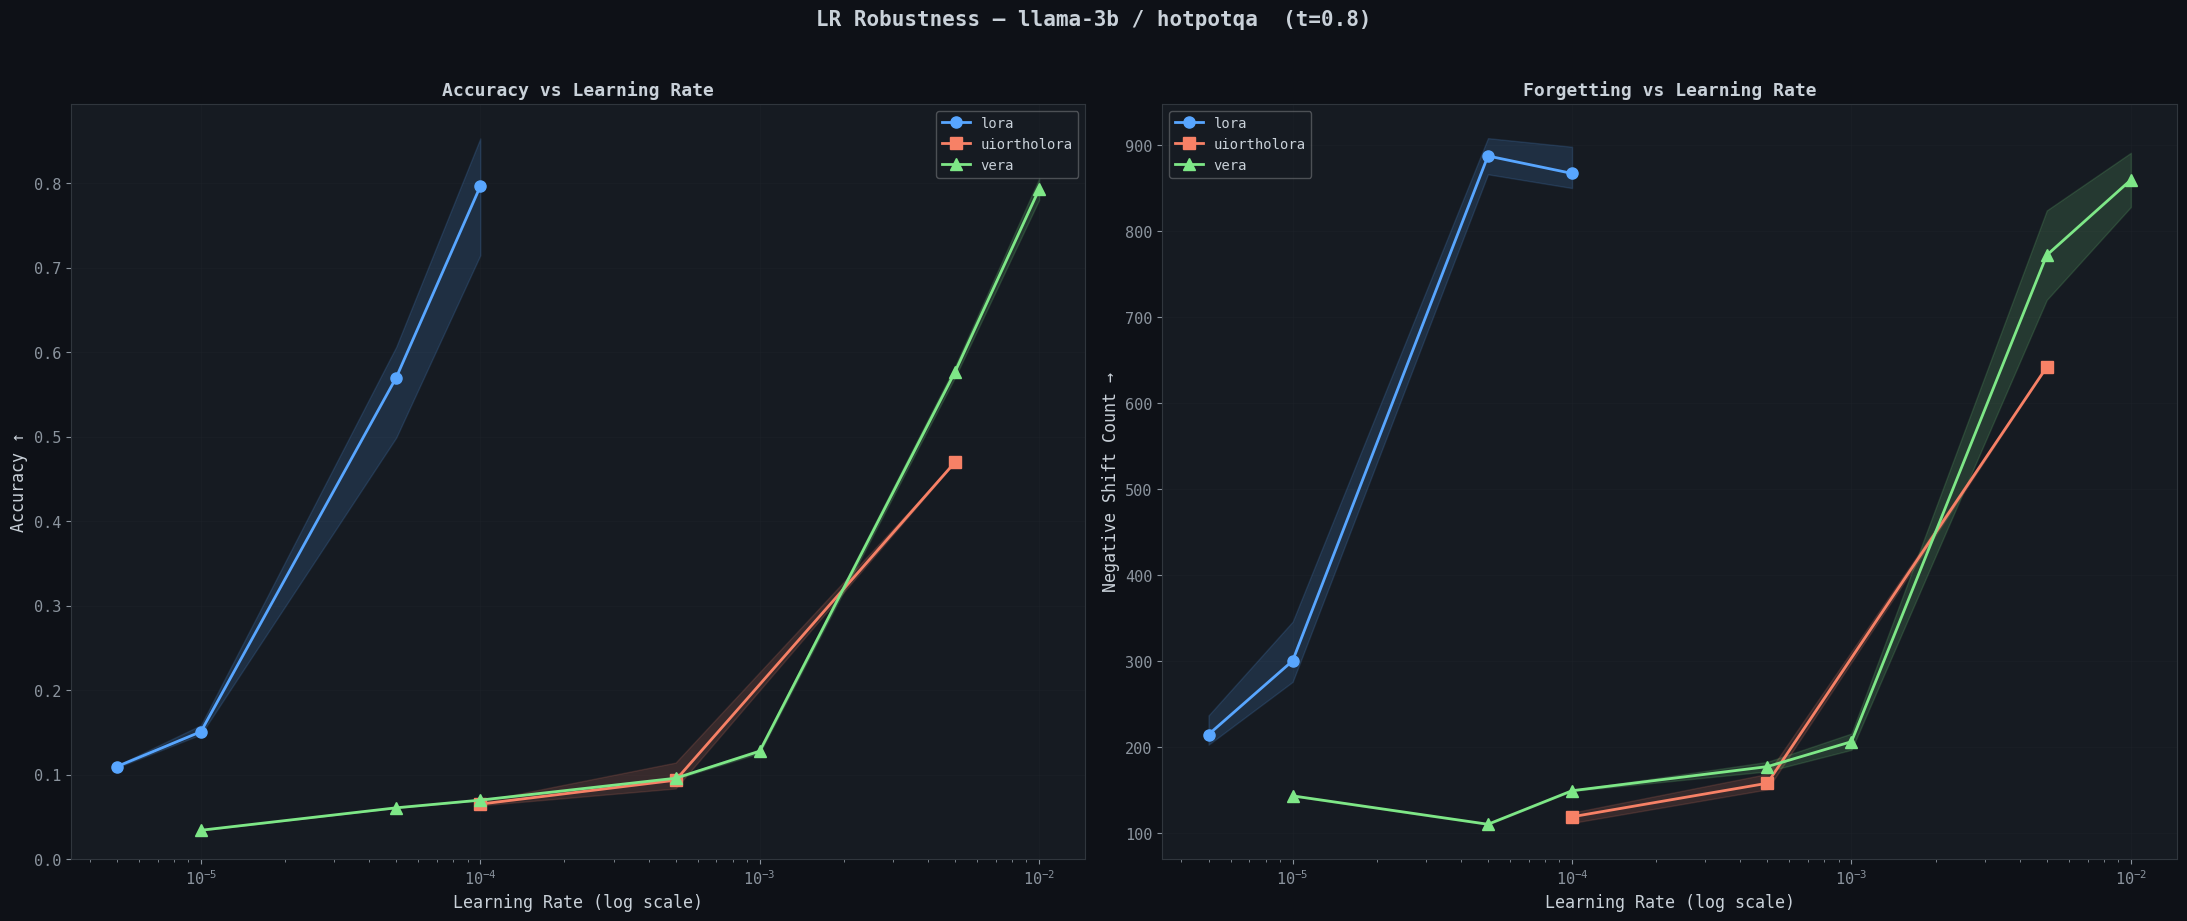

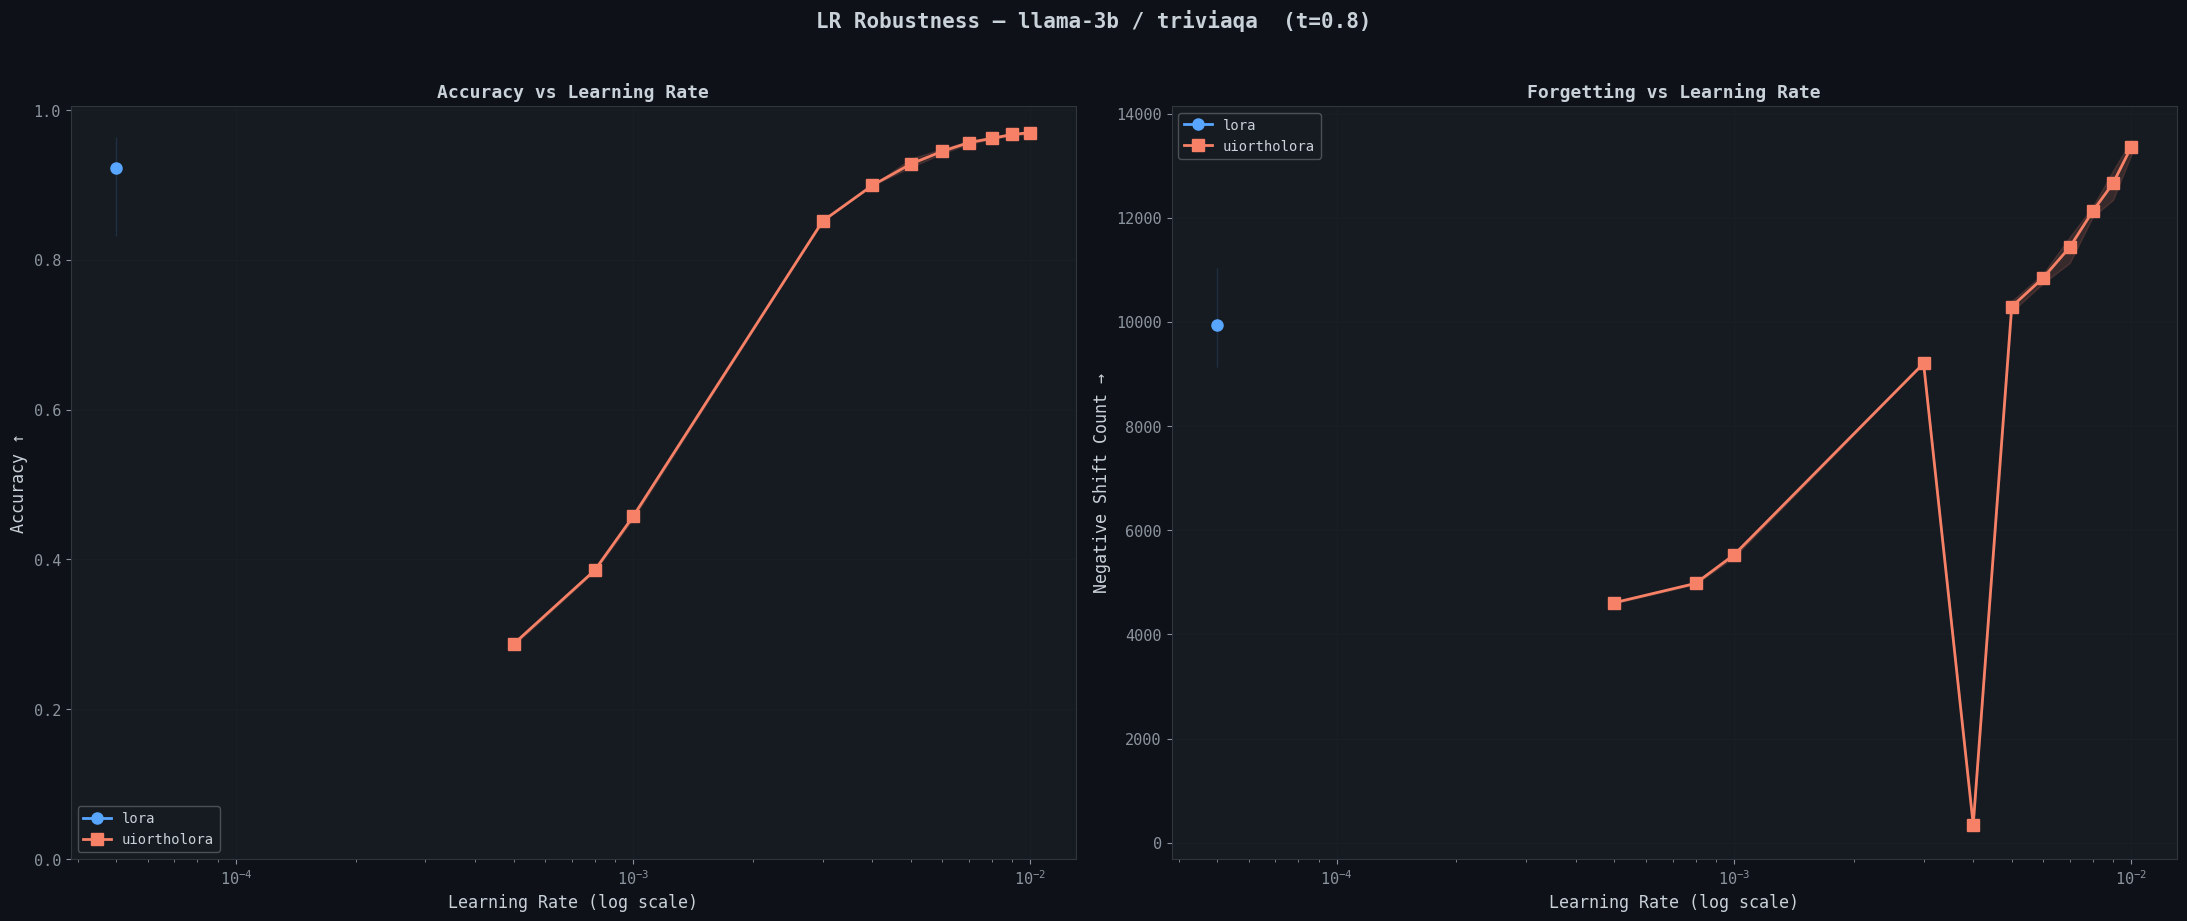

In [ ]:
# ── Cell 6: Learning Rate Robustness Analysis ────────────────────────────
def plot_lr_robustness(model, dataset, threshold):
    """
    For each adapter type, plot accuracy and neg_shift as a function of
    learning rate. This shows how sensitive each method is to LR choice.

    Two subplots:
      Left:  LR (x, log) vs Accuracy (y)
      Right: LR (x, log) vs Negative Shift Count (y)

    Each adapter type is a separate series. Error-bar-like spread if
    multiple configs share the same LR (different ranks, etc).
    """
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        print(f"  No data for {model}/{dataset}")
        return

    df = df.copy()
    df["lr_float"] = df["lr"].apply(parse_lr_float)
    df = df.dropna(subset=["lr_float"])
    if df.empty:
        return

    adapter_types = sorted(df["adapter_type"].dropna().unique())
    if not adapter_types:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

    for atype in adapter_types:
        sub = df[df["adapter_type"] == atype].copy()
        color = ADAPTER_COLORS.get(atype, "#999")
        marker = ADAPTER_MARKERS.get(atype, "o")

        # Group by LR: compute mean and std of accuracy and neg_shift
        grouped = sub.groupby("lr_float").agg(
            acc_mean=("accuracy", "mean"),
            acc_std=("accuracy", "std"),
            acc_min=("accuracy", "min"),
            acc_max=("accuracy", "max"),
            neg_mean=("negative_shift_count", "mean"),
            neg_std=("negative_shift_count", "std"),
            neg_min=("negative_shift_count", "min"),
            neg_max=("negative_shift_count", "max"),
            count=("accuracy", "count"),
        ).reset_index().sort_values("lr_float")

        grouped["acc_std"] = grouped["acc_std"].fillna(0)
        grouped["neg_std"] = grouped["neg_std"].fillna(0)

        lrs = grouped["lr_float"].values

        # ── Accuracy vs LR ──
        ax1.plot(lrs, grouped["acc_mean"], color=color, marker=marker,
                 linewidth=2, markersize=8, label=atype, zorder=5)
        # Show range as shaded band
        if (grouped["count"] > 1).any():
            ax1.fill_between(lrs, grouped["acc_min"], grouped["acc_max"],
                             color=color, alpha=0.15, zorder=2)

        # ── Neg shift vs LR ──
        ax2.plot(lrs, grouped["neg_mean"], color=color, marker=marker,
                 linewidth=2, markersize=8, label=atype, zorder=5)
        if (grouped["count"] > 1).any():
            ax2.fill_between(lrs, grouped["neg_min"], grouped["neg_max"],
                             color=color, alpha=0.15, zorder=2)

    ax1.set_xscale("log")
    ax1.set_xlabel("Learning Rate (log scale)", fontsize=12)
    ax1.set_ylabel("Accuracy ↑", fontsize=12)
    ax1.set_title("Accuracy vs Learning Rate", fontsize=13, fontweight="bold")
    ax1.legend(loc="best", framealpha=0.3, fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=0)

    ax2.set_xscale("log")
    ax2.set_xlabel("Learning Rate (log scale)", fontsize=12)
    ax2.set_ylabel("Negative Shift Count →", fontsize=12)
    ax2.set_title("Forgetting vs Learning Rate", fontsize=13, fontweight="bold")
    ax2.legend(loc="best", framealpha=0.3, fontsize=10)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"LR Robustness — {model} / {dataset}  (t={threshold})",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    plot_lr_robustness(model, dataset, THRESHOLD)

In [ ]:
# ── Cell 7: LR Robustness — Coefficient of Variation Table ────────────────
def lr_robustness_table(model, dataset, threshold):
    """
    For each adapter type, compute how much accuracy and forgetting vary
    across learning rates. Lower CV = more robust to LR choice.

    Metrics:
      - CV(accuracy):  std/mean across LRs  (lower = more robust)
      - Range(accuracy): max-min across LRs
      - CV(neg_shift): std/mean across LRs
      - Best acc: peak accuracy achievable
      - LR at best acc
    """
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        return None

    df = df.copy()
    df["lr_float"] = df["lr"].apply(parse_lr_float)
    df = df.dropna(subset=["lr_float"])

    rows = []
    for atype in sorted(df["adapter_type"].dropna().unique()):
        sub = df[df["adapter_type"] == atype]
        if len(sub) < 2:
            continue

        acc_mean = sub["accuracy"].mean()
        acc_std = sub["accuracy"].std()
        acc_cv = acc_std / acc_mean if acc_mean > 0 else np.nan
        acc_range = sub["accuracy"].max() - sub["accuracy"].min()

        neg_mean = sub["negative_shift_count"].mean()
        neg_std = sub["negative_shift_count"].std()
        neg_cv = neg_std / neg_mean if neg_mean > 0 else np.nan

        best_idx = sub["accuracy"].idxmax()
        best_row = sub.loc[best_idx]

        rows.append({
            "adapter": atype,
            "n_configs": len(sub),
            "n_lrs": sub["lr_float"].nunique(),
            "acc_mean": round(acc_mean, 4),
            "acc_std": round(acc_std, 4),
            "acc_CV": round(acc_cv, 4),
            "acc_range": round(acc_range, 4),
            "neg_mean": int(neg_mean),
            "neg_CV": round(neg_cv, 4),
            "best_acc": round(best_row["accuracy"], 4),
            "best_lr": best_row["lr"],
        })

    if not rows:
        return None

    result = pd.DataFrame(rows)
    return result


THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    print(f"\n{'━'*90}")
    print(f"  LR Robustness — {model} / {dataset}  (t={THRESHOLD})")
    print(f"  Lower acc_CV = more robust to learning rate choice")
    print(f"{'━'*90}")
    tbl = lr_robustness_table(model, dataset, THRESHOLD)
    if tbl is not None:
        print(tbl.to_string(index=False))
    else:
        print("  Not enough data points")
    print()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LR Robustness — gemma-12b / hotpotqa  (t=0.8)
  Lower acc_CV = more robust to learning rate choice
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    adapter  n_configs  n_lrs  acc_mean  acc_std  acc_CV  acc_range  neg_mean  neg_CV  best_acc  best_lr
       lora         18     11    0.6151   0.4588  0.7459     0.9746      2276  0.5088    0.9961   0.0001
uiortholora         97     12    0.9344   0.1995  0.2135     0.9487      1785  0.3257    0.9967   0.0200
       vera         11     11    0.3798   0.4027  1.0603     0.9511       954  0.6052    0.9958   0.0100


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LR Robustness — gemma-12b / triviaqa  (t=0.8)
  Lower acc_CV = more robust to learning rate choice
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    adapter

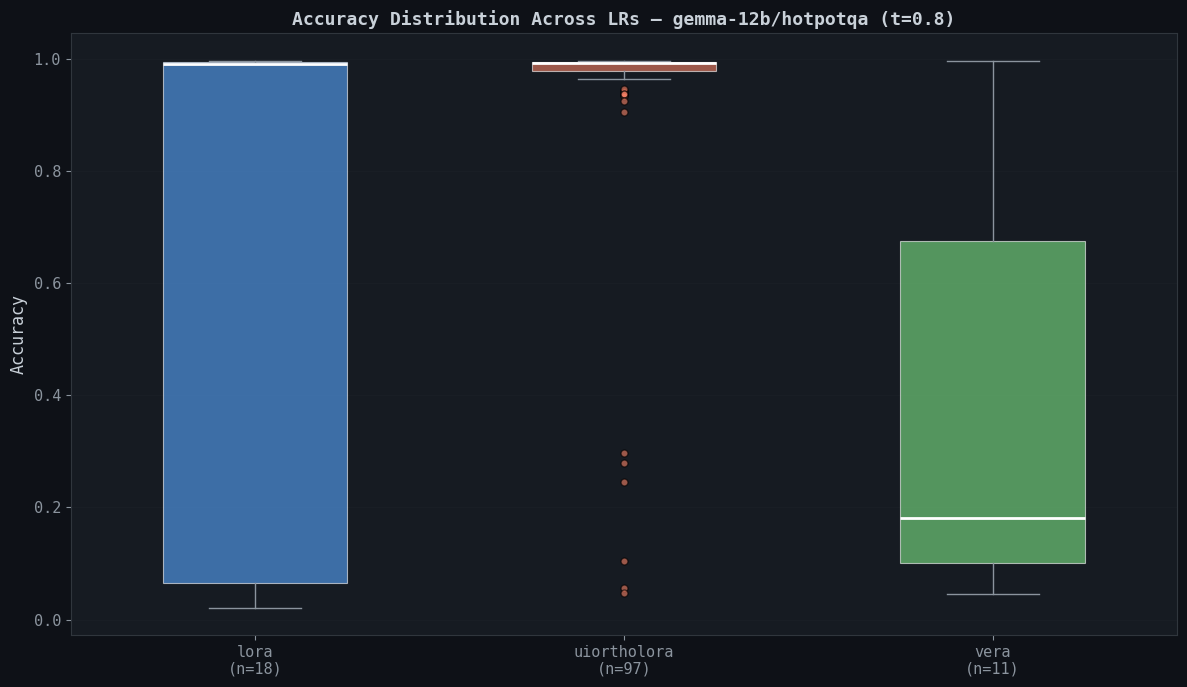

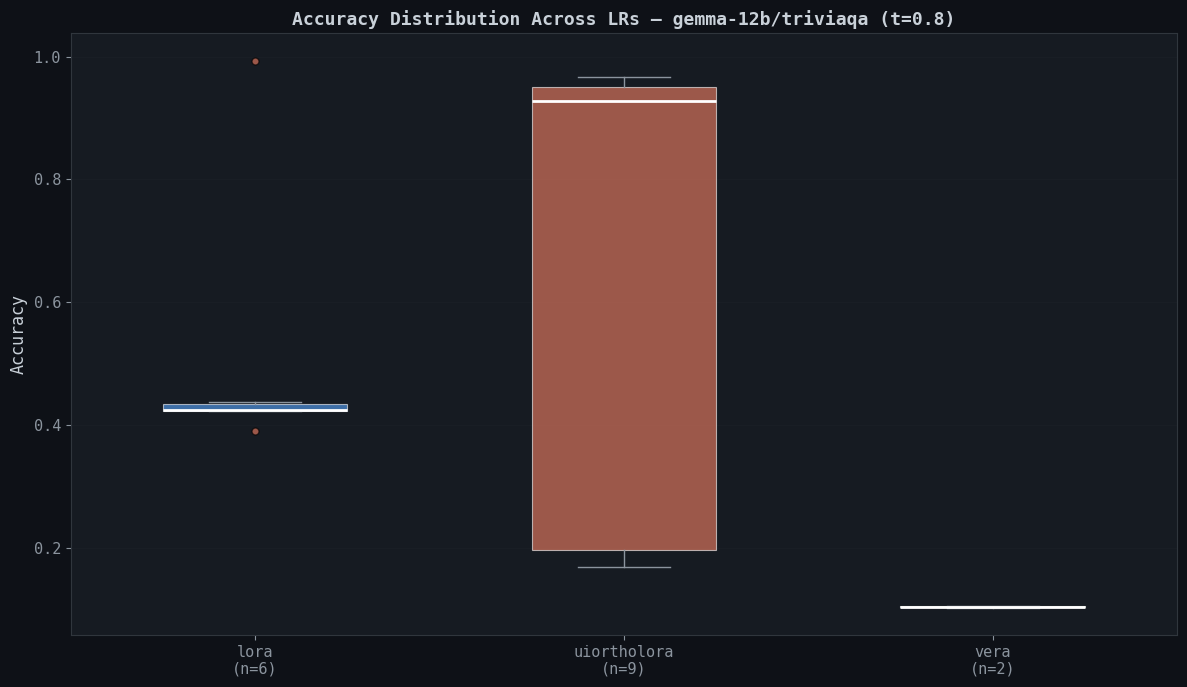

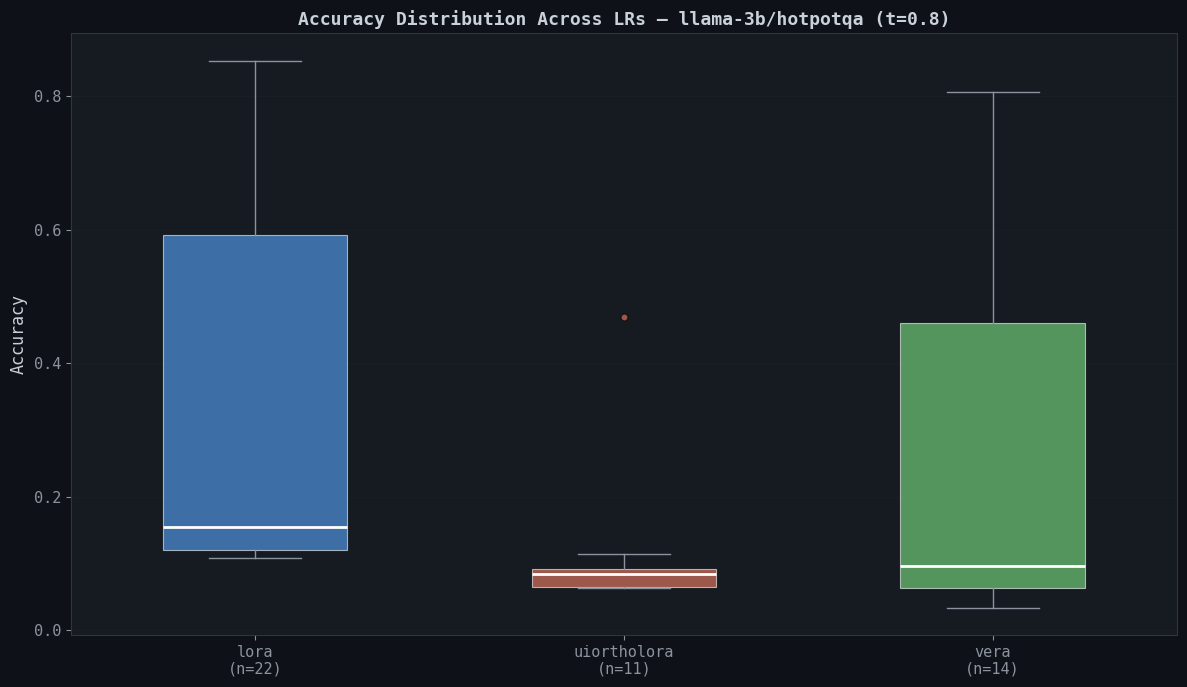

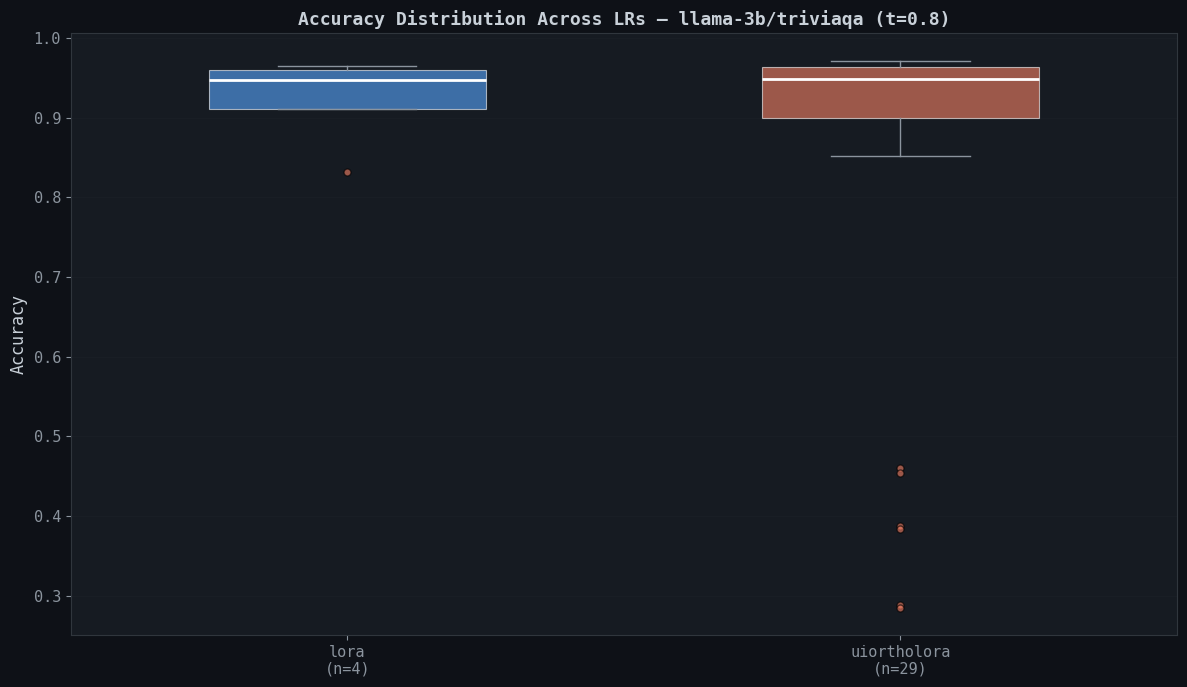

In [ ]:
# ── Cell 8: LR Robustness — Accuracy Spread Box Plot ─────────────────────
def plot_lr_boxplot(model, dataset, threshold):
    """
    Box plot showing the distribution of accuracy across all LR settings
    for each adapter type. A tight box = robust to LR.
    """
    df = load_intrinsic(model, dataset, threshold)
    if df.empty:
        return

    adapter_types = sorted(df["adapter_type"].dropna().unique())
    if len(adapter_types) < 1:
        return

    fig, ax = plt.subplots(figsize=(12, 7))

    data_for_box = []
    labels = []
    colors = []
    for atype in adapter_types:
        sub = df[df["adapter_type"] == atype]
        if len(sub) < 2:
            continue
        data_for_box.append(sub["accuracy"].values)
        labels.append(f"{atype}\n(n={len(sub)})")
        colors.append(ADAPTER_COLORS.get(atype, "#999"))

    if not data_for_box:
        return

    bp = ax.boxplot(data_for_box, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="#8b949e"),
                    capprops=dict(color="#8b949e"),
                    flierprops=dict(marker="o", markerfacecolor="#f78166", markersize=5, alpha=0.6))

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        patch.set_edgecolor("white")
        patch.set_linewidth(0.8)

    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title(f"Accuracy Distribution Across LRs — {model}/{dataset} (t={threshold})",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()


THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    plot_lr_boxplot(model, dataset, THRESHOLD)

In [ ]:
# ── Cell 9: Summary Tables with MMLU & BigBench ──────────────────────────
THRESHOLD = 0.8

for model, dataset in product(MODELS, DATASETS):
    print(f"\n{'━'*90}")
    print(f"  {model} / {dataset}  (threshold={THRESHOLD})")
    print(f"{'━'*90}")
    print_summary(model, dataset, THRESHOLD)
    print()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  gemma-12b / hotpotqa  (threshold=0.8)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                                            adapter        type       lr   rank    acc  neg_shift   mmlu  bigbench
                    google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-6        lora 0.000001    3.0 0.1283        566 0.7112    0.6157
                    google_gemma-3-12b-it_lora_trAll_lora_r8_lr7e-5        lora 0.000070    8.0 0.9956       1476 0.7044    0.6237
                    google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-5        lora 0.000070    3.0 0.9944       1495 0.6990    0.6154
                   google_gemma-3-12b-it_lora_trAll_lora_r16_lr7e-5        lora 0.000070   16.0 0.9948       1505 0.7047    0.6331
                   google_gemma-3-12b-it_lora_trAll_lora_r16_lr5e-5        lora 0.000050   16.0 0.9926       1507 0.7077  

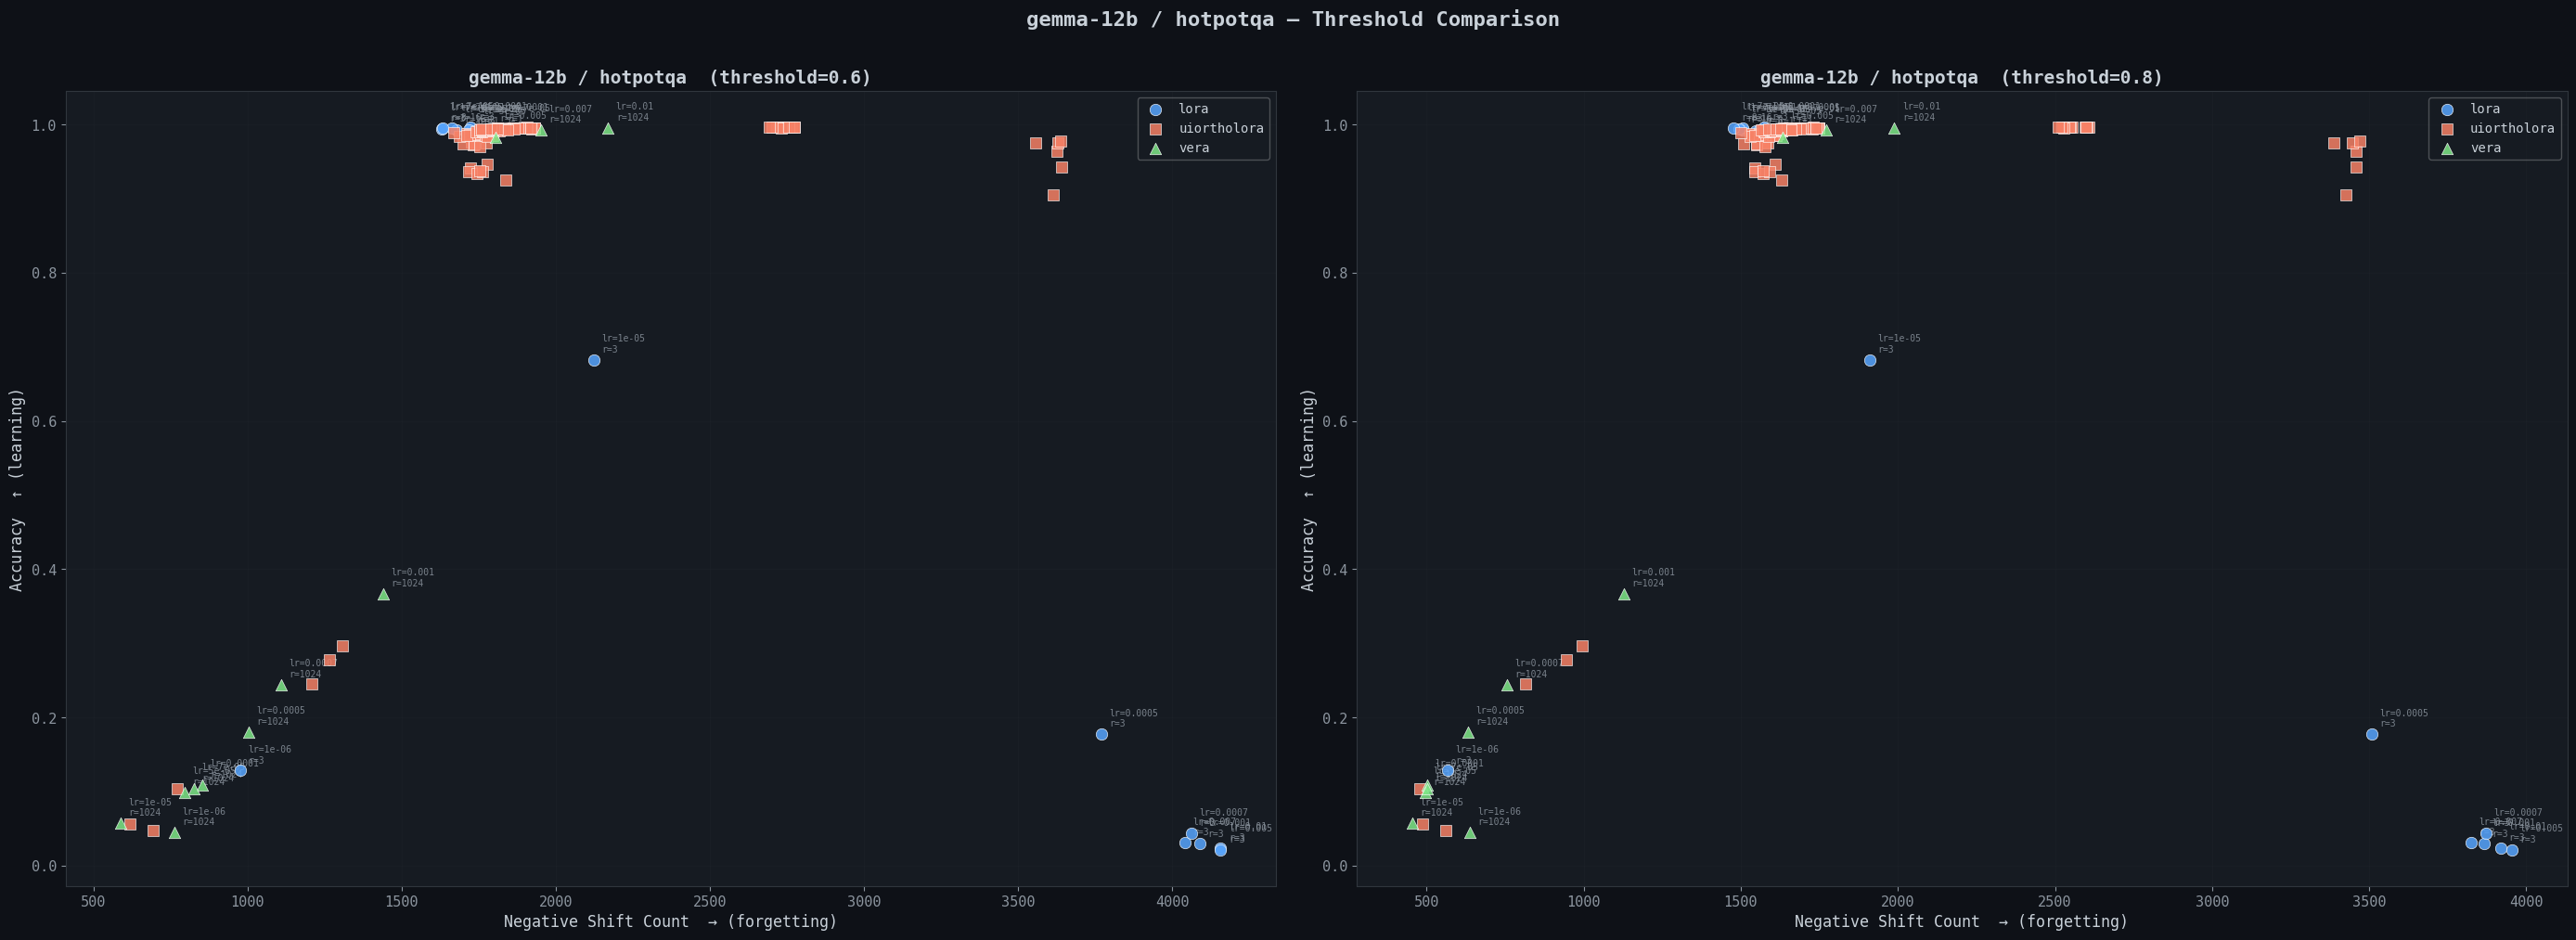

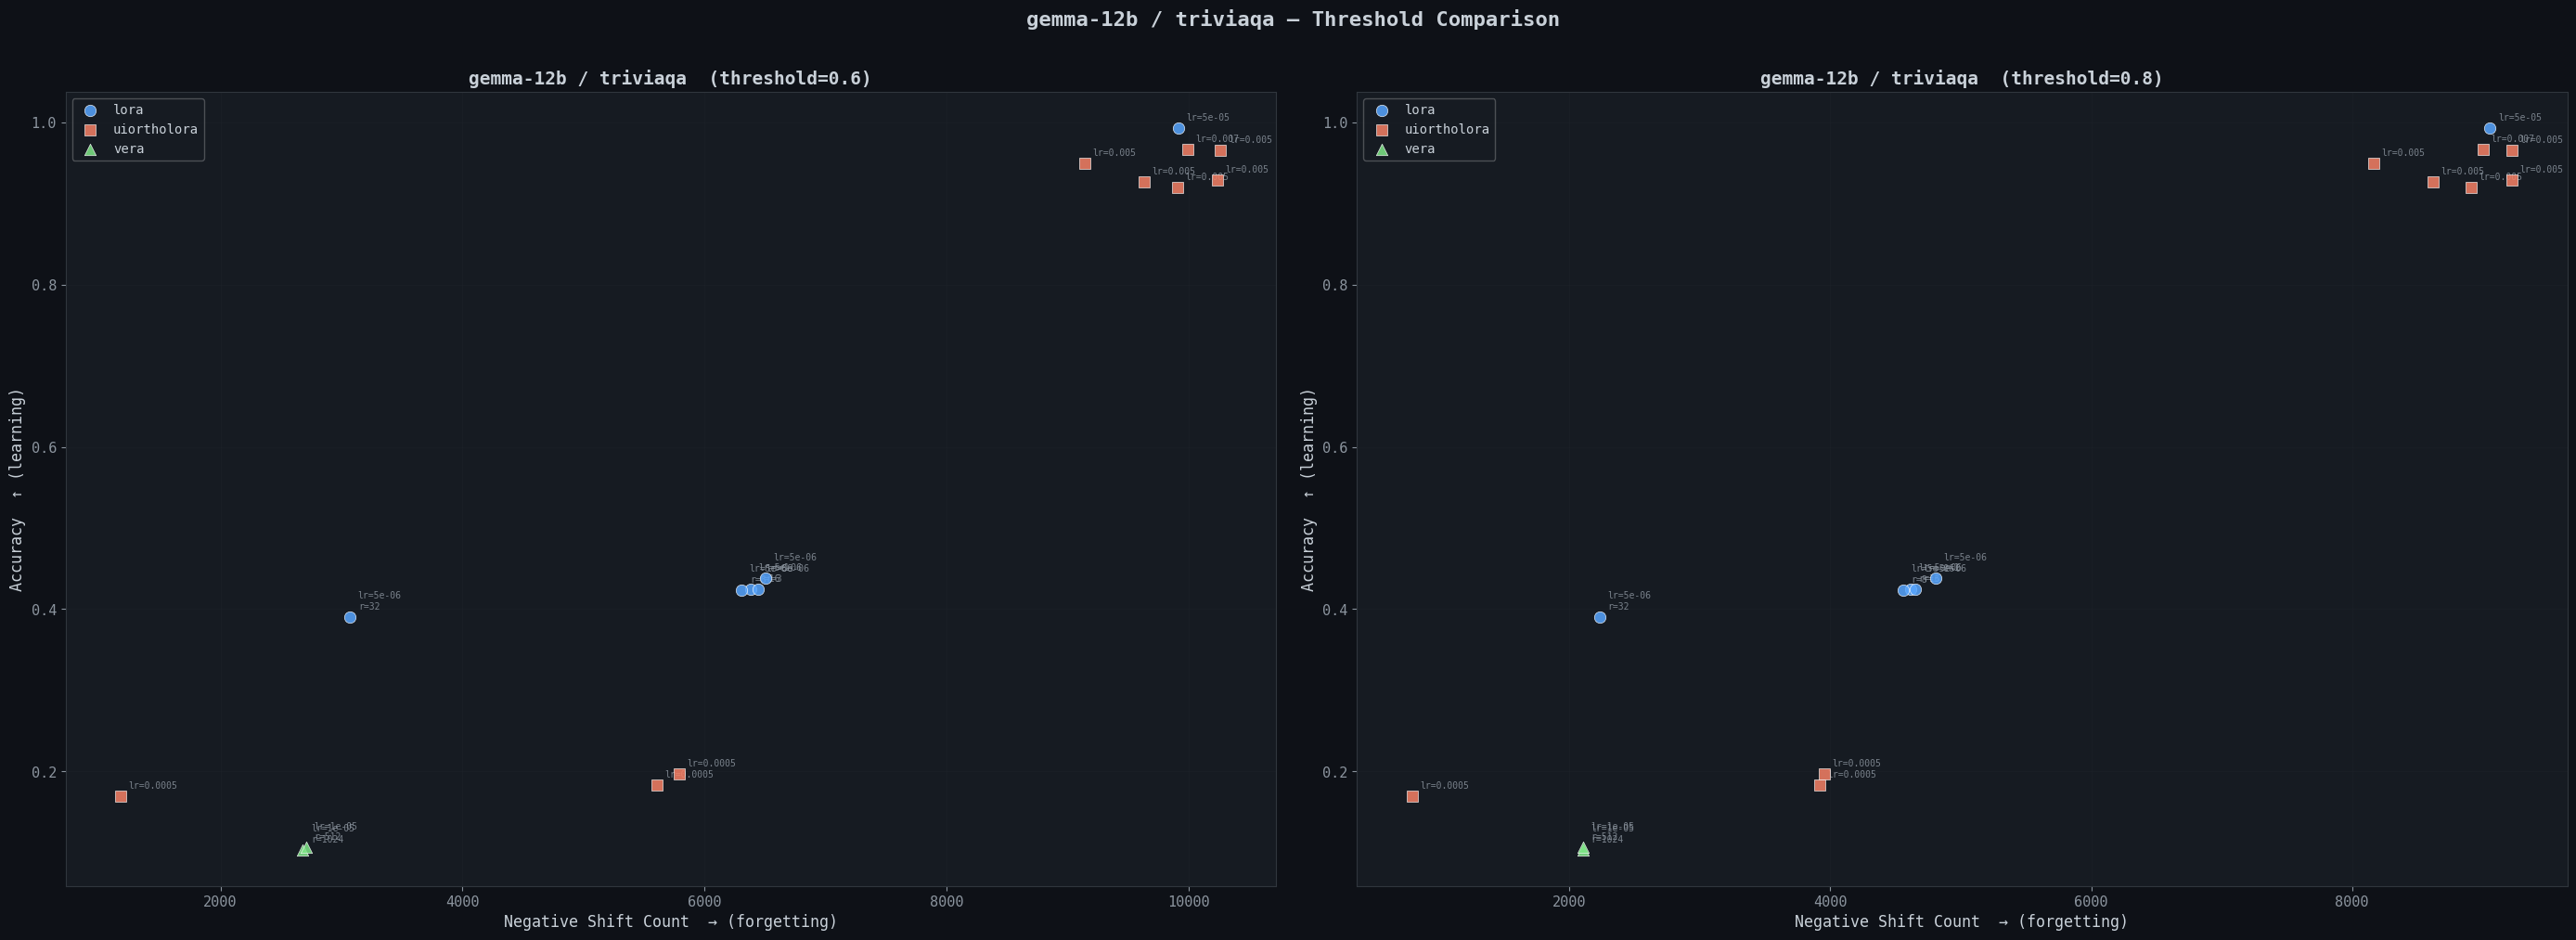

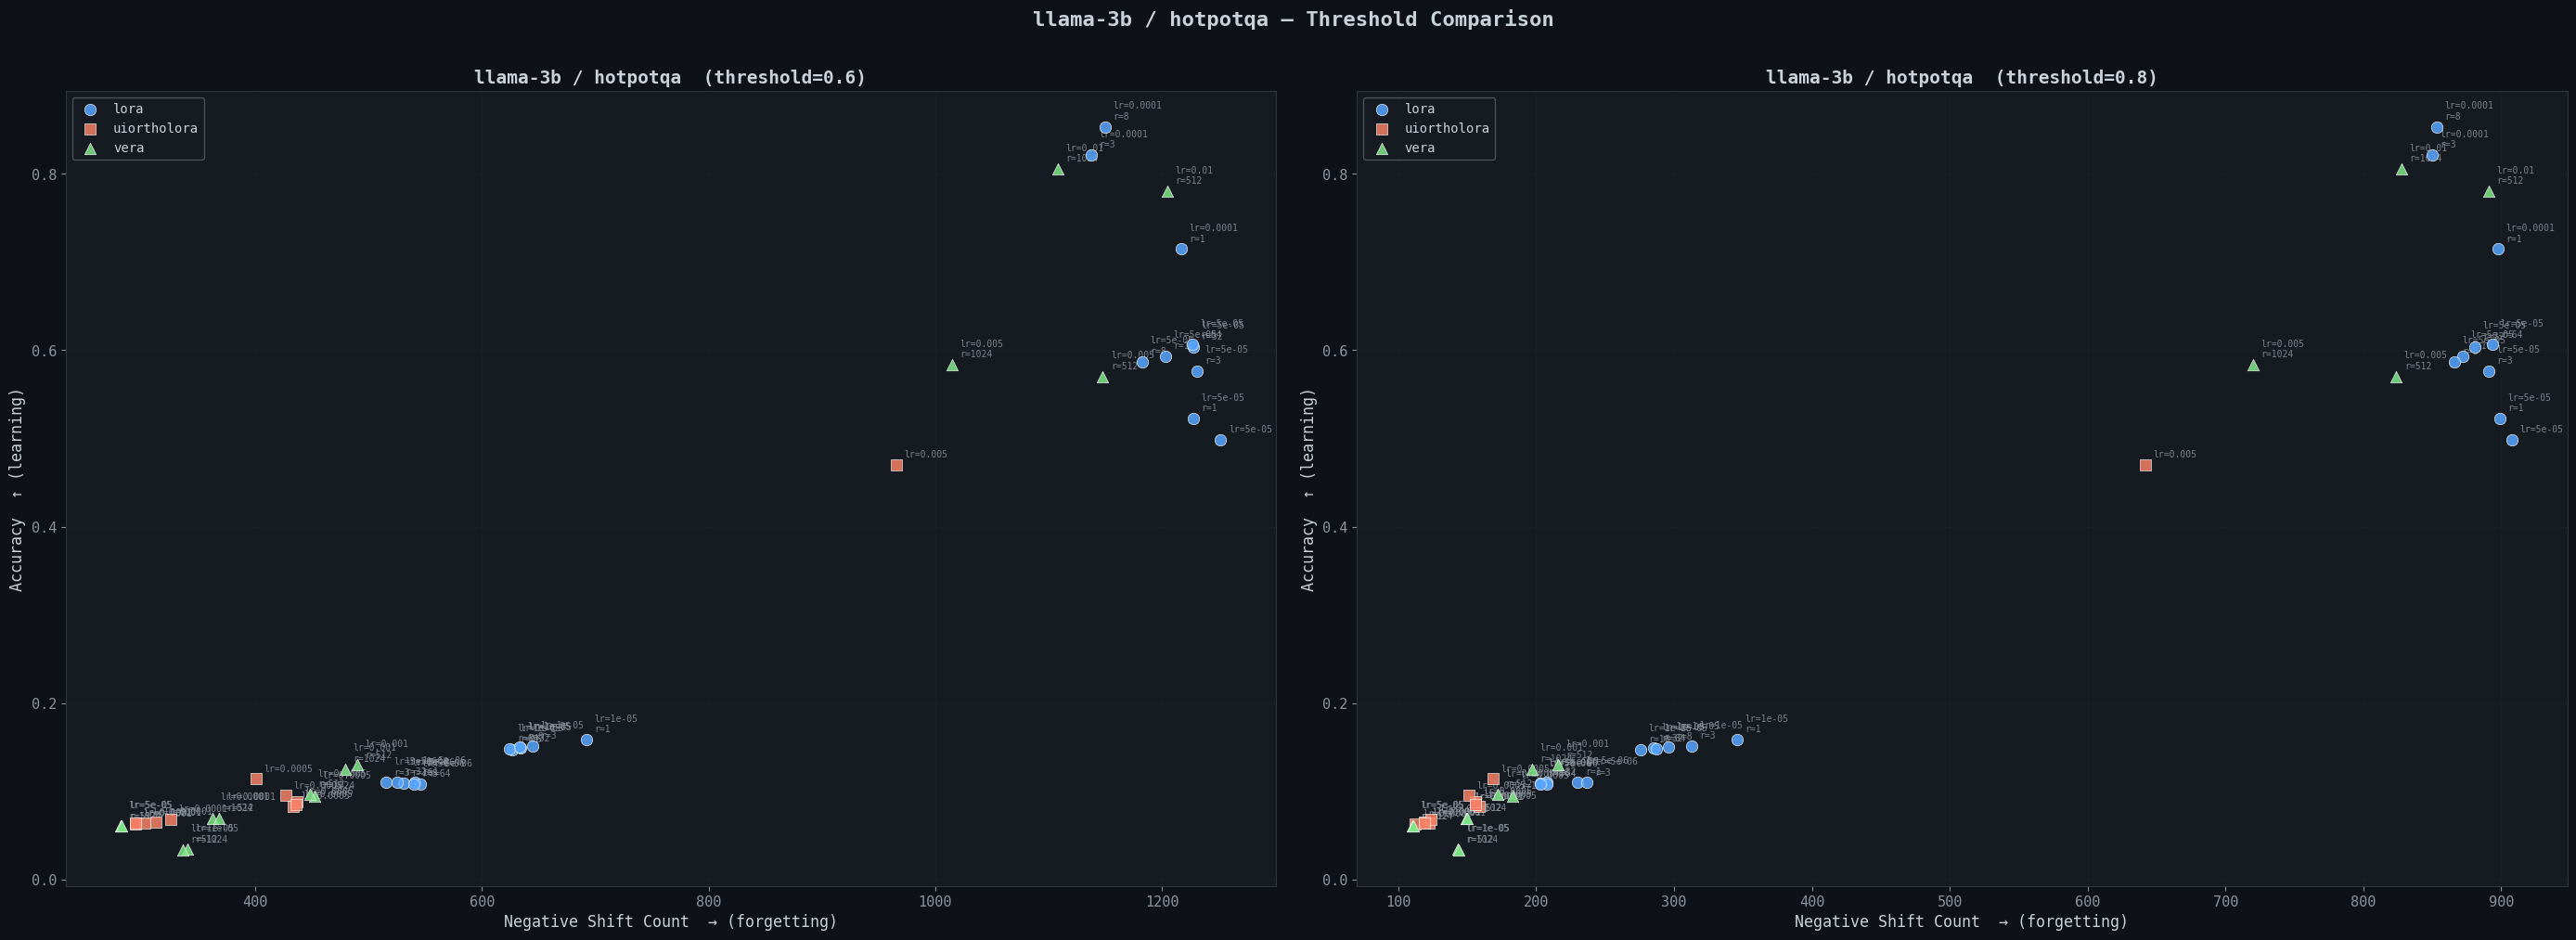

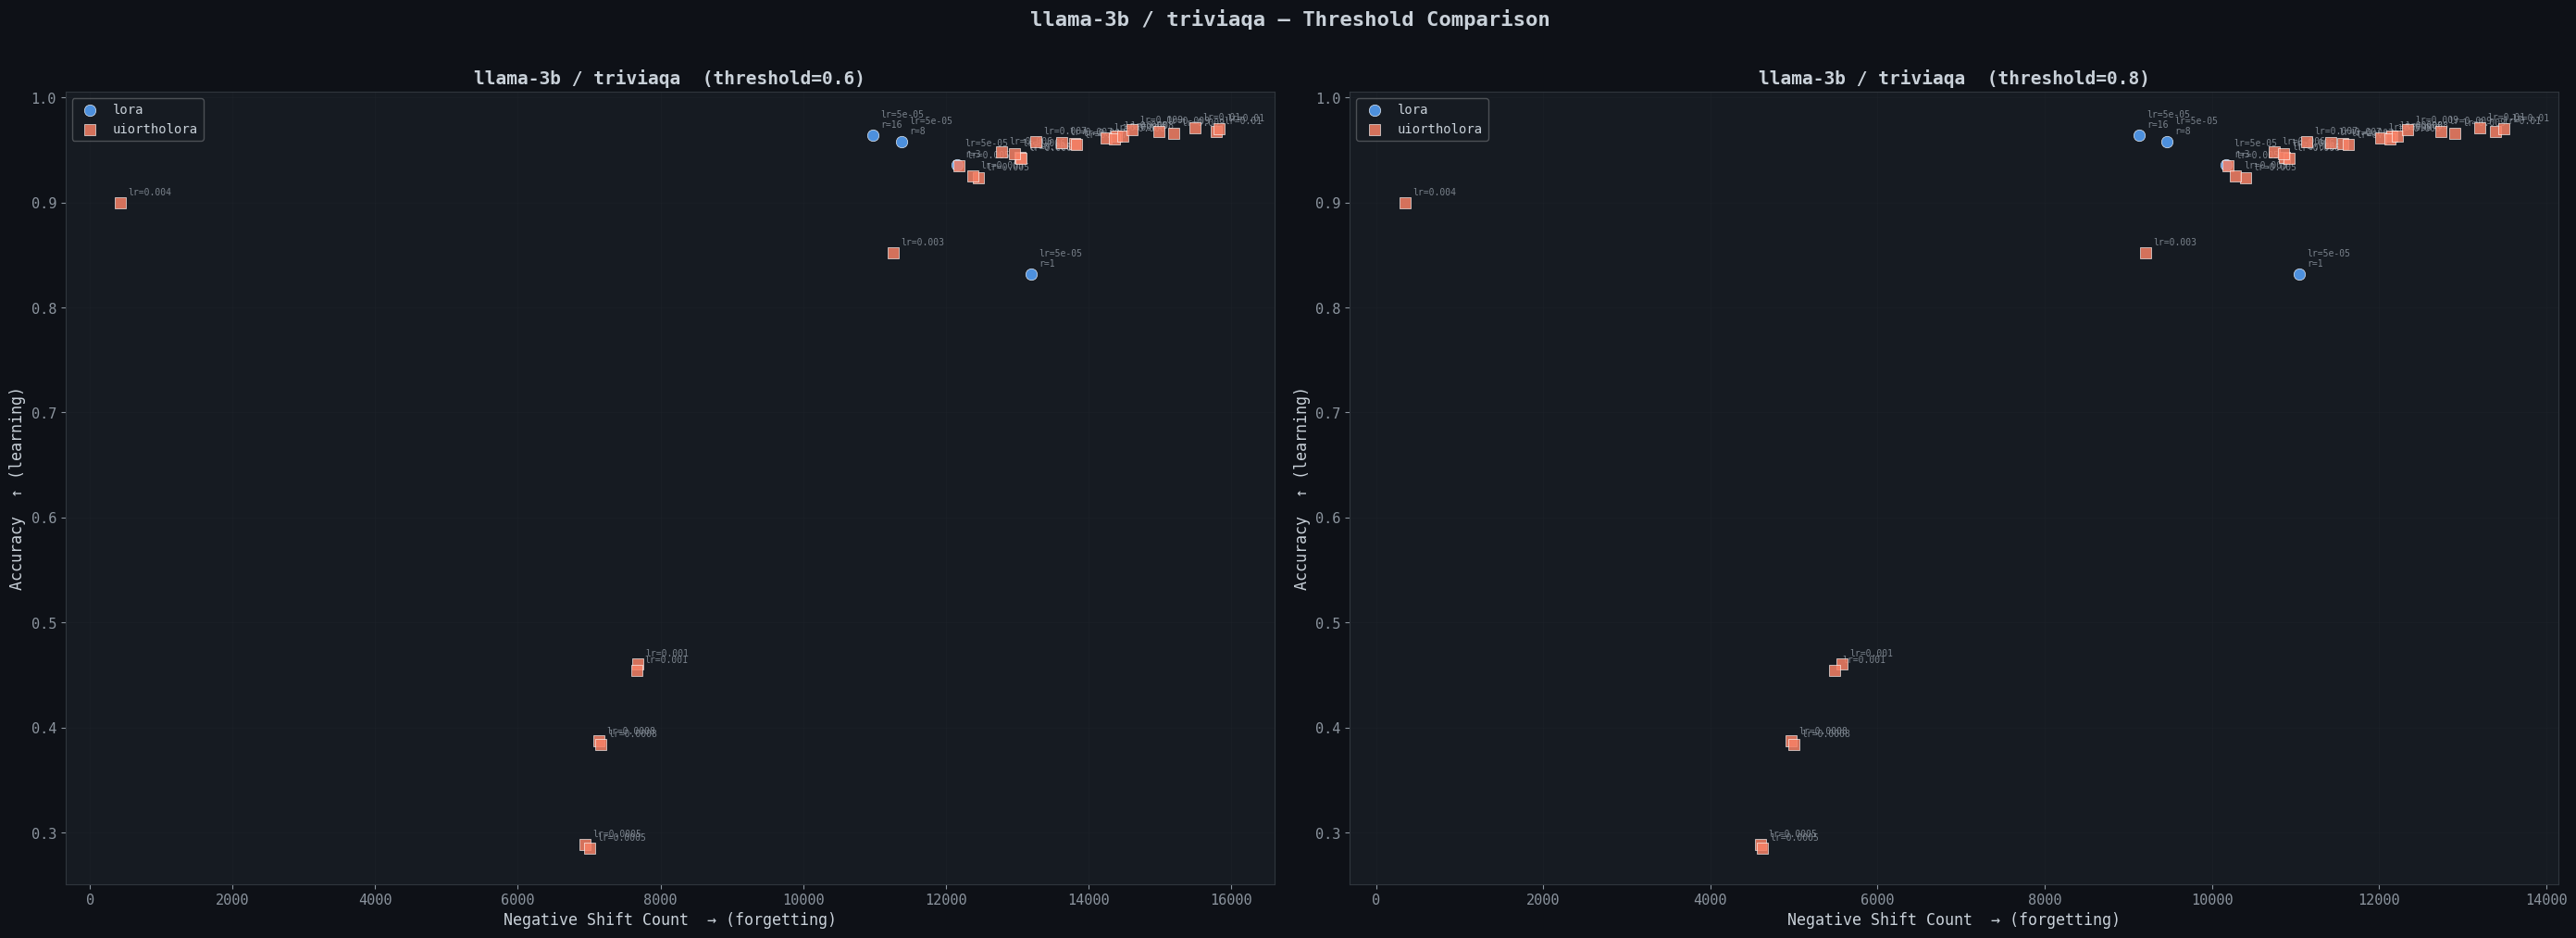

In [ ]:
# ── Cell 10: Threshold Comparison (0.6 vs 0.8) ───────────────────────────
for model, dataset in product(MODELS, DATASETS):
    fig, axes = plt.subplots(1, 2, figsize=(28, 10))
    for idx, t in enumerate(THRESHOLDS):
        plot_scatter(model, dataset, t, axes[idx])
    fig.suptitle(f"{model} / {dataset} — Threshold Comparison",
                 fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()